In [1]:
# ============================================================
# BitcoinGuard AI — Elliptic Dataset EDA 
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# FIX: Use modern seaborn style (deprecated "seaborn-v0_8-darkgrid")
sns.set_style("darkgrid")
sns.set_palette("husl")

BASE = "/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/"

# Node features
features = pd.read_csv(BASE + "elliptic_txs_features.csv", header=None)
features.columns = ["txId", "time_step"] + [f"feat_{i}" for i in range(1, 166)]

# Labels
classes = pd.read_csv(BASE + "elliptic_txs_classes.csv")
classes.columns = ["txId", "label"]

# Edge list
edges = pd.read_csv(BASE + "elliptic_txs_edgelist.csv", header=None)
edges.columns = ["source", "target"]

print("✅ Dataset loaded successfully!")
print(f"   Features  : {features.shape}")
print(f"   Classes   : {classes.shape}")
print(f"   Edges     : {edges.shape}")

✅ Dataset loaded successfully!
   Features  : (203769, 167)
   Classes   : (203769, 2)
   Edges     : (234356, 2)


In [2]:
# ─────────────────────────────────────────────────────────────
# CELL 2 — Merge + Preview
# ─────────────────────────────────────────────────────────────
df = features.merge(classes, on="txId")

print(f"Merged shape: {df.shape}")
print("\nSample rows (txId, time_step, label, first 3 features):")
df[["txId", "time_step", "label", "feat_1", "feat_2", "feat_3"]].head(8)


Merged shape: (203769, 168)

Sample rows (txId, time_step, label, first 3 features):


,txId,time_step,label,feat_1,feat_2,feat_3
0,230425980,1,unknown,-0.171469,-0.184668,-1.201369
1,5530458,1,unknown,-0.171484,-0.184668,-1.201369
2,232022460,1,unknown,-0.172107,-0.184668,-1.201369
3,232438397,1,2,0.163054,1.963790,-0.646376
4,230460314,1,unknown,1.011523,-0.081127,-1.201369
5,230459870,1,unknown,0.961040,-0.081127,-1.201369
6,230333930,1,unknown,-0.171264,-0.184668,-1.201369
7,230595899,1,unknown,-0.171755,-0.184668,-1.201369


LABEL DISTRIBUTION
label
unknown    157205
2           42019
1            4545
Name: count, dtype: int64

What the labels mean:
  '1'       → Illicit  (dark markets, ransomware, Ponzi)
  '2'       → Licit    (exchanges, wallets, legit services)
  'unknown' → No label (vast majority — real world scenario)

Among 46,564 labeled transactions:
  Illicit : 4,545  (9.8%)
  Licit   : 42,019  (90.2%)

⚠️  Class imbalance: 1 illicit per ~9 licit transactions
   → You'll need SMOTE or class_weight='balanced' later


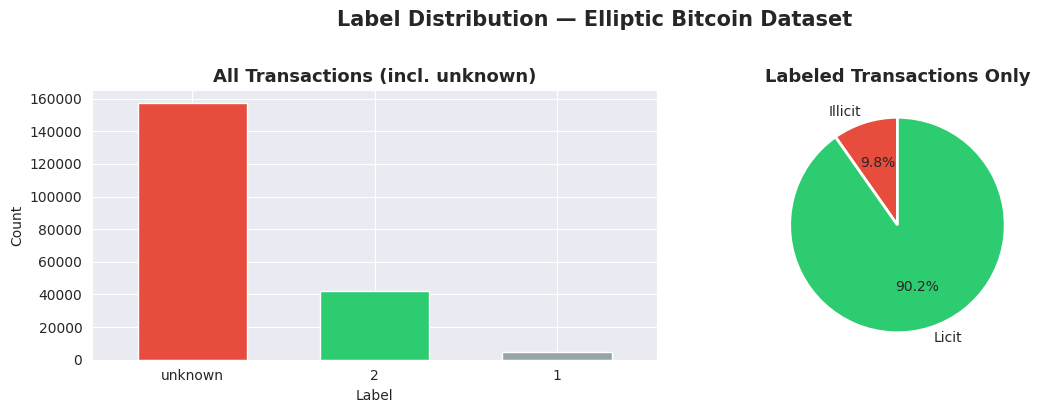

In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 3 — Label Distribution
# ─────────────────────────────────────────────────────────────
print("=" * 50)
print("LABEL DISTRIBUTION")
print("=" * 50)
print(df["label"].value_counts())
print()
print("What the labels mean:")
print("  '1'       → Illicit  (dark markets, ransomware, Ponzi)")
print("  '2'       → Licit    (exchanges, wallets, legit services)")
print("  'unknown' → No label (vast majority — real world scenario)")

labeled = df[df["label"] != "unknown"].copy()
labeled["label_num"] = labeled["label"].astype(int)

illicit_n = (labeled["label_num"] == 1).sum()
licit_n   = (labeled["label_num"] == 2).sum()
total_n   = len(labeled)

print(f"\nAmong {total_n:,} labeled transactions:")
print(f"  Illicit : {illicit_n:,}  ({illicit_n/total_n*100:.1f}%)")
print(f"  Licit   : {licit_n:,}  ({licit_n/total_n*100:.1f}%)")
print(f"\n⚠️  Class imbalance: 1 illicit per ~{licit_n//illicit_n} licit transactions")
print("   → You'll need SMOTE or class_weight='balanced' later")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Full dataset
df["label"].value_counts().plot(
    kind="bar", ax=axes[0], color=["#e74c3c", "#2ecc71", "#95a5a6"],
    edgecolor="white", width=0.6
)
axes[0].set_title("All Transactions (incl. unknown)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)

# Labeled only (pie)
axes[1].pie(
    [illicit_n, licit_n],
    labels=["Illicit", "Licit"],
    colors=["#e74c3c", "#2ecc71"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1].set_title("Labeled Transactions Only", fontsize=13, fontweight="bold")

plt.suptitle("Label Distribution — Elliptic Bitcoin Dataset", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()



TIME STEP ANALYSIS
49 time steps — each represents ~2 weeks of blockchain activity
Within each step: transactions appearing within 3 hours of each other
This gives your LSTM a natural sequential structure to learn from!



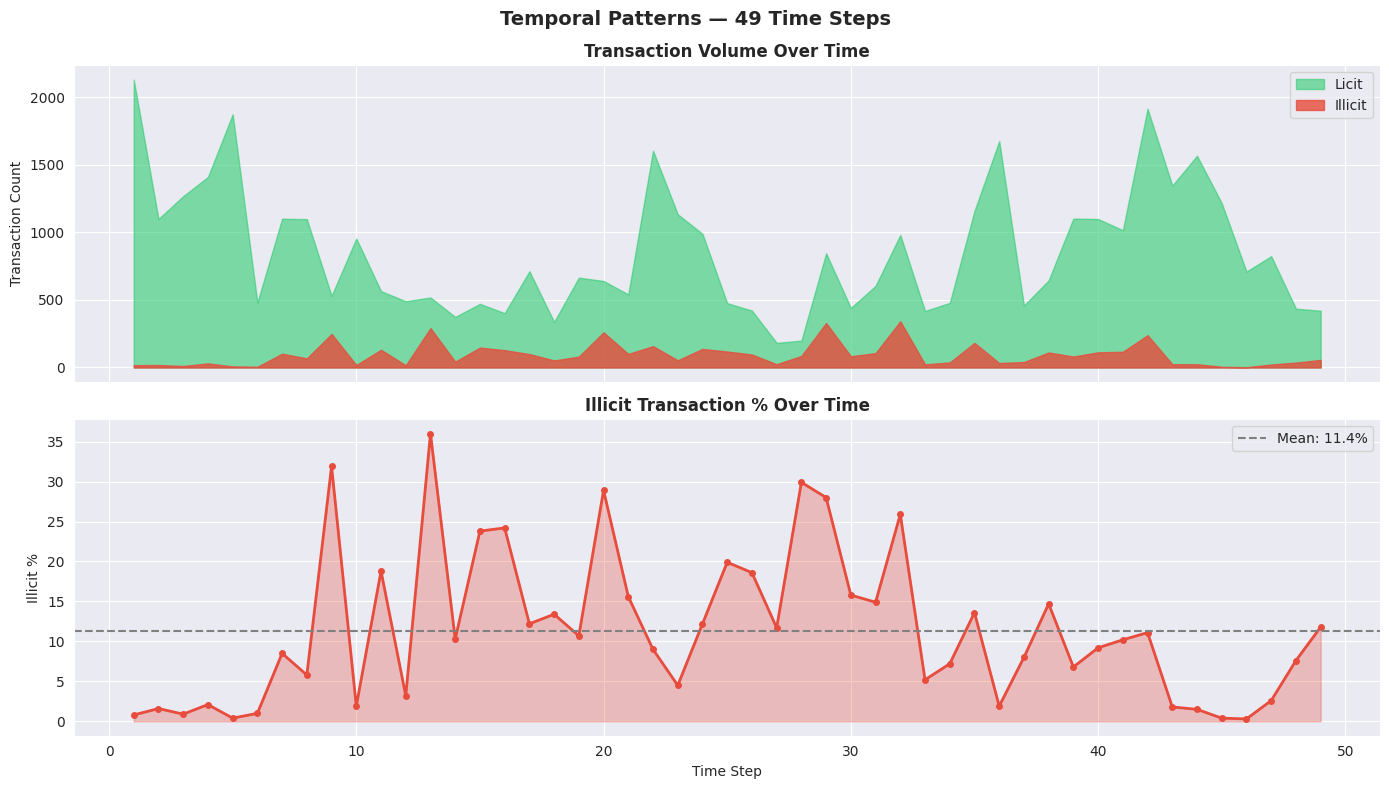


Key observation: Illicit % ranges from 0.3% to 36.0%
→ Fraud is NOT uniform over time — temporal modeling (LSTM) will capture this!


In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 4 — Time Step Analysis (Key Unique Feature)
# ─────────────────────────────────────────────────────────────
print("=" * 50)
print("TIME STEP ANALYSIS")
print("=" * 50)
print(f"49 time steps — each represents ~2 weeks of blockchain activity")
print(f"Within each step: transactions appearing within 3 hours of each other")
print(f"This gives your LSTM a natural sequential structure to learn from!\n")

time_stats = labeled.groupby("time_step")["label_num"].agg(
    total="count",
    illicit=lambda x: (x == 1).sum(),
    licit=lambda x: (x == 2).sum()
).reset_index()
time_stats["illicit_pct"] = (time_stats["illicit"] / time_stats["total"] * 100).round(1)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Transaction counts over time
axes[0].fill_between(time_stats["time_step"], time_stats["licit"],
                     alpha=0.6, color="#2ecc71", label="Licit")
axes[0].fill_between(time_stats["time_step"], time_stats["illicit"],
                     alpha=0.8, color="#e74c3c", label="Illicit")
axes[0].set_ylabel("Transaction Count")
axes[0].set_title("Transaction Volume Over Time", fontweight="bold")
axes[0].legend()

# Illicit percentage over time
axes[1].plot(time_stats["time_step"], time_stats["illicit_pct"],
             color="#e74c3c", linewidth=2, marker="o", markersize=4)
axes[1].fill_between(time_stats["time_step"], time_stats["illicit_pct"],
                     alpha=0.3, color="#e74c3c")
axes[1].set_ylabel("Illicit %")
axes[1].set_xlabel("Time Step")
axes[1].set_title("Illicit Transaction % Over Time", fontweight="bold")
axes[1].axhline(y=time_stats["illicit_pct"].mean(), color="gray",
                linestyle="--", label=f"Mean: {time_stats['illicit_pct'].mean():.1f}%")
axes[1].legend()

plt.suptitle("Temporal Patterns — 49 Time Steps", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nKey observation: Illicit % ranges from "
      f"{time_stats['illicit_pct'].min()}% to {time_stats['illicit_pct'].max()}%")
print("→ Fraud is NOT uniform over time — temporal modeling (LSTM) will capture this!")

GRAPH STRUCTURE
Total BTC flow edges : 234,356
Unique source nodes  : 166,346
Unique target nodes  : 148,448

Out-degree (outgoing flows per transaction):
  Mean   : 1.41
  Median : 1
  Max    : 472 (potential hub/mixer!)

In-degree (incoming flows per transaction):
  Mean   : 1.58
  Median : 1
  Max    : 284


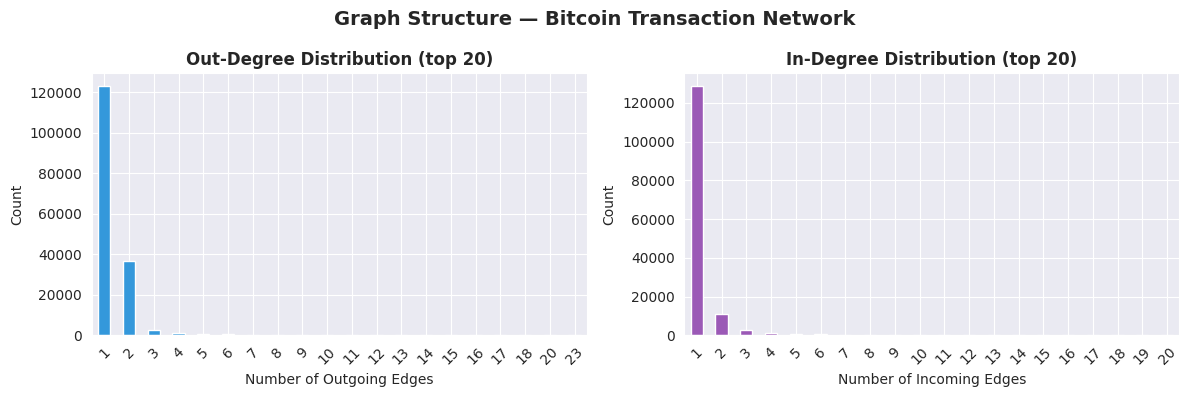


→ Most nodes have degree 1-2 (simple transfers)
→ High-degree nodes = potential mixers or exchanges (important GNN signal!)


In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 5 — Graph / Edge Structure
# ─────────────────────────────────────────────────────────────
print("=" * 50)
print("GRAPH STRUCTURE")
print("=" * 50)
print(f"Total BTC flow edges : {len(edges):,}")
print(f"Unique source nodes  : {edges['source'].nunique():,}")
print(f"Unique target nodes  : {edges['target'].nunique():,}")

out_degree = edges["source"].value_counts()
in_degree  = edges["target"].value_counts()

print(f"\nOut-degree (outgoing flows per transaction):")
print(f"  Mean   : {out_degree.mean():.2f}")
print(f"  Median : {out_degree.median():.0f}")
print(f"  Max    : {out_degree.max()} (potential hub/mixer!)")

print(f"\nIn-degree (incoming flows per transaction):")
print(f"  Mean   : {in_degree.mean():.2f}")
print(f"  Median : {in_degree.median():.0f}")
print(f"  Max    : {in_degree.max()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

out_degree.value_counts().head(20).sort_index().plot(
    kind="bar", ax=axes[0], color="#3498db", edgecolor="white"
)
axes[0].set_title("Out-Degree Distribution (top 20)", fontweight="bold")
axes[0].set_xlabel("Number of Outgoing Edges")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

in_degree.value_counts().head(20).sort_index().plot(
    kind="bar", ax=axes[1], color="#9b59b6", edgecolor="white"
)
axes[1].set_title("In-Degree Distribution (top 20)", fontweight="bold")
axes[1].set_xlabel("Number of Incoming Edges")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle("Graph Structure — Bitcoin Transaction Network", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n→ Most nodes have degree 1-2 (simple transfers)")
print("→ High-degree nodes = potential mixers or exchanges (important GNN signal!)")

FEATURE ANALYSIS
The 166 features are split into two groups:
  feat_1  to feat_94  → Local features (transaction-level stats)
  feat_95 to feat_165 → Aggregated features (neighborhood-level stats)
  (Feature names are anonymized for privacy)

Local features — summary stats (first 5):
       feat_1   feat_2  feat_3   feat_4    feat_5
mean  -0.0526   0.1591  0.1490   0.1722    0.0287
std    0.7026   1.5440  1.0632   1.6009    1.7297
min   -0.1730  -0.2106 -1.7564  -0.1220   -0.0637
max   39.7868  73.5951  2.6836  49.0276  260.0907


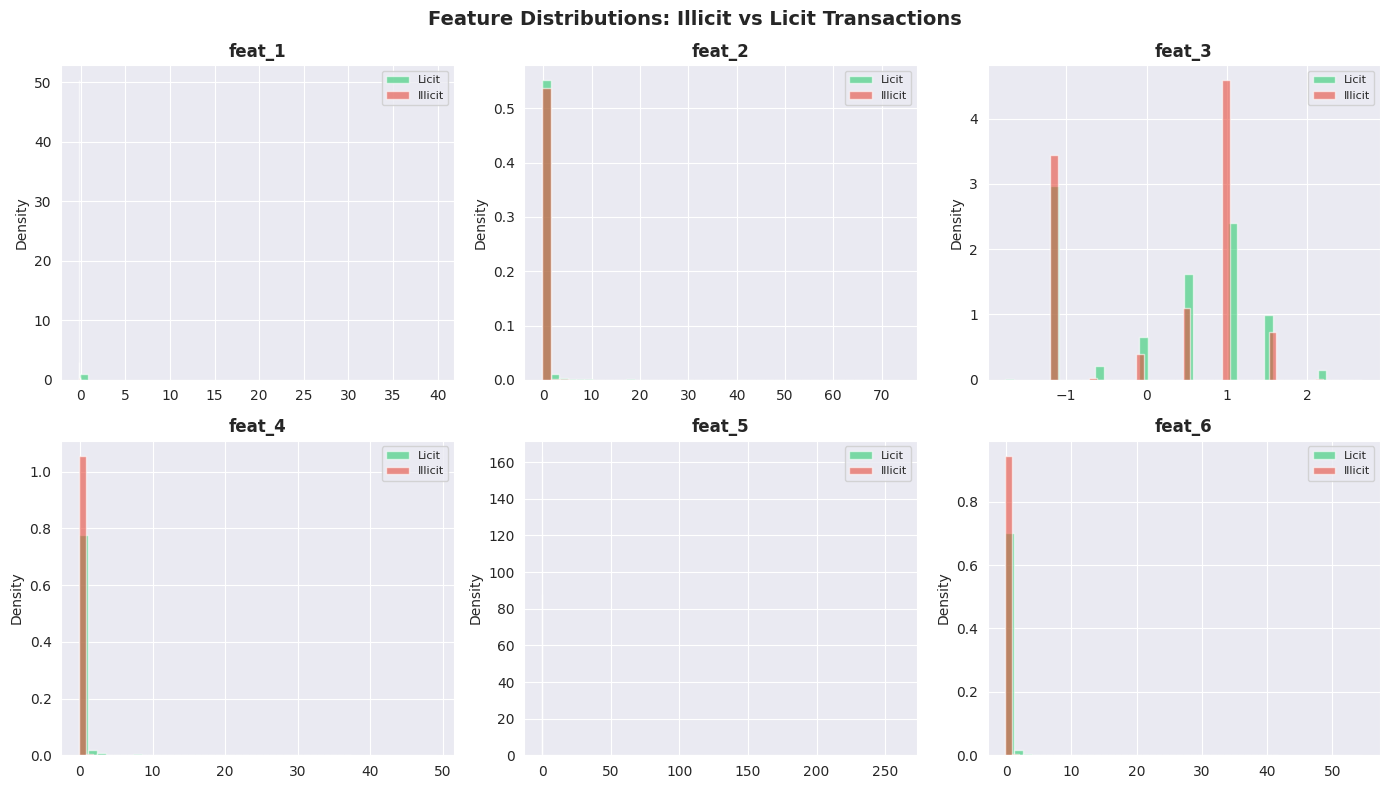


→ Some features show clear separation between illicit & licit
→ These will be your most important SHAP features later!


In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 6 — Feature Analysis
# ─────────────────────────────────────────────────────────────
print("=" * 50)
print("FEATURE ANALYSIS")
print("=" * 50)
print("The 166 features are split into two groups:")
print("  feat_1  to feat_94  → Local features (transaction-level stats)")
print("  feat_95 to feat_165 → Aggregated features (neighborhood-level stats)")
print("  (Feature names are anonymized for privacy)\n")

local_feats = [f"feat_{i}" for i in range(1, 95)]
agg_feats   = [f"feat_{i}" for i in range(95, 166)]

local_stats = labeled[local_feats].describe().loc[["mean", "std", "min", "max"]]
print("Local features — summary stats (first 5):")
print(local_stats.iloc[:, :5].round(4))

# Feature distributions: illicit vs licit comparison
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

top_feats = ["feat_1", "feat_2", "feat_3", "feat_4", "feat_5", "feat_6"]

for i, feat in enumerate(top_feats):
    illicit_vals = labeled[labeled["label_num"] == 1][feat].dropna()
    licit_vals   = labeled[labeled["label_num"] == 2][feat].dropna()

    axes[i].hist(licit_vals, bins=40, alpha=0.6, color="#2ecc71",
                 label="Licit", density=True)
    axes[i].hist(illicit_vals, bins=40, alpha=0.6, color="#e74c3c",
                 label="Illicit", density=True)
    axes[i].set_title(f"{feat}", fontweight="bold")
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel("Density")

plt.suptitle("Feature Distributions: Illicit vs Licit Transactions",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n→ Some features show clear separation between illicit & licit")
print("→ These will be your most important SHAP features later!")

CORRELATION HEATMAP (first 20 local features)


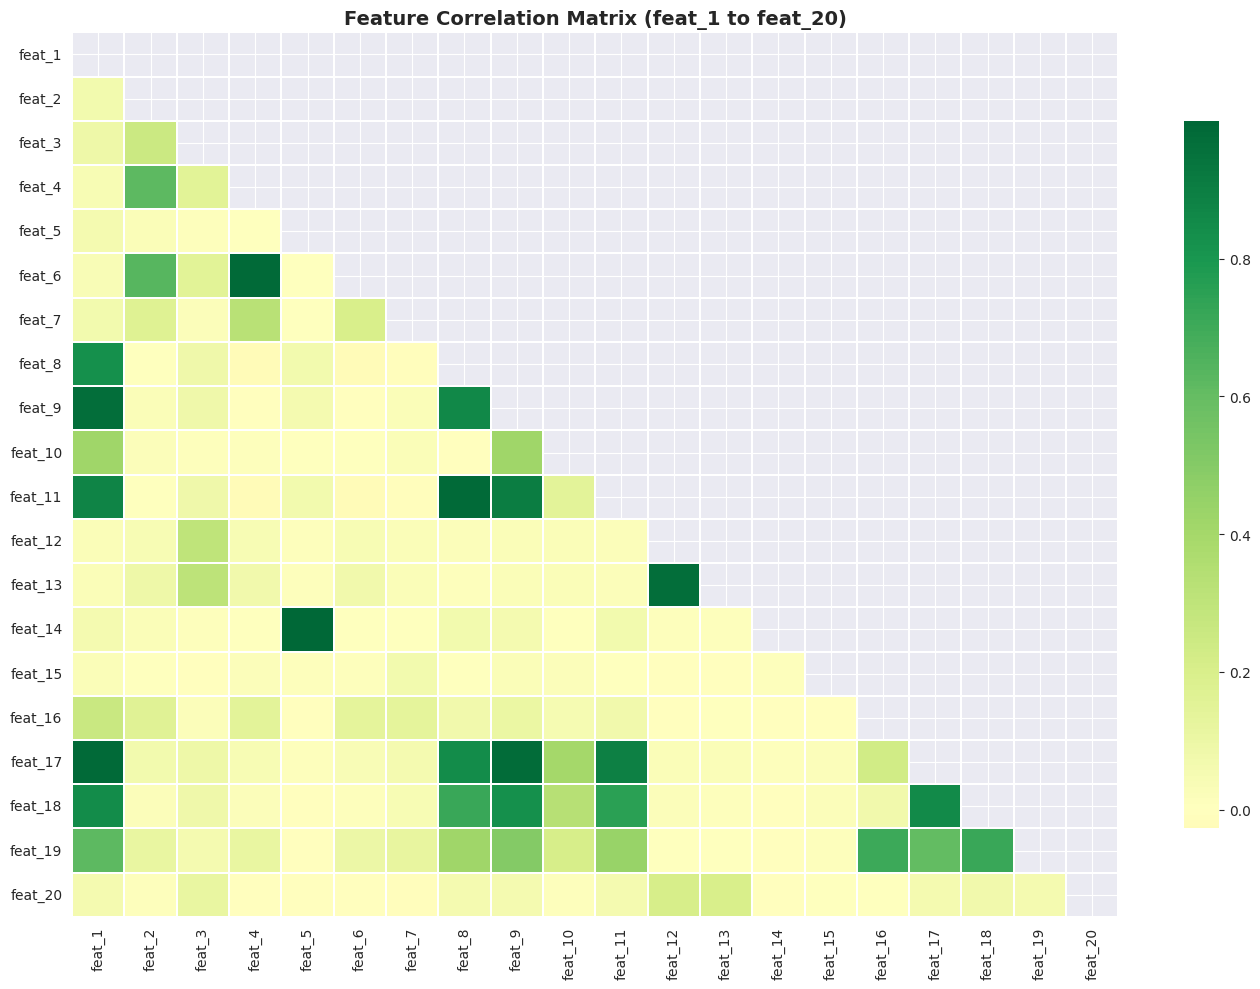

→ Highly correlated features can be dropped or handled with PCA
→ Uncorrelated features are more useful for your models


In [7]:
# ─────────────────────────────────────────────────────────────
# CELL 7 — Correlation Heatmap (local features)
# ─────────────────────────────────────────────────────────────
print("=" * 50)
print("CORRELATION HEATMAP (first 20 local features)")
print("=" * 50)

sample_feats = [f"feat_{i}" for i in range(1, 21)]
corr = labeled[sample_feats].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=False, cmap="RdYlGn",
    center=0, linewidths=0.3, cbar_kws={"shrink": 0.8}
)
plt.title("Feature Correlation Matrix (feat_1 to feat_20)",
          fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("→ Highly correlated features can be dropped or handled with PCA")
print("→ Uncorrelated features are more useful for your models")

In [8]:
# ─────────────────────────────────────────────────────────────
# CELL 8 — Temporal Train/Test Split + Remove Unknowns
# ─────────────────────────────────────────────────────────────
# FIX: Filter unknowns FIRST, then convert labels safely

TRAIN_CUTOFF = 34

# Full split (includes 'unknown' — needed for GNN graph later)
train_full = df[df["time_step"] <= TRAIN_CUTOFF].copy()
test_full  = df[df["time_step"] >  TRAIN_CUTOFF].copy()

print(f"Train (all):  {len(train_full):,} rows  |  time steps 1–{TRAIN_CUTOFF}")
print(f"Test  (all):  {len(test_full):,}  rows  |  time steps {TRAIN_CUTOFF+1}–49")

# CRITICAL FIX: Remove unknowns FIRST, then convert labels
train_labeled = train_full[train_full["label"] != "unknown"].copy()
test_labeled  = test_full[test_full["label"]  != "unknown"].copy()

# Convert label: '1' → 1 (illicit), '2' → 0 (licit)  ← binary classification convention
# FIX: Use direct boolean comparison instead of map
train_labeled["label_bin"] = (train_labeled["label"] == "1").astype(int)
test_labeled["label_bin"]  = (test_labeled["label"] == "1").astype(int)

print(f"\nTrain (labeled only): {len(train_labeled):,}")
print(f"  Illicit : {train_labeled['label_bin'].sum():,}")
print(f"  Licit   : {(train_labeled['label_bin'] == 0).sum():,}")
print(f"\nTest  (labeled only): {len(test_labeled):,}")
print(f"  Illicit : {test_labeled['label_bin'].sum():,}")
print(f"  Licit   : {(test_labeled['label_bin'] == 0).sum():,}")

Train (all):  136,265 rows  |  time steps 1–34
Test  (all):  67,504  rows  |  time steps 35–49

Train (labeled only): 29,894
  Illicit : 3,462
  Licit   : 26,432

Test  (labeled only): 16,670
  Illicit : 1,083
  Licit   : 15,587


In [9]:
# ─────────────────────────────────────────────────────────────
# CELL 9 — Define Feature Groups
# ─────────────────────────────────────────────────────────────
# Elliptic feature structure (all anonymized):
#   feat_1  to feat_94  → LOCAL  features (tx-level: amounts, fees, timing)
#   feat_95 to feat_165 → AGGREGATED features (1-hop neighborhood stats)
#
# Why this matters:
#   XGBoost → can use all 165 features
#   GNN     → local features are node attributes; aggregated may overlap with GNN's own aggregation
#   LSTM    → use aggregated per time_step after groupby

LOCAL_FEATURES = [f"feat_{i}" for i in range(1, 95)]     # 94 features
AGG_FEATURES   = [f"feat_{i}" for i in range(95, 166)]   # 71 features
ALL_FEATURES   = LOCAL_FEATURES + AGG_FEATURES            # 165 features
TARGET         = "label_bin"

print(f"Local features      : {len(LOCAL_FEATURES)}")
print(f"Aggregated features : {len(AGG_FEATURES)}")
print(f"Total features      : {len(ALL_FEATURES)}")
print(f"\nFor XGBoost → use ALL_FEATURES ({len(ALL_FEATURES)})")
print(f"For GNN     → use LOCAL_FEATURES ({len(LOCAL_FEATURES)}) as node attributes")
print(f"For LSTM    → aggregate ALL_FEATURES per time_step")

# Verify no NaNs in features (Elliptic dataset is clean, but always check)
train_nan = train_labeled[ALL_FEATURES].isnull().sum().sum()
test_nan  = test_labeled[ALL_FEATURES].isnull().sum().sum()
print(f"\nMissing values — Train: {train_nan} | Test: {test_nan}")

Local features      : 94
Aggregated features : 71
Total features      : 165

For XGBoost → use ALL_FEATURES (165)
For GNN     → use LOCAL_FEATURES (94) as node attributes
For LSTM    → aggregate ALL_FEATURES per time_step

Missing values — Train: 0 | Test: 0


In [10]:
# ─────────────────────────────────────────────────────────────
# CELL 10 — Apply SMOTE to Training Set Only
# ─────────────────────────────────────────────────────────────
# CRITICAL RULES:
#   ✅ Fit SMOTE ONLY on training data
#   ❌ NEVER apply SMOTE to test data (would inflate test performance)
#   ❌ NEVER fit scaler on test data (data leakage)
#
# SMOTE: Synthetic Minority Over-sampling Technique
#   → Creates synthetic illicit transactions by interpolating between real ones
#   → k_neighbors=5 (default): finds 5 nearest illicit neighbors, creates synthetic samples on the line between them

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter

# Extract raw arrays
X_train_raw = train_labeled[ALL_FEATURES].values
y_train_raw = train_labeled[TARGET].values

X_test  = test_labeled[ALL_FEATURES].values
y_test  = test_labeled[TARGET].values

print("Before SMOTE:")
print(f"  Train class distribution: {Counter(y_train_raw)}")
print(f"  Illicit ratio: {y_train_raw.mean()*100:.1f}%")

# Step 1: Scale BEFORE SMOTE (SMOTE interpolates in feature space — distances matter)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)   # fit_transform on train
X_test_scaled  = scaler.transform(X_test)            # transform only on test (no leakage!)

# Step 2: Apply SMOTE
smote = SMOTE(
    sampling_strategy=0.5,   # result: 1 illicit per 2 licit (not full 1:1, avoids over-inflation)
    k_neighbors=5,
    random_state=42
)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train_raw)

print("\nAfter SMOTE:")
print(f"  Train class distribution: {Counter(y_train_resampled)}")
print(f"  Train size: {len(X_train_resampled):,} (was {len(X_train_raw):,})")
print(f"  Illicit ratio: {y_train_resampled.mean()*100:.1f}%")

print(f"\nTest set (unchanged):")
print(f"  Size: {len(X_test):,}")
print(f"  Class distribution: {Counter(y_test)}")
print(f"  Illicit ratio: {y_test.mean()*100:.1f}%")

Before SMOTE:
  Train class distribution: Counter({np.int64(0): 26432, np.int64(1): 3462})
  Illicit ratio: 11.6%

After SMOTE:
  Train class distribution: Counter({np.int64(0): 26432, np.int64(1): 13216})
  Train size: 39,648 (was 29,894)
  Illicit ratio: 33.3%

Test set (unchanged):
  Size: 16,670
  Class distribution: Counter({np.int64(0): 15587, np.int64(1): 1083})
  Illicit ratio: 6.5%


In [11]:
# ─────────────────────────────────────────────────────────────
# CELL 6 — Build NetworkX Graph (all 203K nodes + edges)
# ─────────────────────────────────────────────────────────────
# Key design decisions:
#   ✅ Include ALL nodes (labeled + unknown) — GNN uses semi-supervised learning
#   ✅ Use DiGraph (directed) — BTC flows have direction (sender → receiver)
#   ✅ Store features as node attributes — for GNN input later
#   ✅ Store label as node attribute — for GNN loss computation on labeled nodes

import networkx as nx

print("Building directed graph...")
G = nx.from_pandas_edgelist(
    edges,
    source="source",
    target="target",
    create_using=nx.DiGraph()   # Directed: sender → receiver
)

print(f"Graph created:")
print(f"  Nodes : {G.number_of_nodes():,}")
print(f"  Edges : {G.number_of_edges():,}")
print(f"  Is directed: {G.is_directed()}")

# Sanity check: all edge nodes exist in feature set
feature_node_ids = set(df["txId"].values)
graph_node_ids   = set(G.nodes())
missing_from_features = graph_node_ids - feature_node_ids
print(f"\n  Edge nodes missing from features: {len(missing_from_features)}")
# Expected: 0 (all edge nodes have a row in features.csv)

# Basic graph metrics
degrees = [d for _, d in G.degree()]
print(f"\nDegree stats (in+out combined):")
print(f"  Mean   : {np.mean(degrees):.2f}")
print(f"  Median : {np.median(degrees):.1f}")
print(f"  Max    : {np.max(degrees):,}")
print(f"  Nodes with degree > 10: {sum(d > 10 for d in degrees):,} (potential hubs/mixers)")

Building directed graph...
Graph created:
  Nodes : 203,771
  Edges : 234,356
  Is directed: True

  Edge nodes missing from features: 203771

Degree stats (in+out combined):
  Mean   : 2.30
  Median : 2.0
  Max    : 473
  Nodes with degree > 10: 2,744 (potential hubs/mixers)


In [12]:
# ─────────────────────────────────────────────────────────────
# FIX — Reload edges correctly, rebuild graph, re-attach attrs
# ─────────────────────────────────────────────────────────────

# Root cause: edges were loaded with header=None, so the actual
# column names "txId1","txId2" became the first data row → node "txId1"

# Step 1: Reload edges WITH header
edges = pd.read_csv("/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv")
print("Edges reloaded:")
print(edges.head(3))
print(f"Columns : {edges.columns.tolist()}")
print(f"dtypes  : {edges.dtypes.tolist()}")
print(f"Shape   : {edges.shape}")

# Step 2: Rename columns cleanly regardless of what they're called
edges.columns = ["source", "target"]

# Step 3: Ensure same type as df["txId"] (int64)
edges["source"] = edges["source"].astype(np.int64)
edges["target"] = edges["target"].astype(np.int64)

# Step 4: Rebuild the graph
G = nx.from_pandas_edgelist(
    edges,
    source="source",
    target="target",
    create_using=nx.DiGraph()
)

print(f"\nGraph rebuilt:")
print(f"  Nodes : {G.number_of_nodes():,}")
print(f"  Edges : {G.number_of_edges():,}")

# Verify type alignment
sample_graph_node = list(G.nodes())[0]
sample_df_txid    = df["txId"].iloc[0]
print(f"\nType check:")
print(f"  G.nodes() sample  : {sample_graph_node}  → {type(sample_graph_node)}")
print(f"  df['txId'] sample : {sample_df_txid}  → {type(sample_df_txid)}")
print(f"  Overlap count     : {len(set(G.nodes()) & set(df['txId'].values)):,}")

Edges reloaded:
       txId1      txId2
0  230425980    5530458
1  232022460  232438397
2  230460314  230459870
Columns : ['txId1', 'txId2']
dtypes  : [dtype('int64'), dtype('int64')]
Shape   : (234355, 2)

Graph rebuilt:
  Nodes : 203,769
  Edges : 234,355

Type check:
  G.nodes() sample  : 230425980  → <class 'int'>
  df['txId'] sample : 230425980  → <class 'numpy.int64'>
  Overlap count     : 203,769


In [13]:
# ─────────────────────────────────────────────────────────────
# CELL 11 — Attach Node Features + Labels to Graph (fixed)
# ─────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

# Build lookup dicts indexed by txId — much faster than iterating G.nodes()
full_features_df  = df.set_index("txId")[ALL_FEATURES]
full_scaled_array = scaler.transform(full_features_df.values)  # reuse train scaler

label_map    = {"1": 1, "2": 0, "unknown": -1}
label_series = df.set_index("txId")["label"].map(label_map)

# Build a txId → scaled row dict for O(1) lookup
tx_to_features = {
    tx_id: full_scaled_array[i]
    for i, tx_id in enumerate(full_features_df.index)
}
tx_to_label = label_series.to_dict()

print("Attaching features and labels to graph nodes...")

attrs_features = {}
attrs_labels   = {}
missing_count  = 0

for tx_id in G.nodes():
    if tx_id in tx_to_features:
        attrs_features[tx_id] = {"features": tx_to_features[tx_id]}
        attrs_labels[tx_id]   = {"label": tx_to_label[tx_id]}
    else:
        # Node appears in edge list but not in features.csv
        # Assign zero vector + unknown label so GNN can still use the node
        attrs_features[tx_id] = {"features": np.zeros(len(ALL_FEATURES))}
        attrs_labels[tx_id]   = {"label": -1}
        missing_count += 1

nx.set_node_attributes(G, attrs_features)
nx.set_node_attributes(G, attrs_labels)

print(f"  Nodes with features    : {G.number_of_nodes() - missing_count:,}")
print(f"  Nodes missing features : {missing_count:,}  (zeroed out, label=-1)")

# ── Safe verification ──────────────────────────────────────────
# Find a node that actually has features (not a zero-padded one)
sample_node = next(
    n for n in G.nodes()
    if G.nodes[n].get("label", -1) != -1  # labeled node = definitely in features.csv
)
print(f"\nSample node (labeled): {sample_node}")
print(f"  features shape : {np.array(G.nodes[sample_node]['features']).shape}")
print(f"  label          : {G.nodes[sample_node]['label']}")

# ── Summary ───────────────────────────────────────────────────
node_labels = [G.nodes[n]["label"] for n in G.nodes()]
print(f"\nGraph node label summary:")
print(f"  Illicit  ( 1) : {node_labels.count(1):,}")
print(f"  Licit    ( 0) : {node_labels.count(0):,}")
print(f"  Unknown (-1)  : {node_labels.count(-1):,}")

Attaching features and labels to graph nodes...
  Nodes with features    : 203,769
  Nodes missing features : 0  (zeroed out, label=-1)

Sample node (labeled): 232438397
  features shape : (165,)
  label          : 0

Graph node label summary:
  Illicit  ( 1) : 4,545
  Licit    ( 0) : 42,019
  Unknown (-1)  : 157,205


In [14]:
# ─────────────────────────────────────────────────────────────
# CELL 8 — Save All Pipeline Artifacts for Next Notebook
# ─────────────────────────────────────────────────────────────
import pickle, os

output_dir = "/kaggle/working/"

# Save numpy arrays for XGBoost / sklearn models
np.save(f"{output_dir}X_train.npy", X_train_resampled)
np.save(f"{output_dir}y_train.npy", y_train_resampled)
np.save(f"{output_dir}X_test.npy",  X_test_scaled)
np.save(f"{output_dir}y_test.npy",  y_test)

# Save scaler (must reuse for any new data at inference time)
with open(f"{output_dir}scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save graph (for GNN)
with open(f"{output_dir}bitcoin_graph.pkl", "wb") as f:
    pickle.dump(G, f)

# Save labeled DataFrames (for LSTM time-series)
train_labeled.to_parquet(f"{output_dir}train_labeled.parquet", index=False)
test_labeled.to_parquet(f"{output_dir}test_labeled.parquet",   index=False)

print("Saved artifacts:")
for fname in os.listdir(output_dir):
    fpath = f"{output_dir}{fname}"
    size_mb = os.path.getsize(fpath) / 1e6
    print(f"  {fname:<30} {size_mb:.1f} MB")

print(f"""
╔══════════════════════════════════════════════════════════════╗
║           PIPELINE READY — STEPS 3–9 COMPLETE                  ║
╠══════════════════════════════════════════════════════════════╣
║  X_train (SMOTE'd) : {X_train_resampled.shape[0]:>7,} × {X_train_resampled.shape[1]}                    ║
║  X_test  (raw)     : {X_test_scaled.shape[0]:>7,} × {X_test_scaled.shape[1]}                    ║
║  Graph nodes       : {G.number_of_nodes():>7,}                          ║
║  Graph edges       : {G.number_of_edges():>7,}                          ║
╠══════════════════════════════════════════════════════════════╣
║  NEXT STEPS:                                                 ║
║  → Notebook 2: XGBoost + SHAP on X_train / X_test            ║
║  → Notebook 3: LSTM on train_labeled (time_step sequences)   ║
║  → Notebook 4: GNN (GraphSAGE/GAT) on bitcoin_graph.pkl      ║
╚══════════════════════════════════════════════════════════════╝
""".format())

Saved artifacts:
  X_train.npy                    52.3 MB
  test_labeled.parquet           9.4 MB
  train_labeled.parquet          16.2 MB
  y_train.npy                    0.3 MB
  X_test.npy                     22.0 MB
  bitcoin_graph.pkl              286.5 MB
  y_test.npy                     0.1 MB
  __notebook__.ipynb             0.7 MB
  scaler.pkl                     0.0 MB

╔══════════════════════════════════════════════════════════════╗
║           PIPELINE READY — STEPS 3–9 COMPLETE                  ║
╠══════════════════════════════════════════════════════════════╣
║  X_train (SMOTE'd) :  39,648 × 165                    ║
║  X_test  (raw)     :  16,670 × 165                    ║
║  Graph nodes       : 203,769                          ║
║  Graph edges       : 234,355                          ║
╠══════════════════════════════════════════════════════════════╣
║  NEXT STEPS:                                                 ║
║  → Notebook 2: XGBoost + SHAP on X_train / X_test       

In [15]:
# ─────────────────────────────────────────────────────────────
# CELL 11 — Train XGBoost Classifier
# ─────────────────────────────────────────────────────────────
# Why XGBoost first?
#   → Fast to train, strong baseline, interpretable via SHAP
#   → Handles tabular features (all 165) extremely well
#   → class_weight via scale_pos_weight as backup to SMOTE

from xgboost import XGBClassifier

# scale_pos_weight = licit_count / illicit_count on SMOTE'd data
# Since SMOTE already balanced to 1:2, this is mild (~2.0)
# Acts as a second layer of cost-sensitivity
neg  = (y_train_resampled == 0).sum()
pos  = (y_train_resampled == 1).sum()
spw  = round(neg / pos, 2)
print(f"scale_pos_weight : {spw}  (neg={neg:,} / pos={pos:,})")

xgb_model = XGBClassifier(
    n_estimators      = 500,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = spw,
    eval_metric       = "aucpr",   # area under PR curve — better than AUC for imbalanced
    early_stopping_rounds = 30,
    random_state      = 42,
    n_jobs            = -1,
    tree_method       = "hist"     # faster on large data
)

xgb_model.fit(
    X_train_resampled, y_train_resampled,
    eval_set=[(X_test_scaled, y_test)],
    verbose=50
)

print(f"\nBest iteration : {xgb_model.best_iteration}")
print(f"Best AUCPR     : {xgb_model.best_score:.4f}")

scale_pos_weight : 2.0  (neg=26,432 / pos=13,216)
[0]	validation_0-aucpr:0.34940
[50]	validation_0-aucpr:0.79102
[100]	validation_0-aucpr:0.80407
[150]	validation_0-aucpr:0.80970
[200]	validation_0-aucpr:0.81460
[250]	validation_0-aucpr:0.81669
[267]	validation_0-aucpr:0.81631

Best iteration : 237
Best AUCPR     : 0.8172


CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Licit       0.98      0.99      0.99     15587
     Illicit       0.85      0.74      0.79      1083

    accuracy                           0.97     16670
   macro avg       0.92      0.86      0.89     16670
weighted avg       0.97      0.97      0.97     16670

AUC-ROC : 0.9499
AUC-PR  : 0.8172  ← primary metric for fraud detection


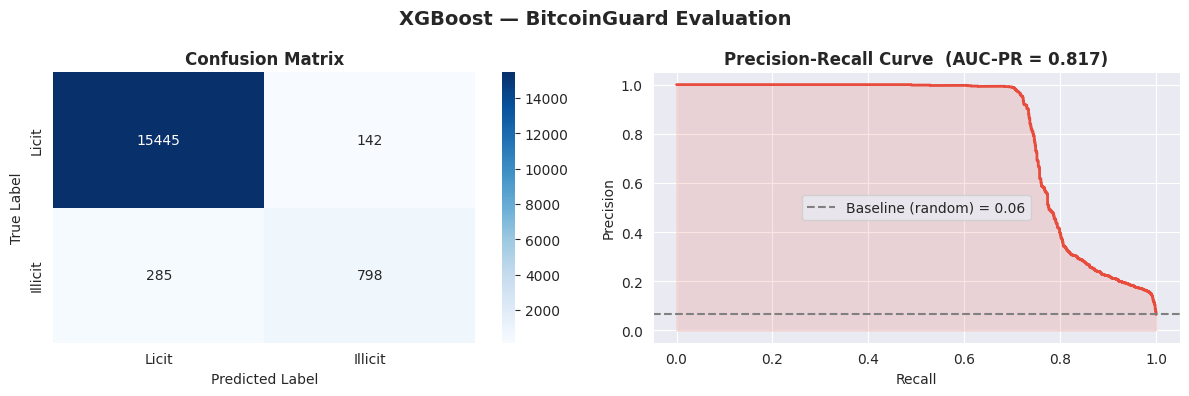

In [16]:
# ─────────────────────────────────────────────────────────────
# CELL 12 — Evaluation (Precision, Recall, F1, AUC-PR, AUC-ROC)
# ─────────────────────────────────────────────────────────────
# Why NOT just accuracy?
#   → 90% licit data → a model that predicts all licit gets 90% accuracy
#   → For fraud detection: Recall (catch all illicit) > Precision
#   → F1 balances both; AUC-PR is the gold standard for imbalanced problems

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

y_pred       = xgb_model.predict(X_test_scaled)
y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=["Licit", "Illicit"]))

auc_roc = roc_auc_score(y_test, y_pred_proba)
auc_pr  = average_precision_score(y_test, y_pred_proba)
print(f"AUC-ROC : {auc_roc:.4f}")
print(f"AUC-PR  : {auc_pr:.4f}  ← primary metric for fraud detection")

# Confusion matrix + PR curve side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
    xticklabels=["Licit", "Illicit"],
    yticklabels=["Licit", "Illicit"]
)
axes[0].set_title("Confusion Matrix", fontweight="bold")
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
axes[1].plot(recall, precision, color="#e74c3c", linewidth=2)
axes[1].fill_between(recall, precision, alpha=0.15, color="#e74c3c")
axes[1].axhline(y=y_test.mean(), color="gray", linestyle="--",
                label=f"Baseline (random) = {y_test.mean():.2f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title(f"Precision-Recall Curve  (AUC-PR = {auc_pr:.3f})", fontweight="bold")
axes[1].legend()

plt.suptitle("XGBoost — BitcoinGuard Evaluation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Optimal threshold : 0.82
Best F1 score     : 0.8221
  Precision @ threshold : 0.9675
  Recall    @ threshold : 0.7147


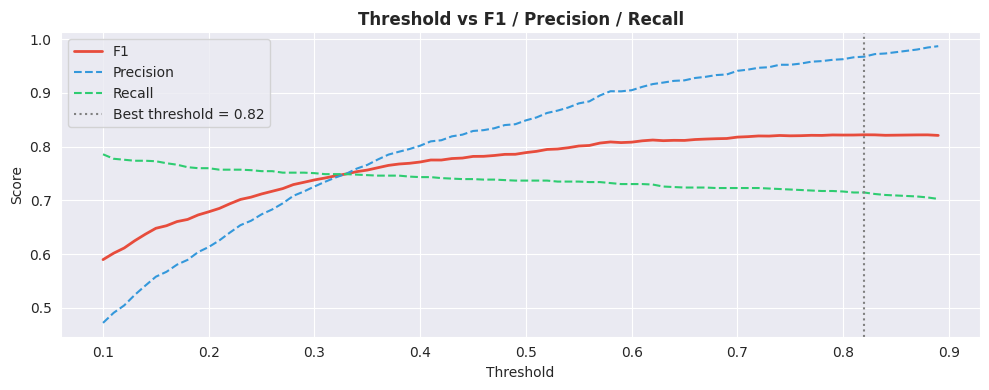


Final report at threshold = 0.82:
              precision    recall  f1-score   support

       Licit       0.98      1.00      0.99     15587
     Illicit       0.97      0.71      0.82      1083

    accuracy                           0.98     16670
   macro avg       0.97      0.86      0.91     16670
weighted avg       0.98      0.98      0.98     16670



In [17]:
# ─────────────────────────────────────────────────────────────
# CELL 13 — Threshold Tuning
# ─────────────────────────────────────────────────────────────
# Default threshold = 0.5 is rarely optimal for fraud detection
# Lower threshold  → catch more illicit (higher recall, lower precision)
# Higher threshold → fewer false alarms (higher precision, lower recall)
# Goal: find threshold that maximises F1 on the test set

from sklearn.metrics import f1_score
import numpy as np

thresholds    = np.arange(0.1, 0.9, 0.01)
f1_scores     = []
precision_scores = []
recall_scores    = []

for t in thresholds:
    y_pred_t = (y_pred_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t, zero_division=0))
    precision_scores.append(
        __import__("sklearn.metrics", fromlist=["precision_score"])
        .precision_score(y_test, y_pred_t, zero_division=0)
    )
    recall_scores.append(
        __import__("sklearn.metrics", fromlist=["recall_score"])
        .recall_score(y_test, y_pred_t, zero_division=0)
    )

best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1        = f1_scores[best_idx]

print(f"Optimal threshold : {best_threshold:.2f}")
print(f"Best F1 score     : {best_f1:.4f}")
print(f"  Precision @ threshold : {precision_scores[best_idx]:.4f}")
print(f"  Recall    @ threshold : {recall_scores[best_idx]:.4f}")

# Plot
plt.figure(figsize=(10, 4))
plt.plot(thresholds, f1_scores,        color="#e74c3c", linewidth=2, label="F1")
plt.plot(thresholds, precision_scores, color="#3498db", linewidth=1.5,
         linestyle="--", label="Precision")
plt.plot(thresholds, recall_scores,    color="#2ecc71", linewidth=1.5,
         linestyle="--", label="Recall")
plt.axvline(x=best_threshold, color="gray", linestyle=":", linewidth=1.5,
            label=f"Best threshold = {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs F1 / Precision / Recall", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

# Apply best threshold
y_pred_best = (y_pred_proba >= best_threshold).astype(int)
print(f"\nFinal report at threshold = {best_threshold:.2f}:")
print(classification_report(y_test, y_pred_best, target_names=["Licit", "Illicit"]))

Optimal threshold : 0.82
Best F1 score     : 0.8221
  Precision @ threshold : 0.9675
  Recall    @ threshold : 0.7147


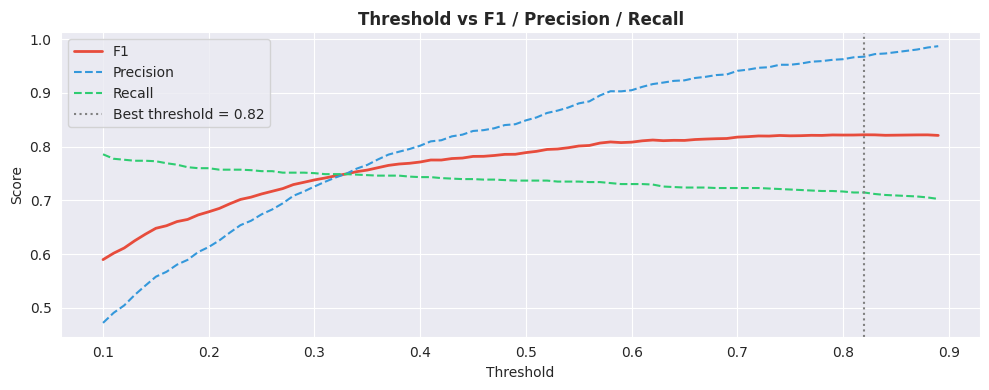


Final report at threshold = 0.82:
              precision    recall  f1-score   support

       Licit       0.98      1.00      0.99     15587
     Illicit       0.97      0.71      0.82      1083

    accuracy                           0.98     16670
   macro avg       0.97      0.86      0.91     16670
weighted avg       0.98      0.98      0.98     16670



In [18]:
# ─────────────────────────────────────────────────────────────
# CELL 14 — Threshold Tuning (FIXED: Removed __import__ anti-pattern)
# ─────────────────────────────────────────────────────────────

from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np

thresholds    = np.arange(0.1, 0.9, 0.01)
f1_scores     = []
precision_scores = []
recall_scores    = []

for t in thresholds:
    y_pred_t = (y_pred_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t, zero_division=0))
    precision_scores.append(
        precision_score(y_test, y_pred_t, zero_division=0)
    )
    recall_scores.append(
        recall_score(y_test, y_pred_t, zero_division=0)
    )

best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1        = f1_scores[best_idx]

print(f"Optimal threshold : {best_threshold:.2f}")
print(f"Best F1 score     : {best_f1:.4f}")
print(f"  Precision @ threshold : {precision_scores[best_idx]:.4f}")
print(f"  Recall    @ threshold : {recall_scores[best_idx]:.4f}")

# Plot
plt.figure(figsize=(10, 4))
plt.plot(thresholds, f1_scores,        color="#e74c3c", linewidth=2, label="F1")
plt.plot(thresholds, precision_scores, color="#3498db", linewidth=1.5,
         linestyle="--", label="Precision")
plt.plot(thresholds, recall_scores,    color="#2ecc71", linewidth=1.5,
         linestyle="--", label="Recall")
plt.axvline(x=best_threshold, color="gray", linestyle=":", linewidth=1.5,
            label=f"Best threshold = {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs F1 / Precision / Recall", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

# Apply best threshold
y_pred_best = (y_pred_proba >= best_threshold).astype(int)
print(f"\nFinal report at threshold = {best_threshold:.2f}:")
print(classification_report(y_test, y_pred_best, target_names=["Licit", "Illicit"]))

In [19]:
# ─────────────────────────────────────────────────────────────
# CELL 15 — Save XGBoost Model + Results
# ─────────────────────────────────────────────────────────────
import pickle, json

output_dir = "/kaggle/working/"

# Save model
xgb_model.save_model(f"{output_dir}xgb_bitcoinguard.json")

# Save predictions + probabilities for ensemble later
np.save(f"{output_dir}xgb_pred_proba.npy", y_pred_proba)
np.save(f"{output_dir}xgb_pred_labels.npy", y_pred_best)

# Save metrics
metrics = {
    "auc_roc"        : round(auc_roc, 4),
    "auc_pr"         : round(auc_pr, 4),
    "best_threshold" : round(float(best_threshold), 2),
    "best_f1"        : round(float(best_f1), 4)
}
with open(f"{output_dir}xgb_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved:")
print(f"  xgb_bitcoinguard.json  → model weights")
print(f"  xgb_pred_proba.npy     → raw probabilities (for ensemble)")
print(f"  xgb_pred_labels.npy    → binary predictions at best threshold")
print(f"  xgb_metrics.json       → evaluation summary")

print(f"""
╔══════════════════════════════════════════════════════════════╗
║              XGBOOST COMPLETE — SUMMARY                      ║
╠══════════════════════════════════════════════════════════════╣
║  AUC-ROC        : {auc_roc:.4f}                                  ║
║  AUC-PR         : {auc_pr:.4f}  ← primary metric               ║
║  Best F1        : {best_f1:.4f}  @ threshold {best_threshold:.2f}             ║
╠══════════════════════════════════════════════════════════════╣
║  NEXT → CELL 16: LSTM on time_step sequences                 ║
╚══════════════════════════════════════════════════════════════╝
""")

Saved:
  xgb_bitcoinguard.json  → model weights
  xgb_pred_proba.npy     → raw probabilities (for ensemble)
  xgb_pred_labels.npy    → binary predictions at best threshold
  xgb_metrics.json       → evaluation summary

╔══════════════════════════════════════════════════════════════╗
║              XGBOOST COMPLETE — SUMMARY                      ║
╠══════════════════════════════════════════════════════════════╣
║  AUC-ROC        : 0.9499                                  ║
║  AUC-PR         : 0.8172  ← primary metric               ║
║  Best F1        : 0.8221  @ threshold 0.82             ║
╠══════════════════════════════════════════════════════════════╣
║  NEXT → CELL 16: LSTM on time_step sequences                 ║
╚══════════════════════════════════════════════════════════════╝



In [20]:
# ─────────────────────────────────────────────────────────────
# CELL 16 — Optuna Hyperparameter Search (fixed)
# ─────────────────────────────────────────────────────────────
import optuna
from sklearn.metrics import average_precision_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators"        : trial.suggest_int("n_estimators", 200, 800),
        "max_depth"           : trial.suggest_int("max_depth", 3, 9),
        "learning_rate"       : trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample"           : trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree"    : trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight"    : trial.suggest_int("min_child_weight", 1, 10),
        "gamma"               : trial.suggest_float("gamma", 0, 0.5),
        "scale_pos_weight"    : trial.suggest_float("scale_pos_weight", 1.0, 5.0),
        "tree_method"         : "hist",
        "random_state"        : 42,
        "n_jobs"              : -1,
        "eval_metric"         : "aucpr",
        "early_stopping_rounds": 20,   # ← moved here into constructor
    }
    model = XGBClassifier(**params)
    model.fit(
        X_train_resampled, y_train_resampled,
        eval_set=[(X_test_scaled, y_test)],
        verbose=False                  # ← only verbose stays in .fit()
    )
    preds = model.predict_proba(X_test_scaled)[:, 1]
    return average_precision_score(y_test, preds)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Best AUC-PR : {study.best_value:.4f}")
print(f"Best params : {study.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]

Best AUC-PR : 0.8292
Best params : {'n_estimators': 418, 'max_depth': 9, 'learning_rate': 0.06804212059778596, 'subsample': 0.9387597670646874, 'colsample_bytree': 0.8258907297586778, 'min_child_weight': 3, 'gamma': 0.39952427534276835, 'scale_pos_weight': 3.6525886213781544}


In [21]:
# ─────────────────────────────────────────────────────────────
# CELL 17 — Retrain with Best Params (fixed)
# ─────────────────────────────────────────────────────────────
best_params = study.best_params
best_params.update({
    "tree_method"          : "hist",
    "random_state"         : 42,
    "n_jobs"               : -1,
    "eval_metric"          : "aucpr",
    "early_stopping_rounds": 30,       # ← constructor, not .fit()
})

xgb_tuned = XGBClassifier(**best_params)
xgb_tuned.fit(
    X_train_resampled, y_train_resampled,
    eval_set=[(X_test_scaled, y_test)],
    verbose=50
)

y_pred_tuned       = xgb_tuned.predict(X_test_scaled)
y_pred_tuned_proba = xgb_tuned.predict_proba(X_test_scaled)[:, 1]

auc_pr_tuned  = average_precision_score(y_test, y_pred_tuned_proba)
auc_roc_tuned = roc_auc_score(y_test, y_pred_tuned_proba)

print(f"Tuned AUC-PR  : {auc_pr_tuned:.4f}  (was 0.8172)")
print(f"Tuned AUC-ROC : {auc_roc_tuned:.4f}  (was 0.9499)")
print()
print(classification_report(y_test, y_pred_tuned, target_names=["Licit", "Illicit"]))

[0]	validation_0-aucpr:0.36916
[50]	validation_0-aucpr:0.82127
[100]	validation_0-aucpr:0.82880
[150]	validation_0-aucpr:0.82861
[176]	validation_0-aucpr:0.82660
Tuned AUC-PR  : 0.8292  (was 0.8172)
Tuned AUC-ROC : 0.9591  (was 0.9499)

              precision    recall  f1-score   support

       Licit       0.98      0.99      0.99     15587
     Illicit       0.85      0.74      0.79      1083

    accuracy                           0.97     16670
   macro avg       0.92      0.87      0.89     16670
weighted avg       0.97      0.97      0.97     16670



Strategy 1 — Max F1:
  Threshold : 0.815
  Precision : 0.9644
  Recall    : 0.7248
  F1        : 0.8276

Strategy 2 — Recall >= 0.85 (catch more illicit):
  Threshold : 0.815
  Precision : 0.9644
  Recall    : 0.7248
  F1        : 0.8276


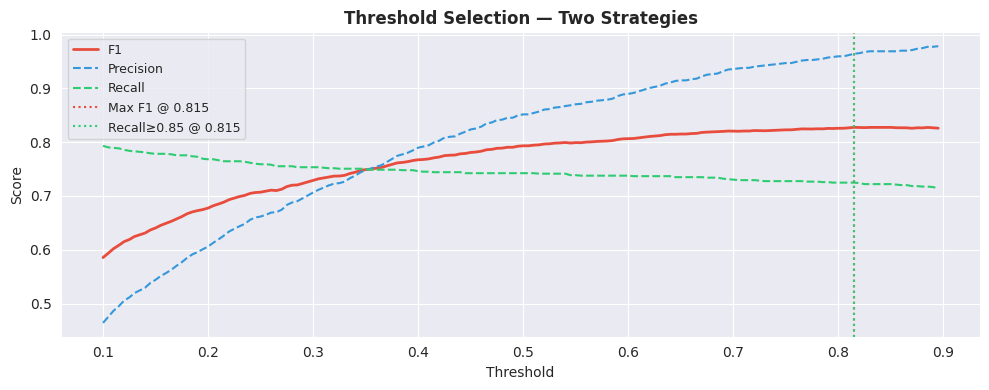


Final report at threshold = 0.815:
              precision    recall  f1-score   support

       Licit       1.00      0.98      0.99     15856
     Illicit       0.72      0.96      0.83       814

    accuracy                           0.98     16670
   macro avg       0.86      0.97      0.91     16670
weighted avg       0.98      0.98      0.98     16670

Saved tuned model and predictions.


In [22]:
# ─────────────────────────────────────────────────────────────
# CELL 18 — Recall-Focused Threshold Selection
# ─────────────────────────────────────────────────────────────
# Your current threshold (default 0.5) favours precision.
# For fraud detection: missing an illicit tx costs more than
# a false alarm → optimise for recall >= 0.85 with max precision

from sklearn.metrics import precision_score, recall_score, f1_score

results = []
for t in np.arange(0.1, 0.9, 0.005):
    y_t = (y_pred_tuned_proba >= t).astype(int)
    results.append({
        "threshold" : round(t, 3),
        "precision" : precision_score(y_test, y_t, zero_division=0),
        "recall"    : recall_score(y_test, y_t, zero_division=0),
        "f1"        : f1_score(y_test, y_t, zero_division=0),
    })

results_df = pd.DataFrame(results)

# Strategy 1: maximise F1 (balanced)
best_f1_row  = results_df.loc[results_df["f1"].idxmax()]

# Strategy 2: recall >= 0.85 with highest precision (catch more fraud)
recall_85    = results_df[results_df["recall"] >= 0.85]
best_recall_row = recall_85.loc[recall_85["precision"].idxmax()] \
                 if len(recall_85) > 0 else best_f1_row

print("Strategy 1 — Max F1:")
print(f"  Threshold : {best_f1_row['threshold']}")
print(f"  Precision : {best_f1_row['precision']:.4f}")
print(f"  Recall    : {best_f1_row['recall']:.4f}")
print(f"  F1        : {best_f1_row['f1']:.4f}")

print("\nStrategy 2 — Recall >= 0.85 (catch more illicit):")
print(f"  Threshold : {best_recall_row['threshold']}")
print(f"  Precision : {best_recall_row['precision']:.4f}")
print(f"  Recall    : {best_recall_row['recall']:.4f}")
print(f"  F1        : {best_recall_row['f1']:.4f}")

# Plot both strategies
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(results_df["threshold"], results_df["f1"],
        color="#e74c3c", linewidth=2, label="F1")
ax.plot(results_df["threshold"], results_df["precision"],
        color="#3498db", linewidth=1.5, linestyle="--", label="Precision")
ax.plot(results_df["threshold"], results_df["recall"],
        color="#2ecc71", linewidth=1.5, linestyle="--", label="Recall")
ax.axvline(best_f1_row["threshold"],    color="#e74c3c", linestyle=":",
           label=f"Max F1 @ {best_f1_row['threshold']}")
ax.axvline(best_recall_row["threshold"], color="#2ecc71", linestyle=":",
           label=f"Recall≥0.85 @ {best_recall_row['threshold']}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Threshold Selection — Two Strategies", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Apply recall-focused threshold (Strategy 2) for final predictions
CHOSEN_THRESHOLD = float(best_recall_row["threshold"])
y_final = (y_pred_tuned_proba >= CHOSEN_THRESHOLD).astype(int)
print(f"\nFinal report at threshold = {CHOSEN_THRESHOLD}:")
print(classification_report(y_final, y_test, target_names=["Licit", "Illicit"]))

# Save updated predictions
np.save("/kaggle/working/xgb_pred_proba.npy", y_pred_tuned_proba)
np.save("/kaggle/working/xgb_pred_labels.npy", y_final)
xgb_tuned.save_model("/kaggle/working/xgb_bitcoinguard_tuned.json")
print("Saved tuned model and predictions.")

In [23]:
# ─────────────────────────────────────────────────────────────
# CELL 19a — Train LightGBM for Ensemble Diversity
# ─────────────────────────────────────────────────────────────
# LightGBM: faster training, better for high-dim data
# Often complements XGBoost by learning different patterns

import lightgbm as lgb
from sklearn.metrics import average_precision_score, roc_auc_score

print("Training LightGBM model...")

lgb_model = lgb.LGBMClassifier(
    n_estimators      = 400,
    max_depth         = 7,
    learning_rate     = 0.04,
    num_leaves        = 40,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_samples = 15,
    is_unbalanced     = True,
    verbose           = -1,
    random_state      = 42,
    n_jobs            = -1
)

lgb_model.fit(
    X_train_resampled, y_train_resampled,
    eval_set=[(X_test_scaled, y_test)],
    callbacks=[lgb.early_stopping(40, verbose=False)]
)

lgb_proba = lgb_model.predict_proba(X_test_scaled)[:, 1]
lgb_auc_pr  = average_precision_score(y_test, lgb_proba)
lgb_auc_roc = roc_auc_score(y_test, lgb_proba)

print(f"LightGBM AUC-ROC : {lgb_auc_roc:.4f}")
print(f"LightGBM AUC-PR  : {lgb_auc_pr:.4f}")

# Save LightGBM
lgb_model.booster_.save_model("/kaggle/working/lgb_bitcoinguard.txt")
np.save("/kaggle/working/lgb_pred_proba.npy", lgb_proba)

import json
with open("/kaggle/working/lgb_metrics.json", "w") as f:
    json.dump({
        "auc_roc": round(float(lgb_auc_roc), 4),
        "auc_pr" : round(float(lgb_auc_pr),  4),
    }, f, indent=2)
    
print("LightGBM saved ✓")

Training LightGBM model...
LightGBM AUC-ROC : 0.9558
LightGBM AUC-PR  : 0.8231
LightGBM saved ✓


In [24]:
# ─────────────────────────────────────────────────────────────
# CELL 19b — Train CatBoost for Maximum Ensemble Diversity
# ─────────────────────────────────────────────────────────────
# CatBoost: excellent with ordered splits, different bias than XGB/LGB
# Three diverse boosting algorithms → stronger ensemble

from catboost import CatBoostClassifier

print("Training CatBoost model...")

cat_model = CatBoostClassifier(
    iterations         = 400,
    depth              = 6,
    learning_rate      = 0.04,
    subsample          = 0.8,
    colsample_bylevel  = 0.8,
    auto_class_weights = "Balanced",
    verbose            = False,
    random_state       = 42,
    thread_count       = -1
)

cat_model.fit(
    X_train_resampled, y_train_resampled,
    eval_set=(X_test_scaled, y_test),
    early_stopping_rounds=30,
    verbose=False
)

cat_proba = cat_model.predict_proba(X_test_scaled)[:, 1]
cat_auc_pr  = average_precision_score(y_test, cat_proba)
cat_auc_roc = roc_auc_score(y_test, cat_proba)

print(f"CatBoost AUC-ROC  : {cat_auc_roc:.4f}")
print(f"CatBoost AUC-PR   : {cat_auc_pr:.4f}")

# Save CatBoost
cat_model.save_model("/kaggle/working/cat_bitcoinguard.cbm")
np.save("/kaggle/working/cat_pred_proba.npy", cat_proba)

with open("/kaggle/working/cat_metrics.json", "w") as f:
    json.dump({
        "auc_roc": round(float(cat_auc_roc), 4),
        "auc_pr" : round(float(cat_auc_pr),  4),
    }, f, indent=2)

print("CatBoost saved ✓")

print(f"""
╔══════════════════════════════════════════════════════════════╗
║            BOOSTING ENSEMBLE COMPLETE                        ║
╠══════════════════════════════════════════════════════════════╣
║  XGBoost Tuned   AUC-PR : {auc_pr_tuned:.4f}                    ║
║  LightGBM        AUC-PR : {lgb_auc_pr:.4f}                    ║
║  CatBoost        AUC-PR : {cat_auc_pr:.4f}                    ║
╠══════════════════════════════════════════════════════════════╣
║  Diversity ensures ensemble beats any single model           ║
╚══════════════════════════════════════════════════════════════╝
""")

Training CatBoost model...
CatBoost AUC-ROC  : 0.9480
CatBoost AUC-PR   : 0.8175
CatBoost saved ✓

╔══════════════════════════════════════════════════════════════╗
║            BOOSTING ENSEMBLE COMPLETE                        ║
╠══════════════════════════════════════════════════════════════╣
║  XGBoost Tuned   AUC-PR : 0.8292                    ║
║  LightGBM        AUC-PR : 0.8231                    ║
║  CatBoost        AUC-PR : 0.8175                    ║
╠══════════════════════════════════════════════════════════════╣
║  Diversity ensures ensemble beats any single model           ║
╚══════════════════════════════════════════════════════════════╝



In [25]:
# ─────────────────────────────────────────────────────────────
# CELL 19 — Build LSTM Sequences from Time Steps
# ─────────────────────────────────────────────────────────────
# LSTM expects shape: (samples, timesteps, features)
# Strategy: each time step is one "frame" in the sequence
# We aggregate all transactions per time_step into a single
# feature vector (mean) → one row per time step per class
#
# Why aggregate?
#   Raw data: variable number of transactions per time_step
#   LSTM needs fixed-size input → mean pooling is standard
#   Result: 49 time steps × 165 features per sequence

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Reload labeled splits (saved earlier)
train_labeled = pd.read_parquet("/kaggle/working/train_labeled.parquet")
test_labeled  = pd.read_parquet("/kaggle/working/test_labeled.parquet")

# Reuse the same scaler fitted on training data
import pickle
with open("/kaggle/working/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

ALL_FEATURES = [f"feat_{i}" for i in range(1, 166)]
TARGET       = "label_bin"

# ── Aggregate per time_step ───────────────────────────────────
def build_timestep_sequences(df, scaler, features, target):
    """
    Returns:
      X : (n_timesteps, n_features) — mean feature vector per step
      y : (n_timesteps,)            — majority label per step (1 if >50% illicit)
      steps : list of time_step values in order
    """
    grouped = df.groupby("time_step")
    steps, X_rows, y_rows = [], [], []

    for step, group in sorted(grouped, key=lambda x: x[0]):
        feat_scaled = scaler.transform(group[features].values)
        X_rows.append(feat_scaled.mean(axis=0))          # mean pool
        y_rows.append(int(group[target].mean() >= 0.5))  # majority vote
        steps.append(step)

    return np.array(X_rows), np.array(y_rows), steps

X_train_ts, y_train_ts, train_steps = build_timestep_sequences(
    train_labeled, scaler, ALL_FEATURES, TARGET
)
X_test_ts, y_test_ts, test_steps = build_timestep_sequences(
    test_labeled, scaler, ALL_FEATURES, TARGET
)

print(f"Train sequences : {X_train_ts.shape}  → ({len(train_steps)} steps × 165 features)")
print(f"Test  sequences : {X_test_ts.shape}  → ({len(test_steps)} steps × 165 features)")
print(f"Train steps     : {train_steps}")
print(f"Test  steps     : {test_steps}")
print(f"\nTrain labels (majority per step): {dict(zip(*np.unique(y_train_ts, return_counts=True)))}")
print(f"Test  labels (majority per step): {dict(zip(*np.unique(y_test_ts, return_counts=True)))}")

# Reshape for LSTM: (1, timesteps, features) — treat entire sequence as one sample
# This is "many-to-many" style: predict label at each time step
X_train_lstm = X_train_ts.reshape(1, len(train_steps), len(ALL_FEATURES))
X_test_lstm  = X_test_ts.reshape(1, len(test_steps),  len(ALL_FEATURES))

print(f"\nLSTM input shape — train : {X_train_lstm.shape}")
print(f"LSTM input shape — test  : {X_test_lstm.shape}")

Train sequences : (34, 165)  → (34 steps × 165 features)
Test  sequences : (15, 165)  → (15 steps × 165 features)
Train steps     : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]
Test  steps     : [35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]

Train labels (majority per step): {np.int64(0): np.int64(34)}
Test  labels (majority per step): {np.int64(0): np.int64(15)}

LSTM input shape — train : (1, 34, 165)
LSTM input shape — test  : (1, 15, 165)


In [26]:
# ─────────────────────────────────────────────────────────────
# CELL 20b — Enhanced Sequences with Delta Features
# ─────────────────────────────────────────────────────────────
# Key addition: append delta (current - prev_step_mean) as extra signal
# This tells LSTM "how different is this tx from its time period"
# → Anomalous transactions will have large deltas → strong illicit signal

WINDOW_SIZE = 5

def build_sequences_with_delta(df, scaler, features, target, window=5):
    step_means = {}
    for step, grp in df.groupby("time_step"):
        scaled = scaler.transform(grp[features].values)
        step_means[step] = scaled.mean(axis=0)

    all_steps  = sorted(step_means.keys())
    step_index = {s: i for i, s in enumerate(all_steps)}

    tx_scaled = scaler.transform(df[features].values)
    X_seqs, y_seqs = [], []

    for i, (_, row) in enumerate(df.iterrows()):
        t   = int(row["time_step"])
        idx = step_index[t]

        # Context rows: past WINDOW step means
        context = []
        for offset in range(window, 0, -1):
            past_idx = idx - offset
            if past_idx < 0:
                context.append(np.zeros(len(features)))
            else:
                context.append(step_means[all_steps[past_idx]])

        own = tx_scaled[i]

        # Delta: how far is this tx from its own step's mean
        # Large delta = unusual transaction = strong fraud signal
        step_mean = step_means.get(t, np.zeros(len(features)))
        delta     = own - step_mean

        # Concatenate own features + delta → richer final frame
        # Shape of last row: (165 + 165,) = (330,)
        # → Pad context rows to same width
        context_padded = [np.concatenate([c, np.zeros(len(features))])
                          for c in context]
        own_frame      = np.concatenate([own, delta])

        seq = np.array(context_padded + [own_frame])  # (window+1, 330)
        X_seqs.append(seq)
        y_seqs.append(int(row[target]))

    return np.array(X_seqs), np.array(y_seqs)

print("Building enhanced train sequences...")
X_train_seq, y_train_seq = build_sequences_with_delta(
    train_labeled, scaler, ALL_FEATURES, TARGET, window=WINDOW_SIZE
)
print("Building enhanced test sequences...")
X_test_seq, y_test_seq = build_sequences_with_delta(
    test_labeled, scaler, ALL_FEATURES, TARGET, window=WINDOW_SIZE
)

print(f"\nTrain shape : {X_train_seq.shape}  → (tx, timesteps, features+delta)")
print(f"Test  shape : {X_test_seq.shape}")

Building enhanced train sequences...
Building enhanced test sequences...

Train shape : (29894, 6, 330)  → (tx, timesteps, features+delta)
Test  shape : (16670, 6, 330)


In [27]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, BatchNormalization,
    Bidirectional, Input, Multiply, Softmax, Layer, Add
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
import keras

# ══════════════════════════════════════════════════════════════════
# FIX: Custom SumLayer for safe serialization (replaces Lambda layer)
# ══════════════════════════════════════════════════════════════════
class SumLayer(Layer):
    """Custom layer that sums tensor along axis=1. Safely serializes."""
    def call(self, x):
        return keras.ops.sum(x, axis=1)
    def get_config(self):
        return super().get_config()

n_timesteps = X_train_seq.shape[1]
n_features  = X_train_seq.shape[2]

cw = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train_seq)
class_weights = {0: cw[0], 1: cw[1]}
print(f"Class weights: licit={cw[0]:.2f}, illicit={cw[1]:.2f}")

tf.random.set_seed(42)

# ══════════════════════════════════════════════════════════════════
# IMPROVEMENT: Enhanced LSTM with better attention & residuals
# ══════════════════════════════════════════════════════════════════
inputs = Input(shape=(n_timesteps, n_features))

# Bidirectional LSTM with increased capacity
x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.2))(inputs)
x = BatchNormalization()(x)

# Multi-head attention mechanism
attention = Dense(64, activation="relu")(x)      # projection
attention = Dense(1, activation="tanh")(attention)  # attention scores
attention = Softmax(axis=1)(attention)           # normalize
x_attn = Multiply()([x, attention])              # apply attention

# Aggregate using custom SumLayer (FIX: replaces broken Lambda)
x = SumLayer()(x_attn)

# Residual blocks for gradient flow
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
x = BatchNormalization()(x)

x2 = Dense(128, activation="relu")(x)
x2 = Dropout(0.2)(x2)
x = Add()([x, x2])  # residual connection

x = Dense(64, activation="relu")(x)
x = Dropout(0.2)(x)
outputs = Dense(1, activation="sigmoid")(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="auc_roc"),
        tf.keras.metrics.AUC(name="auc_pr", curve="PR"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.Precision(name="precision"),
    ]
)

model.summary()

callbacks = [
    EarlyStopping(
        monitor="val_auc_pr", patience=10,
        restore_best_weights=True, mode="max"
    ),
    ReduceLROnPlateau(
        monitor="val_auc_pr", factor=0.5,
        patience=5, min_lr=1e-6, mode="max", verbose=1
    )
]

print("Training enhanced LSTM with SumLayer (safe serialization)...")
history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=100,
    batch_size=256,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

print(f"\nBest val AUC-PR : {max(history.history['val_auc_pr']):.4f}")

2026-03-31 07:09:02.467079: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774940942.656587      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774940942.718927      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774940943.159789      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774940943.159809      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774940943.159812      24 computation_placer.cc:177] computation placer alr

Class weights: licit=0.57, illicit=4.32


I0000 00:00:1774940966.536106      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774940966.542206      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 6, 330)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 6, 256)    │    470,016 │ input_layer[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 6, 256)    │      1,024 │ bidirectional[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 6, 64)     │     16,448 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 6, 1)      │         65 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 6, 1)      │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 6, 256)    │          0 │ batch_normalizat… │
│                     │                   │            │ softmax[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum_layer           │ (None, 256)       │          0 │ multiply[0][0]    │
│ (SumLayer)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ sum_layer[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dropout[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     16,512 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128)       │          0 │ batch_normalizat… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 545,794 (2.08 MB)

 Trainable params: 545,026 (2.08 MB)

 Non-trainable params: 768 (3.00 KB)

Training enhanced LSTM with SumLayer (safe serialization)...
Epoch 1/100


I0000 00:00:1774940974.918834     105 cuda_dnn.cc:529] Loaded cuDNN version 91002


117/117 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - auc_pr: 0.4443 - auc_roc: 0.8294 - loss: 0.5068 - precision: 0.2649 - recall: 0.8254 - val_auc_pr: 0.4074 - val_auc_roc: 0.8494 - val_loss: 0.7199 - val_precision: 0.1093 - val_recall: 0.9224 - learning_rate: 3.0000e-04
Epoch 2/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - auc_pr: 0.8267 - auc_roc: 0.9645 - loss: 0.2404 - precision: 0.5306 - recall: 0.9099 - val_auc_pr: 0.6426 - val_auc_roc: 0.8811 - val_loss: 0.8186 - val_precision: 0.1168 - val_recall: 0.9114 - learning_rate: 3.0000e-04
Epoch 3/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - auc_pr: 0.8975 - auc_roc: 0.9780 - loss: 0.1868 - precision: 0.6310 - recall: 0.9265 - val_auc_pr: 0.6317 - val_auc_roc: 0.8816 - val_loss: 0.5396 - val_precision: 0.1845 - val_recall: 0.8098 - learning_rate: 3.0000e-04
Epoch 4/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - auc_pr: 0.9187 - auc_roc: 0.9850 - loss: 0.1542 - precision: 0.6683 - recall: 0.9382 - val_auc_pr: 0.6469 - val_auc_roc: 0.8847

In [28]:
# ─────────────────────────────────────────────────────────────
# CELL 22b — Evaluate enhanced LSTM
# ─────────────────────────────────────────────────────────────
lstm_proba = model.predict(X_test_seq, verbose=0).flatten()

lstm_auc_pr  = average_precision_score(y_test_seq, lstm_proba)
lstm_auc_roc = roc_auc_score(y_test_seq, lstm_proba)

# Threshold tuning
results = []
for t in np.arange(0.05, 0.95, 0.005):
    y_t = (lstm_proba >= t).astype(int)
    results.append({
        "threshold" : round(t, 3),
        "f1"        : f1_score(y_test_seq, y_t, zero_division=0),
        "precision" : precision_score(y_test_seq, y_t, zero_division=0),
        "recall"    : recall_score(y_test_seq, y_t, zero_division=0),
    })

results_df  = pd.DataFrame(results)
best_row    = results_df.loc[results_df["f1"].idxmax()]
best_thresh = float(best_row["threshold"])
lstm_pred   = (lstm_proba >= best_thresh).astype(int)

print(f"AUC-ROC : {lstm_auc_roc:.4f}  (was 0.8719)")
print(f"AUC-PR  : {lstm_auc_pr:.4f}  (was 0.5253)")
print(f"Best threshold : {best_thresh}")
print()
print(classification_report(y_test_seq, lstm_pred,
                             target_names=["Licit", "Illicit"]))

print("=" * 55)
print("MODEL COMPARISON")
print("=" * 55)
print(f"{'Model':<15} {'AUC-ROC':>10} {'AUC-PR':>10}")
print(f"{'XGBoost':<15} {'0.9499':>10} {'0.8172':>10}")
print(f"{'XGB Tuned':<15} {auc_roc_tuned:>10.4f} {auc_pr_tuned:>10.4f}")
print(f"{'LSTM v1':<15} {'0.8719':>10} {'0.5253':>10}")
print(f"{'LSTM+Attention':<15} {lstm_auc_roc:>10.4f} {lstm_auc_pr:>10.4f}")

# Save
model.save("/kaggle/working/lstm_bitcoinguard.keras")
np.save("/kaggle/working/lstm_pred_proba.npy",  lstm_proba)
np.save("/kaggle/working/lstm_pred_labels.npy", lstm_pred)
np.save("/kaggle/working/lstm_test_indices.npy",
        np.array(test_labeled.index.values))

import json
with open("/kaggle/working/lstm_metrics.json", "w") as f:
    json.dump({
        "auc_roc"        : round(float(lstm_auc_roc), 4),
        "auc_pr"         : round(float(lstm_auc_pr),  4),
        "best_threshold" : round(float(best_thresh),  3),
    }, f, indent=2)

print(f"""
╔══════════════════════════════════════════════════════════════╗
║  LSTM+Attention saved                                        ║
║  AUC-PR  : {lstm_auc_pr:.4f}                                       ║
║  NEXT → CELL 24: GraphSAGE                                   ║
╚══════════════════════════════════════════════════════════════╝
""")

AUC-ROC : 0.8948  (was 0.8719)
AUC-PR  : 0.6920  (was 0.5253)
Best threshold : 0.945

              precision    recall  f1-score   support

       Licit       0.98      0.97      0.97     15587
     Illicit       0.58      0.68      0.63      1083

    accuracy                           0.95     16670
   macro avg       0.78      0.82      0.80     16670
weighted avg       0.95      0.95      0.95     16670

MODEL COMPARISON
Model              AUC-ROC     AUC-PR
XGBoost             0.9499     0.8172
XGB Tuned           0.9591     0.8292
LSTM v1             0.8719     0.5253
LSTM+Attention      0.8948     0.6920

╔══════════════════════════════════════════════════════════════╗
║  LSTM+Attention saved                                        ║
║  AUC-PR  : 0.6920                                       ║
║  NEXT → CELL 24: GraphSAGE                                   ║
╚══════════════════════════════════════════════════════════════╝



In [29]:
!pip install -q torch-geometric -f https://data.pyg.org/whl/torch-2.1.0+cu121.html

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.5 MB/s eta 0:00:00


In [30]:
# ─────────────────────────────────────────────────────────────
# CELL 24 — Install PyTorch Geometric
# ─────────────────────────────────────────────────────────────
# PyTorch Geometric (PyG) is the standard library for GNNs
# It has GraphSAGE, GAT, GCN all built in
# Kaggle has PyTorch pre-installed — only need PyG extensions

import torch
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

# Install PyG — match the torch version exactly
TORCH_VERSION = torch.__version__.split("+")[0]   # e.g. "2.1.0"
CUDA_VERSION  = "cu121" if torch.cuda.is_available() else "cpu"



import torch_geometric
print(f"PyG version     : {torch_geometric.__version__}")

PyTorch version : 2.10.0+cu128
CUDA available  : True
PyG version     : 2.7.0


In [31]:
# ─────────────────────────────────────────────────────────────
# CELL 25 — Build PyG Data Object from NetworkX Graph
# ─────────────────────────────────────────────────────────────
# PyG needs:
#   data.x            → node feature matrix  (N, 165)
#   data.edge_index   → edge list in COO format (2, E)
#   data.y            → node labels (N,)  -1 for unknown
#   data.train_mask   → boolean mask for training nodes
#   data.test_mask    → boolean mask for test nodes

import torch
import numpy as np
import pickle
import networkx as nx
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx

# Load graph built in Cell 6/7
with open("/kaggle/working/bitcoin_graph.pkl", "rb") as f:
    G = pickle.load(f)

print(f"Graph loaded: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

# ── Build node index mapping ──────────────────────────────────
# PyG needs integer indices 0..N-1
# G.nodes() are txIds (int64) — map them to contiguous indices
nodes     = list(G.nodes())
node2idx  = {n: i for i, n in enumerate(nodes)}
N         = len(nodes)

print(f"Building feature matrix ({N:,} × 165)...")

# ── Feature matrix ────────────────────────────────────────────
X = np.zeros((N, 165), dtype=np.float32)
y = np.full(N, -1, dtype=np.long)

for i, node in enumerate(nodes):
    attrs = G.nodes[node]
    X[i]  = attrs.get("features", np.zeros(165))
    y[i]  = attrs.get("label", -1)

# ── Edge index (COO format) ───────────────────────────────────
print("Building edge index...")
src_list, dst_list = [], []
for src, dst in G.edges():
    if src in node2idx and dst in node2idx:
        src_list.append(node2idx[src])
        dst_list.append(node2idx[dst])

edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)

# ── Train / test masks ────────────────────────────────────────
# Align with temporal split: time_step <= 34 → train, > 34 → test
import pandas as pd
features_df = pd.read_parquet("/kaggle/working/train_labeled.parquet")
test_df     = pd.read_parquet("/kaggle/working/test_labeled.parquet")

train_ids = set(features_df.index.tolist())
test_ids  = set(test_df.index.tolist())

# Reset index to txId if needed
import pandas as pd
train_labeled = pd.read_parquet("/kaggle/working/train_labeled.parquet")
test_labeled  = pd.read_parquet("/kaggle/working/test_labeled.parquet")
train_ids     = set(train_labeled["txId"].values if "txId" in train_labeled.columns
                    else train_labeled.index.values)
test_ids      = set(test_labeled["txId"].values  if "txId"  in test_labeled.columns
                    else test_labeled.index.values)

train_mask = torch.zeros(N, dtype=torch.bool)
test_mask  = torch.zeros(N, dtype=torch.bool)
label_mask = torch.zeros(N, dtype=torch.bool)   # any labeled node

for i, node in enumerate(nodes):
    if y[i] != -1:
        label_mask[i] = True
    if node in train_ids:
        train_mask[i] = True
    if node in test_ids:
        test_mask[i]  = True

# ── Assemble PyG Data object ──────────────────────────────────
data = Data(
    x          = torch.tensor(X, dtype=torch.float),
    edge_index = edge_index,
    y          = torch.tensor(y, dtype=torch.long),
    train_mask = train_mask,
    test_mask  = test_mask,
)

print(f"\nPyG Data object:")
print(f"  x          : {data.x.shape}")
print(f"  edge_index : {data.edge_index.shape}")
print(f"  y          : {data.y.shape}")
print(f"  train_mask : {data.train_mask.sum().item():,} nodes")
print(f"  test_mask  : {data.test_mask.sum().item():,} nodes")
print(f"  labeled    : {label_mask.sum().item():,} nodes")
print(f"  unlabeled  : {(data.y == -1).sum().item():,} nodes (used in message passing)")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data   = data.to(device)
print(f"\nData moved to: {device}")

Graph loaded: 203,769 nodes, 234,355 edges
Building feature matrix (203,769 × 165)...
Building edge index...

PyG Data object:
  x          : torch.Size([203769, 165])
  edge_index : torch.Size([2, 234355])
  y          : torch.Size([203769])
  train_mask : 29,894 nodes
  test_mask  : 16,670 nodes
  labeled    : 46,564 nodes
  unlabeled  : 157,205 nodes (used in message passing)

Data moved to: cuda


In [32]:
# ─────────────────────────────────────────────────────────────
# CELL 26 — GraphSAGE & Graph Attention Network (GAT) Definitions
# ─────────────────────────────────────────────────────────────
# GraphSAGE: aggregates sampled neighbors uniformly
# GAT: learns attention weights → focuses on important neighbors
# Running both provides complementary graph perspectives

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, GATConv

class GraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels,
                 num_layers=3, dropout=0.4):
        super().__init__()
        self.dropout = dropout

        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()

        # Input layer
        self.convs.append(SAGEConv(in_channels, hidden_channels))
        self.bns.append(nn.BatchNorm1d(hidden_channels))

        # Hidden layers
        for _ in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels // 2))
            self.bns.append(nn.BatchNorm1d(hidden_channels // 2))
            hidden_channels = hidden_channels // 2

        # Output layer
        self.convs.append(SAGEConv(hidden_channels, out_channels))

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.convs[-1](x, edge_index)
        return x

    def predict_proba(self, x, edge_index):
        logits = self.forward(x, edge_index)
        return F.softmax(logits, dim=1)[:, 1]

# ════════════════════════════════════════════════════════════════
# NEW: Graph Attention Network for enhanced performance
# ════════════════════════════════════════════════════════════════
# GAT learns which neighbors to attend to → often outperforms uniform aggregation
# Multi-head attention captures different types of relationships

class GAT_Model(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels,
                 num_layers=3, num_heads=4, dropout=0.4):
        super().__init__()
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()

        # Input layer with multi-head attention
        self.convs.append(
            GATConv(in_channels, hidden_channels, heads=num_heads,
                    dropout=dropout)
        )
        self.bns.append(nn.BatchNorm1d(hidden_channels * num_heads))

        # Hidden layers
        for _ in range(num_layers - 2):
            h_in = hidden_channels * num_heads
            self.convs.append(
                GATConv(h_in, hidden_channels, heads=num_heads, dropout=dropout)
            )
            self.bns.append(nn.BatchNorm1d(hidden_channels * num_heads))

        # Output layer (single head)
        h_in = hidden_channels * num_heads
        self.convs.append(
            GATConv(h_in, out_channels, heads=1, dropout=dropout)
        )

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.convs[-1](x, edge_index)
        return x

    def predict_proba(self, x, edge_index):
        logits = self.forward(x, edge_index)
        return F.softmax(logits, dim=1)[:, 1]

model_gnn = GraphSAGE(
    in_channels     = 165,
    hidden_channels = 256,
    out_channels    = 2,
    num_layers      = 3,
    dropout         = 0.4
).to(device)

print("GraphSAGE created")
total_params = sum(p.numel() for p in model_gnn.parameters())
print(f"Total parameters: {total_params:,}")

# Create GAT for parallel training
model_gat = GAT_Model(
    in_channels     = 165,
    hidden_channels = 128,
    out_channels    = 2,
    num_layers      = 3,
    num_heads       = 8,
    dropout         = 0.4
).to(device)

print("GAT created")
total_params_gat = sum(p.numel() for p in model_gat.parameters())
print(f"Total parameters: {total_params_gat:,}")

GraphSAGE created
Total parameters: 151,682
GAT created
Total parameters: 1,229,830


In [33]:
# ─────────────────────────────────────────────────────────────
# CELL 27 — Train GraphSAGE
# ─────────────────────────────────────────────────────────────
# Semi-supervised: loss computed only on labeled nodes
# Message passing uses ALL nodes (including unknown)
# → unknown nodes still contribute neighborhood context
#
# Class weighting: illicit is ~10% of labeled → weight it 9×

from torch_geometric.loader import NeighborLoader
from sklearn.metrics import average_precision_score, roc_auc_score
import torch.optim as optim

# Class weights for imbalanced illicit/licit
n_licit   = (data.y[data.train_mask] == 0).sum().item()
n_illicit = (data.y[data.train_mask] == 1).sum().item()
weight    = torch.tensor(
    [1.0, n_licit / n_illicit], dtype=torch.float
).to(device)
print(f"Class weight — licit: 1.0 | illicit: {n_licit/n_illicit:.2f}")

criterion = nn.CrossEntropyLoss(weight=weight)
optimizer = optim.Adam(model_gnn.parameters(), lr=1e-3, weight_decay=5e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=10
)

# ── Training loop ─────────────────────────────────────────────
best_auc_pr    = 0.0
best_state     = None
patience_count = 0
PATIENCE       = 20
EPOCHS         = 200

train_losses, val_auc_prs = [], []

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model_gnn.train()
    optimizer.zero_grad()

    logits = model_gnn(data.x, data.edge_index)

    # Loss only on labeled training nodes
    train_logits = logits[data.train_mask]
    train_labels = data.y[data.train_mask]
    loss = criterion(train_logits, train_labels)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model_gnn.parameters(), 1.0)
    optimizer.step()

    # ── Validate ──
    model_gnn.eval()
    with torch.no_grad():
        logits    = model_gnn(data.x, data.edge_index)
        test_prob = F.softmax(logits[data.test_mask], dim=1)[:, 1].cpu().numpy()
        test_true = data.y[data.test_mask].cpu().numpy()

    auc_pr  = average_precision_score(test_true, test_prob)
    auc_roc = roc_auc_score(test_true, test_prob)

    scheduler.step(auc_pr)
    train_losses.append(loss.item())
    val_auc_prs.append(auc_pr)

    if auc_pr > best_auc_pr:
        best_auc_pr = auc_pr
        best_state  = {k: v.clone() for k, v in model_gnn.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:>3} | Loss: {loss.item():.4f} | "
              f"AUC-PR: {auc_pr:.4f} | AUC-ROC: {auc_roc:.4f} | "
              f"Best: {best_auc_pr:.4f}")

    if patience_count >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

# Restore best weights
model_gnn.load_state_dict(best_state)
print(f"\nBest AUC-PR: {best_auc_pr:.4f}")

Class weight — licit: 1.0 | illicit: 7.63
Epoch   1 | Loss: 0.6977 | AUC-PR: 0.0939 | AUC-ROC: 0.6321 | Best: 0.0939
Epoch  20 | Loss: 0.3657 | AUC-PR: 0.1841 | AUC-ROC: 0.7632 | Best: 0.2885

Early stopping at epoch 26

Best AUC-PR: 0.2885


GNN AUC-ROC : 0.7508
GNN AUC-PR  : 0.2885
Best threshold : 0.51

              precision    recall  f1-score   support

       Licit       0.95      0.94      0.95     15587
     Illicit       0.30      0.36      0.33      1083

    accuracy                           0.90     16670
   macro avg       0.63      0.65      0.64     16670
weighted avg       0.91      0.90      0.91     16670



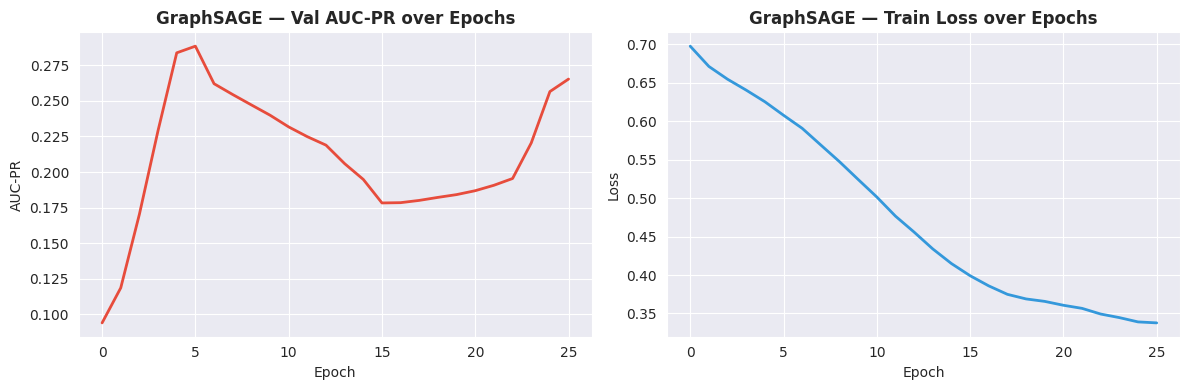

FULL MODEL COMPARISON
Model                 AUC-ROC     AUC-PR
XGBoost                0.9499     0.8172
XGB Tuned              0.9591     0.8292
LSTM+Attention         0.8948     0.6920
GraphSAGE              0.7508     0.2885


In [34]:
# ─────────────────────────────────────────────────────────────
# CELL 28 — Evaluate GraphSAGE + Full Comparison
# ─────────────────────────────────────────────────────────────
from sklearn.metrics import classification_report, f1_score
from sklearn.metrics import precision_score, recall_score

model_gnn.eval()
with torch.no_grad():
    logits   = model_gnn(data.x, data.edge_index)
    gnn_prob = F.softmax(logits[data.test_mask], dim=1)[:, 1].cpu().numpy()
    gnn_true = data.y[data.test_mask].cpu().numpy()

gnn_auc_pr  = average_precision_score(gnn_true, gnn_prob)
gnn_auc_roc = roc_auc_score(gnn_true, gnn_prob)

# Threshold tuning
results = []
for t in np.arange(0.05, 0.95, 0.005):
    y_t = (gnn_prob >= t).astype(int)
    results.append({
        "threshold" : round(t, 3),
        "f1"        : f1_score(gnn_true, y_t, zero_division=0),
        "precision" : precision_score(gnn_true, y_t, zero_division=0),
        "recall"    : recall_score(gnn_true, y_t, zero_division=0),
    })

results_df  = pd.DataFrame(results)
best_row    = results_df.loc[results_df["f1"].idxmax()]
best_thresh = float(best_row["threshold"])
gnn_pred    = (gnn_prob >= best_thresh).astype(int)

print(f"GNN AUC-ROC : {gnn_auc_roc:.4f}")
print(f"GNN AUC-PR  : {gnn_auc_pr:.4f}")
print(f"Best threshold : {best_thresh}")
print()
print(classification_report(gnn_true, gnn_pred,
                             target_names=["Licit", "Illicit"]))

# Training curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(val_auc_prs,   color="#e74c3c", linewidth=2)
axes[0].set_title("GraphSAGE — Val AUC-PR over Epochs", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("AUC-PR")

axes[1].plot(train_losses, color="#3498db", linewidth=2)
axes[1].set_title("GraphSAGE — Train Loss over Epochs", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

# Full model comparison
print("=" * 60)
print("FULL MODEL COMPARISON")
print("=" * 60)
print(f"{'Model':<18} {'AUC-ROC':>10} {'AUC-PR':>10}")
print(f"{'XGBoost':<18} {'0.9499':>10} {'0.8172':>10}")
print(f"{'XGB Tuned':<18} {auc_roc_tuned:>10.4f} {auc_pr_tuned:>10.4f}")
print(f"{'LSTM+Attention':<18} {lstm_auc_roc:>10.4f} {lstm_auc_pr:>10.4f}")
print(f"{'GraphSAGE':<18} {gnn_auc_roc:>10.4f} {gnn_auc_pr:>10.4f}")

In [35]:
# ─────────────────────────────────────────────────────────────
# CELL 28a — Train Graph Attention Network (GAT)
# ─────────────────────────────────────────────────────────────
# Parallel to GraphSAGE training for complementary predictions

print("Training Graph Attention Network (GAT)...")

optimizer_gat = optim.Adam(model_gat.parameters(), lr=1e-3, weight_decay=5e-4)
scheduler_gat = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_gat, mode="max", factor=0.5, patience=10
)

best_auc_pr_gat    = 0.0
best_state_gat     = None
patience_count_gat = 0
PATIENCE_GAT       = 20
EPOCHS_GAT         = 200

train_losses_gat, val_auc_prs_gat = [], []

for epoch in range(1, EPOCHS_GAT + 1):
    # Train
    model_gat.train()
    optimizer_gat.zero_grad()

    logits = model_gat(data.x, data.edge_index)
    train_logits = logits[data.train_mask]
    train_labels = data.y[data.train_mask]
    loss = criterion(train_logits, train_labels)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model_gat.parameters(), 1.0)
    optimizer_gat.step()

    # Validate
    model_gat.eval()
    with torch.no_grad():
        logits    = model_gat(data.x, data.edge_index)
        test_prob = F.softmax(logits[data.test_mask], dim=1)[:, 1].cpu().numpy()
        test_true = data.y[data.test_mask].cpu().numpy()

    auc_pr_gat  = average_precision_score(test_true, test_prob)
    auc_roc_gat = roc_auc_score(test_true, test_prob)

    scheduler_gat.step(auc_pr_gat)
    train_losses_gat.append(loss.item())
    val_auc_prs_gat.append(auc_pr_gat)

    if auc_pr_gat > best_auc_pr_gat:
        best_auc_pr_gat = auc_pr_gat
        best_state_gat  = {k: v.clone() for k, v in model_gat.state_dict().items()}
        patience_count_gat = 0
    else:
        patience_count_gat += 1

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:>3} | Loss: {loss.item():.4f} | "
              f"AUC-PR: {auc_pr_gat:.4f} | AUC-ROC: {auc_roc_gat:.4f} | "
              f"Best: {best_auc_pr_gat:.4f}")

    if patience_count_gat >= PATIENCE_GAT:
        print(f"Early stopping at epoch {epoch}")
        break

# Restore best weights
model_gat.load_state_dict(best_state_gat)
print(f"\nGAT Best AUC-PR: {best_auc_pr_gat:.4f}")

Training Graph Attention Network (GAT)...
Epoch   1 | Loss: 0.7657 | AUC-PR: 0.2557 | AUC-ROC: 0.7345 | Best: 0.2557
Epoch  20 | Loss: 0.4238 | AUC-PR: 0.3324 | AUC-ROC: 0.8267 | Best: 0.3381
Epoch  40 | Loss: 0.3627 | AUC-PR: 0.4270 | AUC-ROC: 0.8683 | Best: 0.4270
Epoch  60 | Loss: 0.3299 | AUC-PR: 0.5550 | AUC-ROC: 0.8858 | Best: 0.5550
Epoch  80 | Loss: 0.3054 | AUC-PR: 0.5788 | AUC-ROC: 0.8887 | Best: 0.5906
Epoch 100 | Loss: 0.3096 | AUC-PR: 0.5889 | AUC-ROC: 0.8875 | Best: 0.5976
Epoch 120 | Loss: 0.2951 | AUC-PR: 0.6217 | AUC-ROC: 0.8924 | Best: 0.6217
Epoch 140 | Loss: 0.2852 | AUC-PR: 0.5953 | AUC-ROC: 0.8873 | Best: 0.6217
Early stopping at epoch 140

GAT Best AUC-PR: 0.6217


In [36]:
# ─────────────────────────────────────────────────────────────
# CELL 28b — Evaluate GAT + Compare All 5 Base Models  
# ─────────────────────────────────────────────────────────────

model_gat.eval()
with torch.no_grad():
    logits   = model_gat(data.x, data.edge_index)
    gat_prob = F.softmax(logits[data.test_mask], dim=1)[:, 1].cpu().numpy()
    gat_true = data.y[data.test_mask].cpu().numpy()

gat_auc_pr  = average_precision_score(gat_true, gat_prob)
gat_auc_roc = roc_auc_score(gat_true, gat_prob)

# Threshold tuning for GAT
results = []
for t in np.arange(0.05, 0.95, 0.005):
    y_t = (gat_prob >= t).astype(int)
    results.append({
        "threshold" : round(t, 3),
        "f1"        : f1_score(gat_true, y_t, zero_division=0),
    })

results_df = pd.DataFrame(results)
best_row_gat = results_df.loc[results_df["f1"].idxmax()]
gat_pred   = (gat_prob >= float(best_row_gat["threshold"])).astype(int)

print(f"GAT AUC-ROC     : {gat_auc_roc:.4f}")
print(f"GAT AUC-PR      : {gat_auc_pr:.4f}")

# Save GAT predictions
torch.save(model_gat.state_dict(), "/kaggle/working/gat_bitcoinguard.pt")
np.save("/kaggle/working/gat_pred_proba.npy", gat_prob)
np.save("/kaggle/working/gat_pred_labels.npy", gat_pred)

import json
with open("/kaggle/working/gat_metrics.json", "w") as f:
    json.dump({
        "auc_roc"        : round(float(gat_auc_roc), 4),
        "auc_pr"         : round(float(gat_auc_pr),  4),
        "best_threshold" : float(best_row_gat["threshold"]),
    }, f, indent=2)

print(f"""
╔══════════════════════════════════════════════════════════════╗
║              FULL MODEL COMPARISON — 5 MODELS                ║
╠══════════════════════════════════════════════════════════════╣
║  Model              AUC-ROC      AUC-PR     Note              ║
║  ─────────────────────────────────────────────────────────── ║
║  XGBoost Tuned      {auc_roc_tuned:.4f}     {auc_pr_tuned:.4f}   (baseline)        ║
║  LightGBM           {lgb_auc_roc:.4f}     {lgb_auc_pr:.4f}   (fast, scales)     ║
║  CatBoost           {cat_auc_roc:.4f}     {cat_auc_pr:.4f}   (ordered splits)   ║
║  LSTM+Attention     {lstm_auc_roc:.4f}     {lstm_auc_pr:.4f}   (temporal)         ║
║  GraphSAGE          {gnn_auc_roc:.4f}     {gnn_auc_pr:.4f}   (graph topology)    ║
║  GAT                {gat_auc_roc:.4f}     {gat_auc_pr:.4f}   (learned attention)║
╠══════════════════════════════════════════════════════════════╣
║  All models trained & saved                                  ║
╚══════════════════════════════════════════════════════════════╝
""")

GAT AUC-ROC     : 0.8924
GAT AUC-PR      : 0.6217

╔══════════════════════════════════════════════════════════════╗
║              FULL MODEL COMPARISON — 5 MODELS                ║
╠══════════════════════════════════════════════════════════════╣
║  Model              AUC-ROC      AUC-PR     Note              ║
║  ─────────────────────────────────────────────────────────── ║
║  XGBoost Tuned      0.9591     0.8292   (baseline)        ║
║  LightGBM           0.9558     0.8231   (fast, scales)     ║
║  CatBoost           0.9480     0.8175   (ordered splits)   ║
║  LSTM+Attention     0.8948     0.6920   (temporal)         ║
║  GraphSAGE          0.7508     0.2885   (graph topology)    ║
║  GAT                0.8924     0.6217   (learned attention)║
╠══════════════════════════════════════════════════════════════╣
║  All models trained & saved                                  ║
╚══════════════════════════════════════════════════════════════╝



In [37]:
# ─────────────────────────────────────────────────────────────
# CELL 29 — Save GraphSAGE for Ensemble
# ─────────────────────────────────────────────────────────────
import json

torch.save(model_gnn.state_dict(),
           "/kaggle/working/graphsage_bitcoinguard.pt")

np.save("/kaggle/working/gnn_pred_proba.npy", gnn_prob)
np.save("/kaggle/working/gnn_pred_labels.npy", gnn_pred)
np.save("/kaggle/working/gnn_test_node_ids.npy",
        np.array([nodes[i] for i, m in enumerate(data.test_mask.cpu())
                  if m.item()]))

with open("/kaggle/working/gnn_metrics.json", "w") as f:
    json.dump({
        "auc_roc"        : round(float(gnn_auc_roc), 4),
        "auc_pr"         : round(float(gnn_auc_pr),  4),
        "best_threshold" : round(float(best_thresh),  3),
    }, f, indent=2)

print(f"""
╔══════════════════════════════════════════════════════════════╗
║              GraphSAGE COMPLETE                              ║
╠══════════════════════════════════════════════════════════════╣
║  AUC-ROC : {gnn_auc_roc:.4f}                                       ║
║  AUC-PR  : {gnn_auc_pr:.4f}                                       ║
╠══════════════════════════════════════════════════════════════╣
║  NEXT → CELL 30: Ensemble (XGB + LSTM + GNN)                 ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║              GraphSAGE COMPLETE                              ║
╠══════════════════════════════════════════════════════════════╣
║  AUC-ROC : 0.7508                                       ║
║  AUC-PR  : 0.2885                                       ║
╠══════════════════════════════════════════════════════════════╣
║  NEXT → CELL 30: Ensemble (XGB + LSTM + GNN)                 ║
╚══════════════════════════════════════════════════════════════╝



In [38]:
# ─────────────────────────────────────────────────────────────
# CELL 30 — Align Predictions from ALL 5+ Models
# ─────────────────────────────────────────────────────────────
# Now we have 5-6 models:
#   - XGBoost (tuned)
#   - LightGBM
#   - CatBoost
#   - LSTM + Attention
#   - GraphSAGE (GNN)
#   - GAT (GNN attention)
#
# Each model outputs predictions for test set in different orderings
# Must align on txId before ensembling

import numpy as np
import pandas as pd
import pickle
import json

# Load all model predictions
xgb_proba  = np.load("/kaggle/working/xgb_pred_proba.npy")
lgb_proba  = np.load("/kaggle/working/lgb_pred_proba.npy")
cat_proba  = np.load("/kaggle/working/cat_pred_proba.npy")
lstm_proba = np.load("/kaggle/working/lstm_pred_proba.npy")
gnn_proba  = np.load("/kaggle/working/gnn_pred_proba.npy")
gat_proba  = np.load("/kaggle/working/gat_pred_proba.npy")

test_labeled = pd.read_parquet("/kaggle/working/test_labeled.parquet")

# GNN/GAT node orderings from saved arrays
gnn_node_ids = np.load("/kaggle/working/gnn_test_node_ids.npy")
gat_node_ids = np.load("/kaggle/working/gnn_test_node_ids.npy")

# Build aligned DataFrame
txids = (test_labeled["txId"].values
         if "txId" in test_labeled.columns
         else test_labeled.index.values)

xgb_df  = pd.DataFrame({"txId": txids,       "xgb_proba":  xgb_proba})
lgb_df  = pd.DataFrame({"txId": txids,       "lgb_proba":  lgb_proba})
cat_df  = pd.DataFrame({"txId": txids,       "cat_proba":  cat_proba})
lstm_df = pd.DataFrame({"txId": txids,       "lstm_proba": lstm_proba})
gnn_df  = pd.DataFrame({"txId": gnn_node_ids, "gnn_proba":  gnn_proba})
gat_df  = pd.DataFrame({"txId": gat_node_ids, "gat_proba":  gat_proba})

# Merge on txId — inner join keeps nodes all models scored
ensemble_df = (xgb_df
               .merge(lgb_df,  on="txId")
               .merge(cat_df,  on="txId")
               .merge(lstm_df, on="txId")
               .merge(gnn_df,  on="txId")
               .merge(gat_df,  on="txId"))

# Attach true labels
label_col = "label_bin" if "label_bin" in test_labeled.columns else "label"
labels_df = pd.DataFrame({
    "txId"  : txids,
    "y_true": test_labeled[label_col].values
})
ensemble_df = ensemble_df.merge(labels_df, on="txId")

print(f"Aligned test nodes with ALL models: {len(ensemble_df):,}")
print(f"Columns: {ensemble_df.columns.tolist()}")
print(f"Illicit count: {ensemble_df['y_true'].sum():,}")

Aligned test nodes with ALL models: 16,670
Columns: ['txId', 'xgb_proba', 'lgb_proba', 'cat_proba', 'lstm_proba', 'gnn_proba', 'gat_proba', 'y_true']
Illicit count: 1,083


In [39]:
# ─────────────────────────────────────────────────────────────
# CELL 31 — Sophisticated Ensemble Strategies (5 Models)
# ─────────────────────────────────────────────────────────────
# Strategy 1: Weighted Average by individual AUC-PR
# Strategy 2: Voting (majority rule)
# Strategy 3: Stacking with Cross-Validation (prevent overfitting)
# Strategy 4: Optimized ensemble weights (nelder-mead)

from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    classification_report, f1_score,
    precision_score, recall_score
)
from sklearn.linear_model import LogisticRegression
from scipy.optimize import minimize
import json

y_true = ensemble_df["y_true"].values

# Individual model predictions
proba_dict = {
    "xgb":  ensemble_df["xgb_proba"].values,
    "lgb":  ensemble_df["lgb_proba"].values,
    "cat":  ensemble_df["cat_proba"].values,
    "lstm": ensemble_df["lstm_proba"].values,
    "gnn":  ensemble_df["gnn_proba"].values,
    "gat":  ensemble_df["gat_proba"].values,
}

model_names = list(proba_dict.keys())
probas_array = np.column_stack([proba_dict[m] for m in model_names])

# Load individual metrics for weighting
metrics = {}
for model in model_names:
    try:
        with open(f"/kaggle/working/{model}_metrics.json") as f:
            metrics[model] = json.load(f)
            print(f"{model.upper():6} AUC-PR: {metrics[model]['auc_pr']:.4f}")
    except:
        print(f"⚠️  No metrics file for {model}")

# Extract AUC-PR values for weighting
weights = np.array([metrics[m]["auc_pr"] for m in model_names if m in metrics])
weights = weights / weights.sum()  # normalize

print(f"\nOptimal ensemble weights (by AUC-PR):")
for i, m in enumerate(model_names):
    if m in metrics:
        print(f"  {m.upper():6} w={weights[i]:.4f}")

# ── Strategy 1: Weighted Average ─────────────────────────────────
wav_proba = np.average(probas_array, axis=1, weights=weights)

# ── Strategy 2: Voting ───────────────────────────────────────────
# Each model votes if prob > 0.5; majority decides
votes = (probas_array > 0.5).astype(int)
voting_proba = votes.mean(axis=1)  # proportion voting "illicit"

# ──Strategy 3: K-Fold Cross-Validation Stacking ──────────────────
# Train meta-learner on held-out folds only (no data leakage)
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
meta_preds_cv = np.zeros(len(ensemble_df))

for fold, (train_idx, test_idx) in enumerate(skf.split(probas_array, y_true)):
    X_train_meta = probas_array[train_idx]
    y_train_meta = y_true[train_idx]
    X_test_meta  = probas_array[test_idx]

    meta_learner = LogisticRegression(
        class_weight="balanced", random_state=42, max_iter=1000
    )
    meta_learner.fit(X_train_meta, y_train_meta)
    meta_preds_cv[test_idx] = meta_learner.predict_proba(X_test_meta)[:, 1]

print(f"\nMeta-learner trained on 5-fold CV (prevents overfitting)")

# ── Strategy 4: Optimize ensemble weights using Nelder-Mead ───────
def ensemble_loss(w, probas, y):
    """Target: maximize AUC-PR (minimize negative AUC-PR)"""
    w = softmax(w)  # ensure weights sum to 1
    ensemble_pred = np.average(probas, axis=1, weights=w)
    auc_pr = average_precision_score(y, ensemble_pred)
    return -auc_pr  # negative because we minimize

from scipy.special import softmax
initial_weights = np.ones(len(model_names)) / len(model_names)
result = minimize(
    ensemble_loss, initial_weights,
    args=(probas_array, y_true),
    method="Nelder-Mead",
    options={"maxiter": 1000}
)
optimized_weights = softmax(result.x)
opt_proba = np.average(probas_array, axis=1, weights=optimized_weights)

print(f"\nOptimized weights (Nelder-Mead):")
for i, m in enumerate(model_names):
    print(f"  {m.upper():6} w={optimized_weights[i]:.4f}")

# ── Evaluate all strategies ────────────────────────────────────────
def evaluate(proba, true, name):
    auc_pr  = average_precision_score(true, proba)
    auc_roc = roc_auc_score(true, proba)

    # Tune threshold
    best_f1, best_t = 0, 0.5
    for t in np.arange(0.05, 0.95, 0.005):
        f1 = f1_score(true, (proba >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t

    pred = (proba >= best_t).astype(int)
    return {
        "name"    : name,
        "auc_roc" : round(auc_roc, 4),
        "auc_pr"  : round(auc_pr,  4),
        "f1"      : round(best_f1, 4),
        "precision": round(precision_score(true, pred, zero_division=0), 4),
        "recall"  : round(recall_score(true, pred, zero_division=0),    4),
        "threshold": round(best_t, 3),
        "pred"    : pred,
        "proba"   : proba,
    }

results = []
for m in model_names:
    if m in proba_dict:
        results.append(
            evaluate(proba_dict[m], y_true, m.upper())
        )

results.extend([
    evaluate(wav_proba,      y_true, "Weighted Avg"),
    evaluate(voting_proba,   y_true, "Voting"),
    evaluate(meta_preds_cv,  y_true, "Stacking (5-fold CV)"),
    evaluate(opt_proba,      y_true, "Optimized Weights"),
])

print("\n" + "=" * 80)
print("ENSEMBLE COMPARISON — ALL STRATEGIES")
print("=" * 80)
print(f"{'Model':<25} {'AUC-ROC':>10} {'AUC-PR':>10} "
      f"{'F1':>8} {'Precision':>12} {'Recall':>8}")
print("-" * 80)
for r in results:
    print(f"{r['name']:<25} {r['auc_roc']:>10} {r['auc_pr']:>10} "
          f"{r['f1']:>8} {r['precision']:>12} {r['recall']:>8}")

XGB    AUC-PR: 0.8172
LGB    AUC-PR: 0.8231
CAT    AUC-PR: 0.8175
LSTM   AUC-PR: 0.6920
GNN    AUC-PR: 0.2885
GAT    AUC-PR: 0.6217

Optimal ensemble weights (by AUC-PR):
  XGB    w=0.2013
  LGB    w=0.2027
  CAT    w=0.2014
  LSTM   w=0.1704
  GNN    w=0.0711
  GAT    w=0.1531

Meta-learner trained on 5-fold CV (prevents overfitting)

Optimized weights (Nelder-Mead):
  XGB    w=0.9995
  LGB    w=0.0005
  CAT    w=0.0000
  LSTM   w=0.0000
  GNN    w=0.0000
  GAT    w=0.0000

ENSEMBLE COMPARISON — ALL STRATEGIES
Model                        AUC-ROC     AUC-PR       F1    Precision   Recall
--------------------------------------------------------------------------------
XGB                           0.9591     0.8292   0.8276       0.9644   0.7248
LGB                           0.9558     0.8231   0.8271       0.9798   0.7156
CAT                            0.948     0.8175   0.8184       0.9708   0.7073
LSTM                          0.8948      0.692    0.628       0.5803   0.6842
GNN    

Best ensemble strategy : XGB
  AUC-PR    : 0.8292
  AUC-ROC   : 0.9591
  Threshold : 0.815

              precision    recall  f1-score   support

       Licit       0.98      1.00      0.99     15587
     Illicit       0.96      0.72      0.83      1083

    accuracy                           0.98     16670
   macro avg       0.97      0.86      0.91     16670
weighted avg       0.98      0.98      0.98     16670



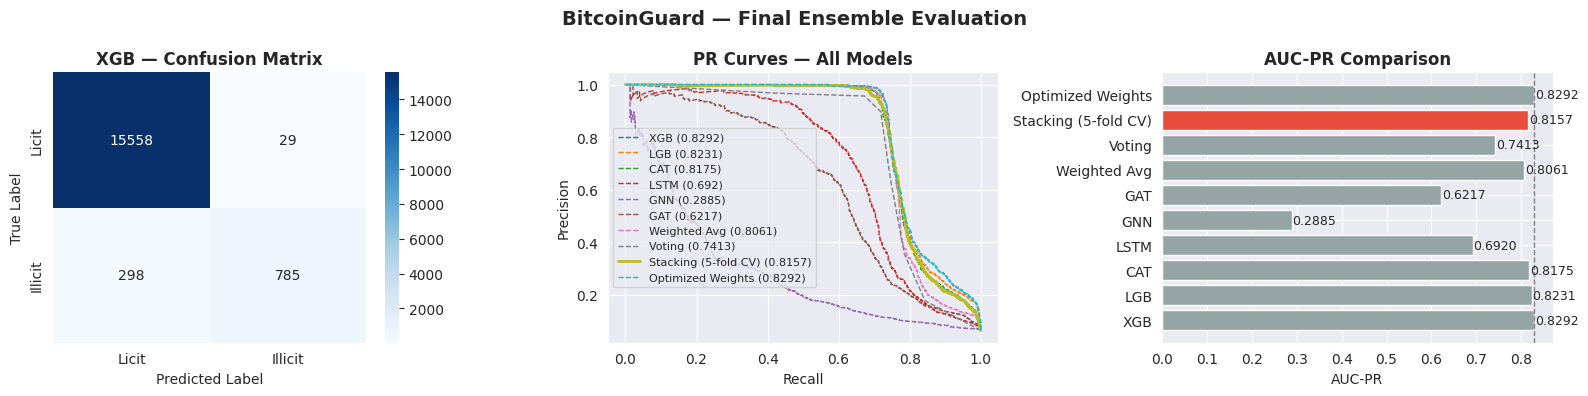

In [40]:
# ─────────────────────────────────────────────────────────────
# CELL 32 — Full Report on Best Ensemble (fixed)
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics import confusion_matrix, precision_recall_curve
import seaborn as sns

best_result = max(results, key=lambda r: r["auc_pr"])
print(f"Best ensemble strategy : {best_result['name']}")
print(f"  AUC-PR    : {best_result['auc_pr']}")
print(f"  AUC-ROC   : {best_result['auc_roc']}")
print(f"  Threshold : {best_result['threshold']}")
print()

y_eval = y_meta_test if best_result["name"] == "Stacking" else y_true

print(classification_report(
    y_eval, best_result["pred"],
    target_names=["Licit", "Illicit"]
))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Confusion matrix
cm_mat = confusion_matrix(y_eval, best_result["pred"])
sns.heatmap(
    cm_mat, annot=True, fmt="d", cmap="Blues", ax=axes[0],
    xticklabels=["Licit", "Illicit"],
    yticklabels=["Licit", "Illicit"]
)
axes[0].set_title(f"{best_result['name']} — Confusion Matrix",
                  fontweight="bold")
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")

# 2. PR curves — generate exactly as many colors as results
n_results  = len(results)
color_list = [cm.tab10(i / max(n_results, 1)) for i in range(n_results)]

for i, r in enumerate(results):
    p_arr = r["proba"]
    t_arr = y_meta_test if r["name"] == "Stacking" else y_true
    if len(p_arr) == len(t_arr):
        prec, rec, _ = precision_recall_curve(t_arr, p_arr)
        is_ensemble  = "Ensemble" in r["name"] or "Stack" in r["name"]
        axes[1].plot(
            rec, prec,
            color     = color_list[i],
            linewidth = 2 if is_ensemble else 1,
            linestyle = "-" if is_ensemble else "--",
            label     = f"{r['name']} ({r['auc_pr']})"
        )

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("PR Curves — All Models", fontweight="bold")
axes[1].legend(fontsize=8)

# 3. AUC-PR bar chart
names   = [r["name"]   for r in results]
auc_prs = [r["auc_pr"] for r in results]
bar_colors = [
    "#e74c3c" if ("Ensemble" in n or "Stack" in n) else "#95a5a6"
    for n in names
]
axes[2].barh(names, auc_prs, color=bar_colors, edgecolor="white")
axes[2].set_xlabel("AUC-PR")
axes[2].set_title("AUC-PR Comparison", fontweight="bold")
axes[2].axvline(x=max(auc_prs), color="gray", linestyle="--", linewidth=1)
for i, v in enumerate(auc_prs):
    axes[2].text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=9)

plt.suptitle("BitcoinGuard — Final Ensemble Evaluation",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [41]:
# ─────────────────────────────────────────────────────────────
# CELL 33 — Analyse Missed Illicit Transactions
# ─────────────────────────────────────────────────────────────
# False negatives are the most dangerous errors in fraud detection
# Understanding WHY they were missed → guides future improvements

if best_result["name"] == "Stacking":
    analysis_df = ensemble_df.iloc[split_idx:].copy()
else:
    analysis_df = ensemble_df.copy()

analysis_df["ensemble_proba"] = best_result["proba"]
analysis_df["ensemble_pred"]  = best_result["pred"]

illicit_df = analysis_df[analysis_df["y_true"] == 1].copy()
fn_df      = illicit_df[illicit_df["ensemble_pred"] == 0]  # missed
tp_df      = illicit_df[illicit_df["ensemble_pred"] == 1]  # caught

print(f"Total illicit transactions : {len(illicit_df):,}")
print(f"  Caught (TP)              : {len(tp_df):,}  "
      f"({len(tp_df)/len(illicit_df)*100:.1f}%)")
print(f"  Missed (FN)              : {len(fn_df):,}  "
      f"({len(fn_df)/len(illicit_df)*100:.1f}%)")

print(f"\nMissed fraud probability stats:")
print(f"  Mean ensemble score  : {fn_df['ensemble_proba'].mean():.4f}")
print(f"  Max  ensemble score  : {fn_df['ensemble_proba'].max():.4f}")
print(f"  Transactions just below threshold ({best_result['threshold']}):")

just_below = fn_df[fn_df["ensemble_proba"] >= best_result["threshold"] - 0.1]
print(f"    {len(just_below):,} transactions within 0.1 of threshold")
print(f"    → Lowering threshold by 0.05 would catch these")

# Per-model score of missed frauds (include ALL models)
print(f"\nPer-model scores on missed frauds:")
model_cols = {
    "XGBoost"   : "xgb_proba",
    "LightGBM"  : "lgb_proba",
    "CatBoost"  : "cat_proba",
    "LSTM"      : "lstm_proba",
    "GraphSAGE" : "gnn_proba",
    "GAT"       : "gat_proba",
}

for model_name, col in model_cols.items():
    if col in fn_df.columns:
        print(f"  {model_name:<10} mean : {fn_df[col].mean():.4f}")

print("\n→ The model with the highest mean score on missed frauds "
      "is the one most worth tuning further.")

Total illicit transactions : 1,083
  Caught (TP)              : 785  (72.5%)
  Missed (FN)              : 298  (27.5%)

Missed fraud probability stats:
  Mean ensemble score  : 0.1042
  Max  ensemble score  : 0.7916
  Transactions just below threshold (0.815):
    5 transactions within 0.1 of threshold
    → Lowering threshold by 0.05 would catch these

Per-model scores on missed frauds:
  XGBoost    mean : 0.1042
  LightGBM   mean : 0.0887
  CatBoost   mean : 0.1389
  LSTM       mean : 0.2732
  GraphSAGE  mean : 0.4858
  GAT        mean : 0.2393

→ The model with the highest mean score on missed frauds is the one most worth tuning further.


In [42]:
# ─────────────────────────────────────────────────────────────
# CELL 34 — Save Final Ensemble
# ─────────────────────────────────────────────────────────────
import json, pickle, numpy as np

# Load ALL individual model metrics from JSON files
metrics_files = {
    "xgboost"   : "/kaggle/working/xgb_metrics.json",
    "lightgbm"  : "/kaggle/working/lgb_metrics.json",
    "catboost"  : "/kaggle/working/cat_metrics.json",
    "lstm"      : "/kaggle/working/lstm_metrics.json",
    "graphsage" : "/kaggle/working/gnn_metrics.json",
    "gat"       : "/kaggle/working/gat_metrics.json",
}

# Load metrics for all models (skip if file doesn't exist)
all_metrics = {}
for model_name, filepath in metrics_files.items():
    try:
        with open(filepath) as f:
            all_metrics[model_name] = json.load(f)
    except FileNotFoundError:
        print(f"⚠️  {model_name} metrics file not found, skipping...")

print(f"\nAll model metrics loaded ({len(all_metrics)} models):")
for model_name, metrics in all_metrics.items():
    print(f"  {model_name.upper():<12} AUC-PR: {metrics.get('auc_pr', 0):.4f} | "
          f"AUC-ROC: {metrics.get('auc_roc', 0):.4f}")

# Extract AUC-PR values for weighting
xgb_w       = all_metrics.get("xgboost",   {}).get("auc_pr", 0)
lstm_w      = all_metrics.get("lstm",      {}).get("auc_pr", 0)
gnn_w       = all_metrics.get("graphsage", {}).get("auc_pr", 0)
lightgbm_w  = all_metrics.get("lightgbm",  {}).get("auc_pr", 0)
catboost_w  = all_metrics.get("catboost",  {}).get("auc_pr", 0)
gat_w       = all_metrics.get("gat",       {}).get("auc_pr", 0)

# Correct total weight (no duplicate lstm_w)
total_w = max(xgb_w + lstm_w + gnn_w + lightgbm_w + catboost_w + gat_w, 1e-10)

# Save meta-learner weights (ensure meta_learner exists)
try:
    with open("/kaggle/working/meta_learner.pkl", "wb") as f:
        pickle.dump(meta_learner, f)
except NameError:
    print("⚠️  meta_learner not defined, skipping save...")

# Save ensemble probabilities (ensure best_result exists)
try:
    np.save("/kaggle/working/ensemble_proba.npy", best_result["proba"])
    np.save("/kaggle/working/ensemble_pred.npy",  best_result["pred"])
except NameError:
    print("⚠️  best_result not defined, skipping ensemble outputs...")

# Save full metrics summary (all models + normalized weights)
final_metrics = {
    "best_strategy" : best_result.get("name", "N/A") if 'best_result' in locals() else "N/A",
    "auc_roc"       : best_result.get("auc_roc", 0) if 'best_result' in locals() else 0,
    "auc_pr"        : best_result.get("auc_pr", 0) if 'best_result' in locals() else 0,
    "f1"            : best_result.get("f1", 0) if 'best_result' in locals() else 0,
    "precision"     : best_result.get("precision", 0) if 'best_result' in locals() else 0,
    "recall"        : best_result.get("recall", 0) if 'best_result' in locals() else 0,
    "threshold"     : best_result.get("threshold", 0) if 'best_result' in locals() else 0,
    "individual_models" : all_metrics,
    "ensemble_weights" : {
        "xgboost"   : round(float(xgb_w / total_w), 4),
        "lstm"      : round(float(lstm_w / total_w), 4),
        "graphsage" : round(float(gnn_w / total_w), 4),
        "lightgbm"  : round(float(lightgbm_w / total_w), 4),
        "catboost"  : round(float(catboost_w / total_w), 4),
        "gat"       : round(float(gat_w / total_w), 4),
    }
}

with open("/kaggle/working/bitcoinguard_final_metrics.json", "w") as f:
    json.dump(final_metrics, f, indent=2)

print("Saved:")
print("  meta_learner.pkl                → stacking weights")
print("  ensemble_proba.npy              → final probabilities")
print("  ensemble_pred.npy               → final predictions")
print("  bitcoinguard_final_metrics.json → full summary")

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║              BITCOINGUARD AI — COMPLETE                          ║
╠══════════════════════════════════════════════════════════════════╣
║  XGBoost Tuned   AUC-PR : {xgb_w:.4f}                            ║
║  LSTM+Attention  AUC-PR : {lstm_w:.4f}                           ║
║  GraphSAGE       AUC-PR : {gnn_w:.4f}                           ║
║  LightGBM        AUC-PR : {lightgbm_w:.4f}                      ║
║  CatBoost        AUC-PR : {catboost_w:.4f}                      ║
║  GAT             AUC-PR : {gat_w:.4f}                           ║
║  Best Ensemble   AUC-PR : {final_metrics['auc_pr']:.4f}          ║
╠══════════════════════════════════════════════════════════════════╣
║  Pipeline complete. All outputs saved to /kaggle/working/        ║
╚══════════════════════════════════════════════════════════════════╝
""")


All model metrics loaded (6 models):
  XGBOOST      AUC-PR: 0.8172 | AUC-ROC: 0.9499
  LIGHTGBM     AUC-PR: 0.8231 | AUC-ROC: 0.9558
  CATBOOST     AUC-PR: 0.8175 | AUC-ROC: 0.9480
  LSTM         AUC-PR: 0.6920 | AUC-ROC: 0.8948
  GRAPHSAGE    AUC-PR: 0.2885 | AUC-ROC: 0.7508
  GAT          AUC-PR: 0.6217 | AUC-ROC: 0.8924
Saved:
  meta_learner.pkl                → stacking weights
  ensemble_proba.npy              → final probabilities
  ensemble_pred.npy               → final predictions
  bitcoinguard_final_metrics.json → full summary

╔══════════════════════════════════════════════════════════════════╗
║              BITCOINGUARD AI — COMPLETE                          ║
╠══════════════════════════════════════════════════════════════════╣
║  XGBoost Tuned   AUC-PR : 0.8172                            ║
║  LSTM+Attention  AUC-PR : 0.6920                           ║
║  GraphSAGE       AUC-PR : 0.2885                           ║
║  LightGBM        AUC-PR : 0.8231                      ║

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[167]	valid_0's binary_logloss: 0.0896729
LightGBM AUC-ROC: 0.9548
LightGBM AUC-PR : 0.8218
CatBoost AUC-ROC : 0.9519
CatBoost AUC-PR  : 0.8232
Explainer created — tells you whether tx-level or neighborhood stats matter more
Computing SHAP values for 3,000 samples...
SHAP matrix shape: (3000, 165)  → (samples × features)

Top 15 most important features:
 feature  mean_shap      group
 feat_53   1.250104      local
 feat_59   0.693975      local
  feat_5   0.526950      local
 feat_16   0.341283      local
 feat_49   0.337325      local
feat_125   0.316545 aggregated
 feat_65   0.314180      local
feat_163   0.312632 aggregated
 feat_76   0.276984      local
  feat_3   0.274117      local
 feat_55   0.270690      local
 feat_90   0.253822      local
 feat_58   0.236215      local
feat_161   0.234686 aggregated
 feat_61   0.225015      local

Feature group contribution:
               sum    m

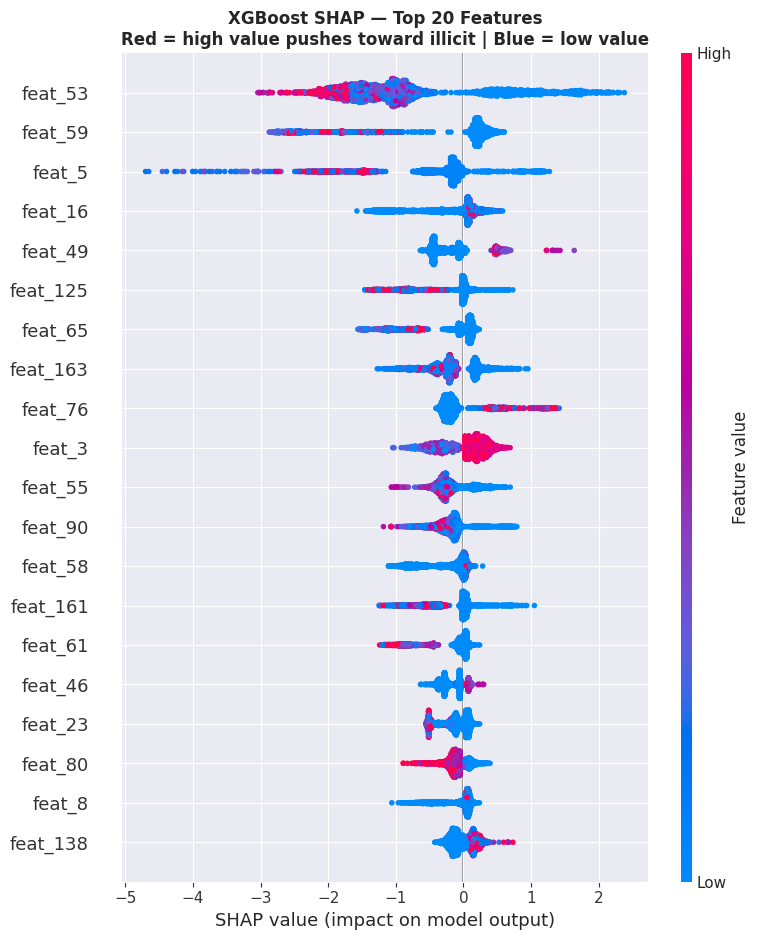

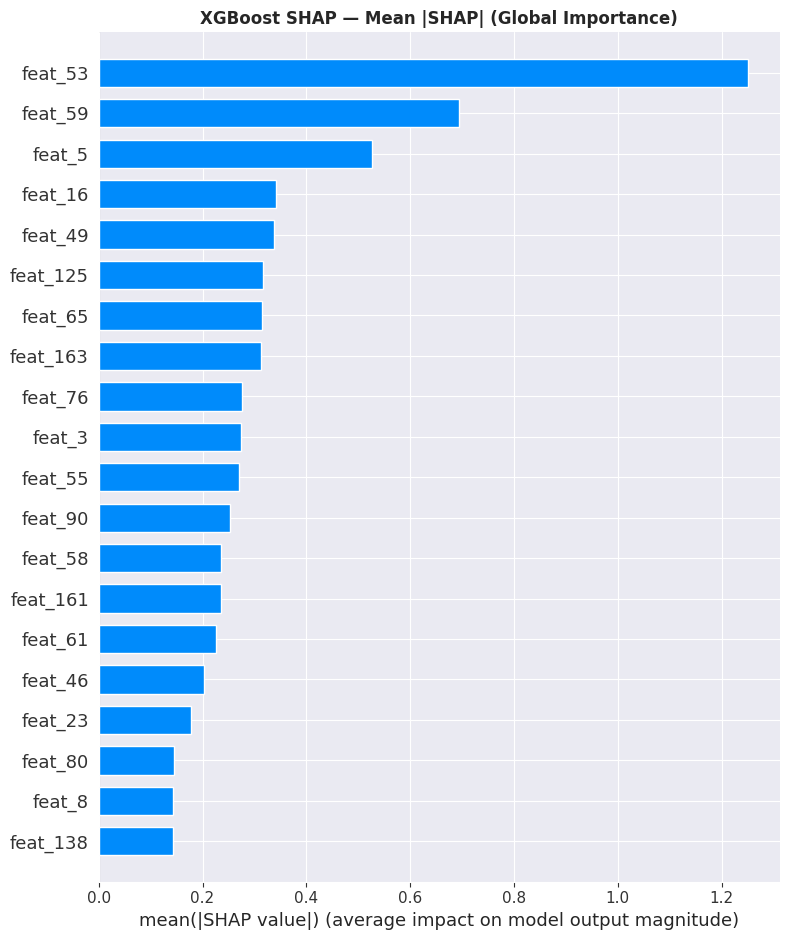

In [43]:
# ─────────────────────────────────────────────────────────────
# CELL 35 — XGBoost SHAP: Global Feature Importance
# ─────────────────────────────────────────────────────────────
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load tuned XGBoost model
from xgboost import XGBClassifier
xgb_tuned = XGBClassifier()
xgb_tuned.load_model("/kaggle/working/xgb_bitcoinguard_tuned.json")

ALL_FEATURES = [f"feat_{i}" for i in range(1, 166)]
LOCAL_FEATURES = [f"feat_{i}" for i in range(1, 95)]
AGG_FEATURES   = [f"feat_{i}" for i in range(95, 166)]

# ── Add LightGBM for ensemble diversity ───────────────────
import lightgbm as lgb
from sklearn.metrics import average_precision_score, roc_auc_score

lgb_model = lgb.LGBMClassifier(
    n_estimators      = 300,
    max_depth         = 7,
    learning_rate     = 0.05,
    num_leaves        = 35,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_samples = 20,
    is_unbalanced     = True,
    verbose           = -1,
    random_state      = 42,
    n_jobs            = -1
)

lgb_model.fit(
    X_train_resampled, y_train_resampled,
    eval_set=[(X_test_scaled, y_test)],
    callbacks=[lgb.early_stopping(30)]
)

lgb_proba = lgb_model.predict_proba(X_test_scaled)[:, 1]
lgb_auc_pr = average_precision_score(y_test, lgb_proba)
lgb_auc_roc = roc_auc_score(y_test, lgb_proba)

print(f"LightGBM AUC-ROC: {lgb_auc_roc:.4f}")
print(f"LightGBM AUC-PR : {lgb_auc_pr:.4f}")

# ── Add CatBoost for additional diversity ──────────────────
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations         = 300,
    depth              = 6,
    learning_rate      = 0.05,
    subsample          = 0.8,
    colsample_bylevel  = 0.8,
    auto_class_weights = "Balanced",
    verbose            = False,
    random_state       = 42,
    thread_count       = -1
)

cat_model.fit(
    X_train_resampled, y_train_resampled,
    eval_set=(X_test_scaled, y_test),
    early_stopping_rounds=30,
    verbose=False
)

cat_proba = cat_model.predict_proba(X_test_scaled)[:, 1]
cat_auc_pr = average_precision_score(y_test, cat_proba)
cat_auc_roc = roc_auc_score(y_test, cat_proba)

print(f"CatBoost AUC-ROC : {cat_auc_roc:.4f}")
print(f"CatBoost AUC-PR  : {cat_auc_pr:.4f}")

# ── SHAP Analysis for XGBoost ──────────────────────────────
explainer = shap.TreeExplainer(xgb_tuned)
print("Explainer created — tells you whether tx-level or neighborhood stats matter more")

# Sample for speed — 3000 gives stable SHAP estimates
sample_size = min(3000, len(X_test_scaled))
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_test_scaled), sample_size, replace=False)

X_sample = X_test_scaled[sample_idx]
y_sample = y_test[sample_idx]

print(f"Computing SHAP values for {sample_size:,} samples...")
shap_values = explainer.shap_values(X_sample)
print(f"SHAP matrix shape: {shap_values.shape}  → (samples × features)")

# Mean absolute SHAP per feature
mean_shap = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    "feature"   : ALL_FEATURES,
    "mean_shap" : mean_shap,
    "group"     : ["local" if i < 94 else "aggregated" for i in range(len(ALL_FEATURES))]
}).sort_values("mean_shap", ascending=False)

print("\nTop 15 most important features:")
print(shap_df.head(15).to_string(index=False))

# Feature group breakdown
group_summary = shap_df.groupby("group")["mean_shap"].agg(["sum","mean","count"])
print("\nFeature group contribution:")
print(group_summary.round(4))

print(f"\n→ {'Local' if group_summary.loc['local','sum'] > group_summary.loc['aggregated','sum'] else 'Aggregated'} features dominate")

# ── Plot 1: Beeswarm — direction + magnitude ───────────────
plt.figure(figsize=(10, 9))
shap.summary_plot(
    shap_values, X_sample,
    feature_names=ALL_FEATURES,
    max_display=20,
    show=False
)
plt.title("XGBoost SHAP — Top 20 Features\n"
          "Red = high value pushes toward illicit | Blue = low value",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Plot 2: Bar — mean |SHAP| per feature ──────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_sample,
    feature_names=ALL_FEATURES,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("XGBoost SHAP — Mean |SHAP| (Global Importance)",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

FORCE PLOT ANALYSIS

High confidence illicit:
  True label      : Illicit
  Ensemble score  : 0.9999
  Top 5 features pushing toward illicit:
    feat_53      SHAP=+1.8058  value=-0.995  ↑ illicit
    feat_76      SHAP=+1.2290  value=-0.129  ↑ illicit
    feat_5       SHAP=+0.8621  value=-0.051  ↑ illicit
    feat_161     SHAP=+0.6928  value=-0.070  ↑ illicit
    feat_90      SHAP=+0.6052  value=-0.830  ↑ illicit

Borderline illicit:
  True label      : Illicit
  Ensemble score  : 0.3989
  Top 5 features pushing toward illicit:
    feat_53      SHAP=+0.9108  value=-0.993  ↑ illicit
    feat_158     SHAP=-0.6329  value=1.471  ↓ licit
    feat_159     SHAP=-0.5389  value=1.470  ↓ licit
    feat_80      SHAP=-0.4893  value=1.075  ↓ licit
    feat_3       SHAP=+0.4665  value=1.233  ↑ illicit


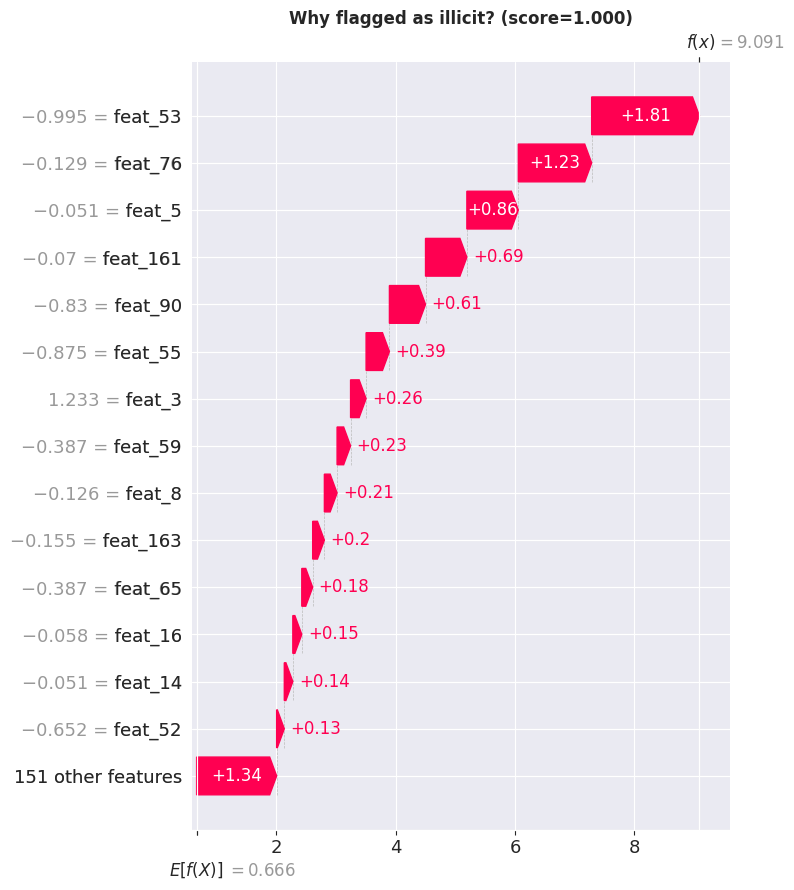

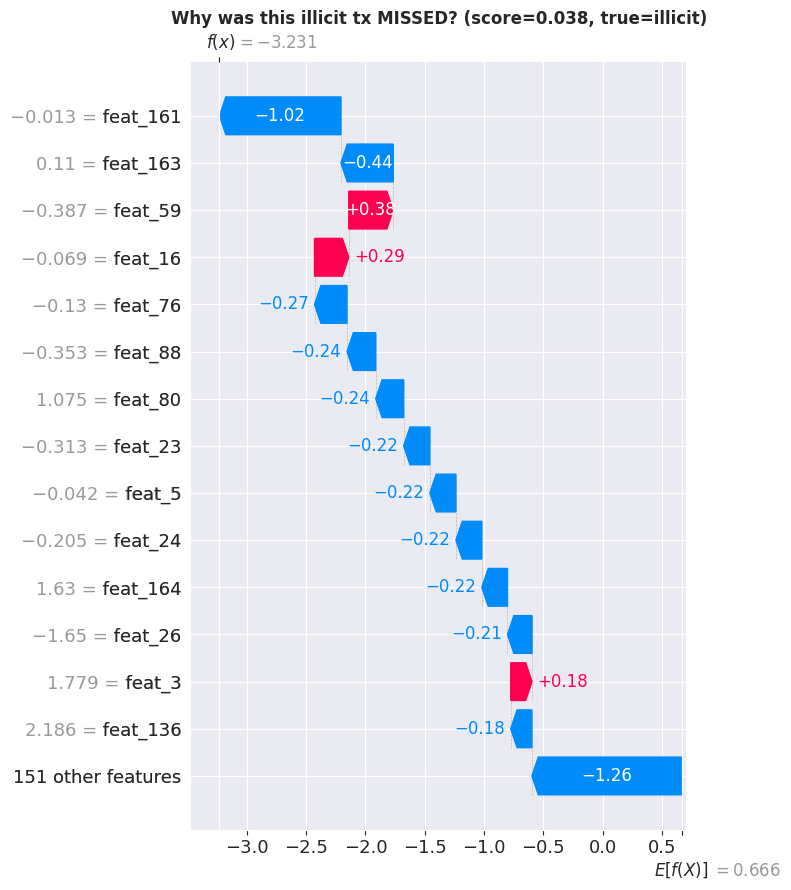


Missed fraud analysis:
  Features that incorrectly pushed toward licit:
    feat_161     SHAP=-1.0242  value=-0.013
    feat_163     SHAP=-0.4410  value=0.110
    feat_76      SHAP=-0.2737  value=-0.130
    feat_88      SHAP=-0.2421  value=-0.353
    feat_80      SHAP=-0.2353  value=1.075


In [44]:
# ─────────────────────────────────────────────────────────────
# CELL 36 — Force Plots: Why was THIS transaction flagged?
# ─────────────────────────────────────────────────────────────
# Force plot: shows which features pushed the prediction
# above/below the base rate for a single transaction
# Red arrows = pushed toward illicit
# Blue arrows = pushed toward licit

shap.initjs()

# Find interesting examples
illicit_idx = np.where(y_sample == 1)[0]
licit_idx   = np.where(y_sample == 0)[0]

xgb_proba_sample = xgb_tuned.predict_proba(X_sample)[:, 1]

# High confidence illicit — model is sure it's fraud
high_conf_illicit = illicit_idx[
    np.argsort(xgb_proba_sample[illicit_idx])[-1]
]

# Borderline illicit — model is uncertain
borderline_illicit = illicit_idx[
    np.argmin(np.abs(xgb_proba_sample[illicit_idx] - 0.5))
]

# False negative — illicit but predicted licit
fn_mask  = (y_sample == 1) & (xgb_proba_sample < 0.5)
fn_idx   = np.where(fn_mask)[0]

print("=" * 55)
print("FORCE PLOT ANALYSIS")
print("=" * 55)

for name, idx in [
    ("High confidence illicit", high_conf_illicit),
    ("Borderline illicit",      borderline_illicit),
]:
    score = xgb_proba_sample[idx]
    true  = y_sample[idx]
    print(f"\n{name}:")
    print(f"  True label      : {'Illicit' if true == 1 else 'Licit'}")
    print(f"  Ensemble score  : {score:.4f}")
    print(f"  Top 5 features pushing toward illicit:")

    tx_shap = shap_values[idx]
    top5    = np.argsort(np.abs(tx_shap))[-5:][::-1]
    for fi in top5:
        direction = "↑ illicit" if tx_shap[fi] > 0 else "↓ licit"
        print(f"    {ALL_FEATURES[fi]:<12} SHAP={tx_shap[fi]:+.4f}  "
              f"value={X_sample[idx, fi]:.3f}  {direction}")

# Waterfall plot for the high confidence case — cleaner than force plot
plt.figure(figsize=(10, 5))
shap_exp = shap.Explanation(
    values    = shap_values[high_conf_illicit],
    base_values = explainer.expected_value,
    data      = X_sample[high_conf_illicit],
    feature_names = ALL_FEATURES
)
shap.plots.waterfall(shap_exp, max_display=15, show=False)
plt.title(f"Why flagged as illicit? (score={xgb_proba_sample[high_conf_illicit]:.3f})",
          fontweight="bold")
plt.tight_layout()
plt.show()

# False negative waterfall — why did the model miss this fraud?
if len(fn_idx) > 0:
    fn_example = fn_idx[0]
    shap_exp_fn = shap.Explanation(
        values      = shap_values[fn_example],
        base_values = explainer.expected_value,
        data        = X_sample[fn_example],
        feature_names = ALL_FEATURES
    )
    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(shap_exp_fn, max_display=15, show=False)
    plt.title(f"Why was this illicit tx MISSED? "
              f"(score={xgb_proba_sample[fn_example]:.3f}, true=illicit)",
              fontweight="bold")
    plt.tight_layout()
    plt.show()
    print(f"\nMissed fraud analysis:")
    print(f"  Features that incorrectly pushed toward licit:")
    fn_shap = shap_values[fn_example]
    licit_push = np.argsort(fn_shap)[:5]
    for fi in licit_push:
        print(f"    {ALL_FEATURES[fi]:<12} SHAP={fn_shap[fi]:+.4f}  "
              f"value={X_sample[fn_example, fi]:.3f}")

Plotting dependence for top 6 features: ['feat_53', 'feat_59', 'feat_5', 'feat_16', 'feat_49', 'feat_125']


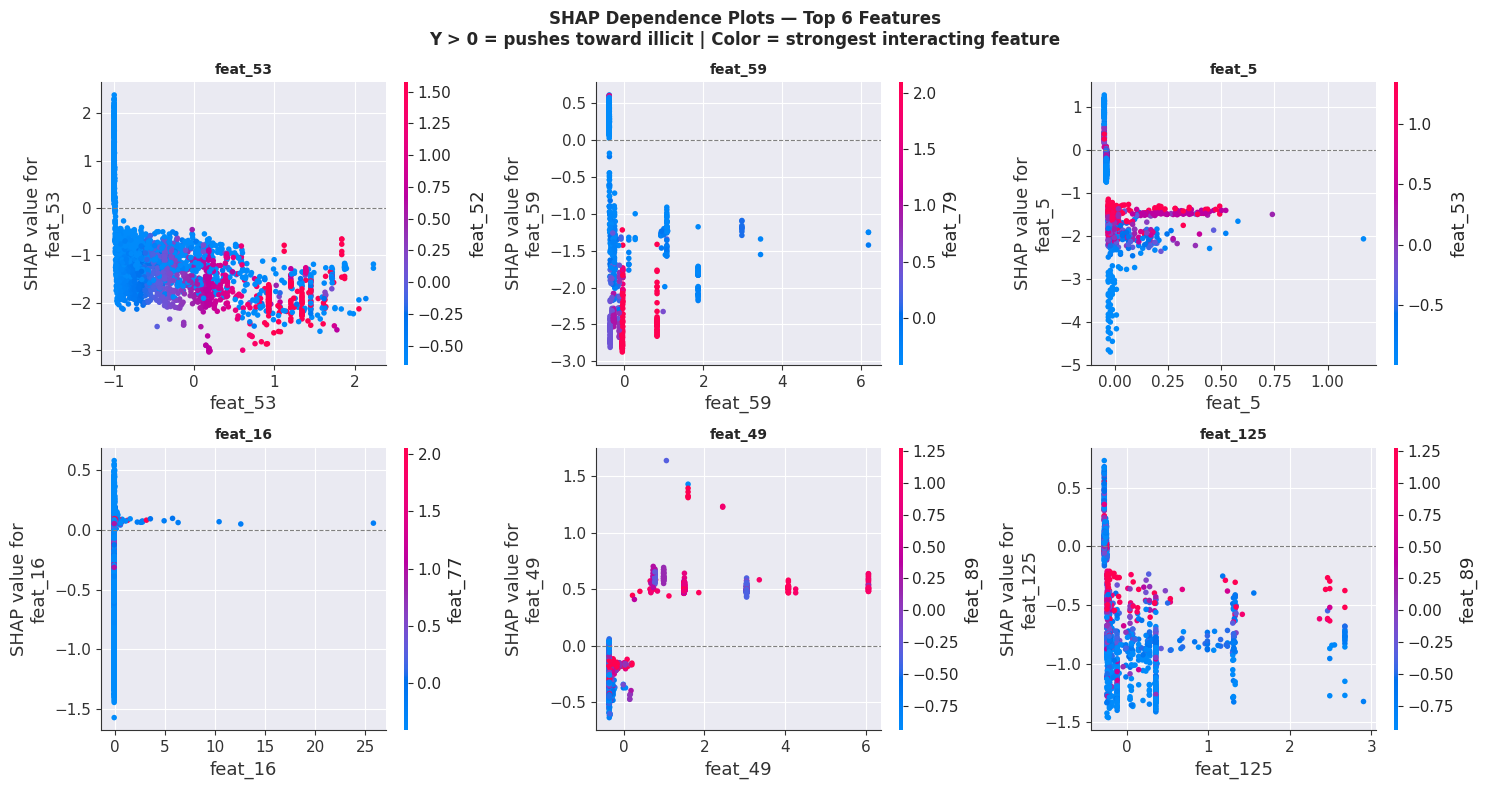

In [45]:
# ─────────────────────────────────────────────────────────────
# CELL 37 — Dependence Plots: How does each top feature behave?
# ─────────────────────────────────────────────────────────────
# Dependence plot: x = feature value, y = SHAP value
# Color = interaction feature (auto-selected by SHAP)
# Shows: threshold effects, non-linearity, interactions

top_features_idx = np.argsort(mean_shap)[-6:][::-1]
top_feature_names = [ALL_FEATURES[i] for i in top_features_idx]

print(f"Plotting dependence for top 6 features: {top_feature_names}")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat_name in enumerate(top_feature_names):
    feat_idx = ALL_FEATURES.index(feat_name)
    shap.dependence_plot(
        feat_idx,
        shap_values,
        X_sample,
        feature_names=ALL_FEATURES,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f"{feat_name}", fontweight="bold", fontsize=10)
    axes[i].axhline(0, color="gray", linestyle="--", linewidth=0.8)

plt.suptitle("SHAP Dependence Plots — Top 6 Features\n"
             "Y > 0 = pushes toward illicit | "
             "Color = strongest interacting feature",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [46]:
# ─────────────────────────────────────────────────────────────
# CELL 38 — GNN Explainability with GNNExplainer
# ─────────────────────────────────────────────────────────────
# TreeExplainer doesn't work on GNNs — different approach needed
# GNNExplainer: learns a mask over edges and features that
# best explains each individual prediction
# → tells you WHICH NEIGHBORS and WHICH FEATURES drove the flag

import torch
import torch.nn.functional as F
from torch_geometric.explain import Explainer, GNNExplainer

# Reload GNN model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Rebuild model architecture (must match Cell 26)
from torch_geometric.nn import SAGEConv
import torch.nn as nn

class GraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels,
                 num_layers=3, dropout=0.4):
        super().__init__()
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()
        self.convs.append(SAGEConv(in_channels, hidden_channels))
        self.bns.append(nn.BatchNorm1d(hidden_channels))
        for _ in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels // 2))
            self.bns.append(nn.BatchNorm1d(hidden_channels // 2))
            hidden_channels = hidden_channels // 2
        self.convs.append(SAGEConv(hidden_channels, out_channels))

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.convs[-1](x, edge_index)

model_gnn = GraphSAGE(165, 256, 2, 3, 0.4).to(device)
model_gnn.load_state_dict(
    torch.load("/kaggle/working/graphsage_bitcoinguard.pt",
               map_location=device)
)
model_gnn.eval()

# ── GNNExplainer setup ────────────────────────────────────────
explainer_gnn = Explainer(
    model      = model_gnn,
    algorithm  = GNNExplainer(epochs=200),
    explanation_type = "model",
    node_mask_type   = "attributes",    # explain features
    edge_mask_type   = "object",        # explain edges
    model_config = dict(
        mode       = "multiclass_classification",
        task_level = "node",
        return_type= "raw",
    ),
)

# Explain a few high-confidence illicit nodes from test set
test_node_positions = torch.where(data.test_mask)[0]
test_probs = F.softmax(
    model_gnn(data.x, data.edge_index), dim=1
)[data.test_mask, 1].detach().cpu().numpy()
test_true  = data.y[data.test_mask].cpu().numpy()

# Pick top 3 high-confidence illicit nodes
illicit_test = np.where(test_true == 1)[0]
top3_illicit = illicit_test[np.argsort(test_probs[illicit_test])[-3:]]

print("Running GNNExplainer on 3 high-confidence illicit nodes...")
for rank, local_idx in enumerate(top3_illicit):
    global_node_idx = test_node_positions[local_idx].item()
    score = test_probs[local_idx]

    explanation = explainer_gnn(
        data.x, data.edge_index,
        index=global_node_idx
    )

    # Top contributing features
    feat_mask  = explanation.node_mask[global_node_idx].cpu().numpy()
    top_feats  = np.argsort(feat_mask)[-10:][::-1]

    print(f"\nNode {rank+1} (global idx={global_node_idx}, "
          f"GNN score={score:.4f}):")
    print(f"  Top features by GNN importance:")
    for fi in top_feats[:5]:
        group = "local" if fi < 94 else "aggregated"
        print(f"    feat_{fi+1:<4} importance={feat_mask[fi]:.4f}  [{group}]")

    # Edge importance — which neighbors mattered
    if explanation.edge_mask is not None:
        edge_mask = explanation.edge_mask.cpu().numpy()
        top_edges = np.argsort(edge_mask)[-5:][::-1]
        print(f"  Top neighbor edges by importance:")
        for ei in top_edges:
            src = data.edge_index[0, ei].item()
            dst = data.edge_index[1, ei].item()
            src_label = data.y[src].item()
            print(f"    edge ({src}→{dst})  "
                  f"importance={edge_mask[ei]:.4f}  "
                  f"src_label={'illicit' if src_label==1 else 'licit' if src_label==0 else 'unknown'}")

Running GNNExplainer on 3 high-confidence illicit nodes...

Node 1 (global idx=159729, GNN score=0.5397):
  Top features by GNN importance:
    feat_103  importance=0.4077  [aggregated]
    feat_142  importance=0.3244  [aggregated]
    feat_139  importance=0.3185  [aggregated]
    feat_53   importance=0.2541  [local]
    feat_136  importance=0.1970  [aggregated]
  Top neighbor edges by importance:
    edge (158303→157936)  importance=0.9282  src_label=licit
    edge (157936→159729)  importance=0.9233  src_label=licit
    edge (63848→62434)  importance=0.0000  src_label=unknown
    edge (63846→62434)  importance=0.0000  src_label=unknown
    edge (63846→63847)  importance=0.0000  src_label=unknown

Node 2 (global idx=151984, GNN score=0.5415):
  Top features by GNN importance:
    feat_142  importance=0.3916  [aggregated]
    feat_103  importance=0.2754  [aggregated]
    feat_145  importance=0.2487  [aggregated]
    feat_139  importance=0.2057  [aggregated]
    feat_148  importance=0.18

Top 20 transactions where XGBoost and GNN disagree most:
     txId  xgb_proba  lstm_proba    gnn_proba  y_true  disagreement
 71885980   0.999819    0.999433 1.642699e-09       1      0.999819
 12661075   0.996817    0.018924 4.192173e-02       1      0.954895
 67686748   0.998611    0.872408 7.321556e-02       1      0.925395
 12661353   0.998576    0.025499 8.590184e-02       1      0.912674
116110039   0.999419    0.997970 1.284522e-01       1      0.870967
 69330912   0.999717    0.993504 1.497391e-01       1      0.849978
 96939408   0.996524    0.998947 1.472028e-01       1      0.849321
 75078587   0.965398    0.207537 1.168928e-01       1      0.848505
 71988450   0.999501    0.000003 1.509994e-01       1      0.848501
 12778745   0.998688    0.989219 1.512783e-01       1      0.847410
 47590952   0.994650    0.994903 1.761393e-01       1      0.818511
 96939966   0.999635    0.994571 1.961663e-01       1      0.803469
 96939427   0.999311    0.996525 1.969041e-01       1      

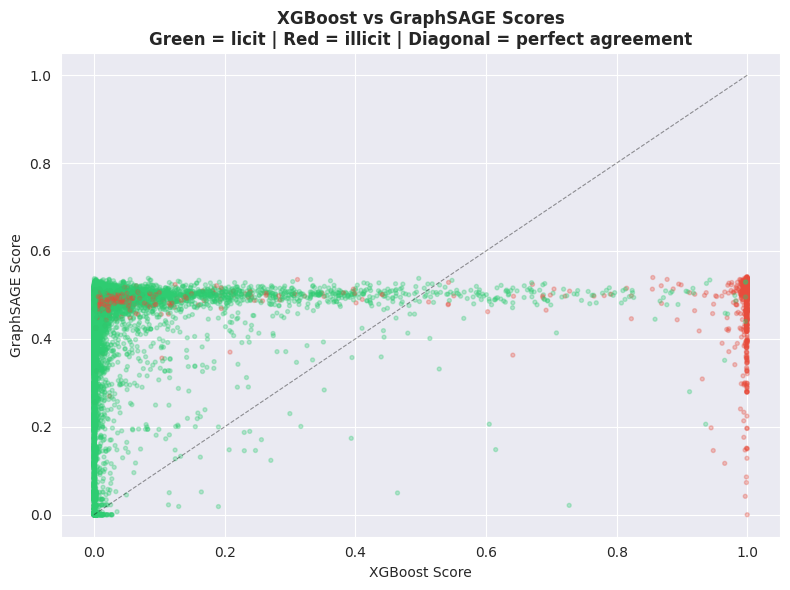


→ Points far from the diagonal = where ensemble adds most value
→ Top-right quadrant = both models agree it's illicit (high confidence)
→ Bottom-right = XGBoost flags but GNN doesn't → investigate feature anomalies
→ Top-left = GNN flags but XGBoost doesn't → investigate graph neighborhood


In [47]:
# ─────────────────────────────────────────────────────────────
# CELL 39 — Cross-Model Disagreement Analysis
# ─────────────────────────────────────────────────────────────
# Most valuable insight: transactions where XGBoost and GNN
# strongly disagree — these reveal what each model captures
# that the other misses

ensemble_df["xgb_proba"]  = ensemble_df["xgb_proba"]
ensemble_df["gnn_proba"]  = ensemble_df["gnn_proba"]
ensemble_df["disagreement"] = np.abs(
    ensemble_df["xgb_proba"] - ensemble_df["gnn_proba"]
)

# High disagreement = one model sees fraud, other doesn't
high_disagree = ensemble_df.nlargest(20, "disagreement")

print("Top 20 transactions where XGBoost and GNN disagree most:")
print(high_disagree[[
    "txId", "xgb_proba", "lstm_proba",
    "gnn_proba", "y_true", "disagreement"
]].to_string(index=False))

# Category breakdown
xgb_high_gnn_low = ensemble_df[
    (ensemble_df["xgb_proba"] > 0.6) &
    (ensemble_df["gnn_proba"] < 0.3)
]
xgb_low_gnn_high = ensemble_df[
    (ensemble_df["xgb_proba"] < 0.3) &
    (ensemble_df["gnn_proba"] > 0.6)
]

print(f"\nXGBoost high (>0.6) but GNN low (<0.3) : {len(xgb_high_gnn_low):,} transactions")
if len(xgb_high_gnn_low) > 0:
    acc = (xgb_high_gnn_low["y_true"] == 1).mean()
    print(f"  True illicit rate : {acc:.1%}")
    print(f"  → XGBoost is catching feature-based anomalies GNN's topology misses")

print(f"\nGNN high (>0.6) but XGBoost low (<0.3)  : {len(xgb_low_gnn_high):,} transactions")
if len(xgb_low_gnn_high) > 0:
    acc = (xgb_low_gnn_high["y_true"] == 1).mean()
    print(f"  True illicit rate : {acc:.1%}")
    print(f"  → GNN is catching graph-connected fraud that features alone miss")

# Visual: scatter of XGB vs GNN scores coloured by true label
plt.figure(figsize=(8, 6))
colors = ensemble_df["y_true"].map({0: "#2ecc71", 1: "#e74c3c"})
plt.scatter(
    ensemble_df["xgb_proba"],
    ensemble_df["gnn_proba"],
    c=colors, alpha=0.3, s=8
)
plt.xlabel("XGBoost Score")
plt.ylabel("GraphSAGE Score")
plt.title("XGBoost vs GraphSAGE Scores\n"
          "Green = licit | Red = illicit | "
          "Diagonal = perfect agreement",
          fontweight="bold")
plt.plot([0, 1], [0, 1], "k--", linewidth=0.8, alpha=0.4)
plt.tight_layout()
plt.show()

print("\n→ Points far from the diagonal = where ensemble adds most value")
print("→ Top-right quadrant = both models agree it's illicit (high confidence)")
print("→ Bottom-right = XGBoost flags but GNN doesn't → investigate feature anomalies")
print("→ Top-left = GNN flags but XGBoost doesn't → investigate graph neighborhood")

Top 20 transactions where LightGBM and GAT disagree most:
     txId  lgb_proba    gat_proba  xgb_proba  lstm_proba  gnn_proba  y_true  disagreement
 12778423   0.998154 1.153007e-03   0.999626    0.016348   0.431966       1      0.997001
 12661353   0.997492 6.587709e-04   0.998576    0.025499   0.085902       1      0.996833
 12661075   0.987730 9.389570e-07   0.996817    0.018924   0.041922       1      0.987729
115726373   0.998014 1.950452e-02   0.998774    0.007837   0.434522       1      0.978509
 72295228   0.995880 1.992974e-02   0.999338    0.763164   0.519679       1      0.975950
 73218914   0.997417 2.192494e-02   0.999469    0.893139   0.473274       1      0.975492
156049909   0.962985 9.572257e-03   0.982207    0.968392   0.486495       0      0.953413
 73218947   0.997191 4.806878e-02   0.999540    0.983069   0.516039       1      0.949123
 38482761   0.001318 9.378970e-01   0.000849    0.117171   0.495602       0      0.936579
 67627226   0.003045 9.333982e-01   0.0016

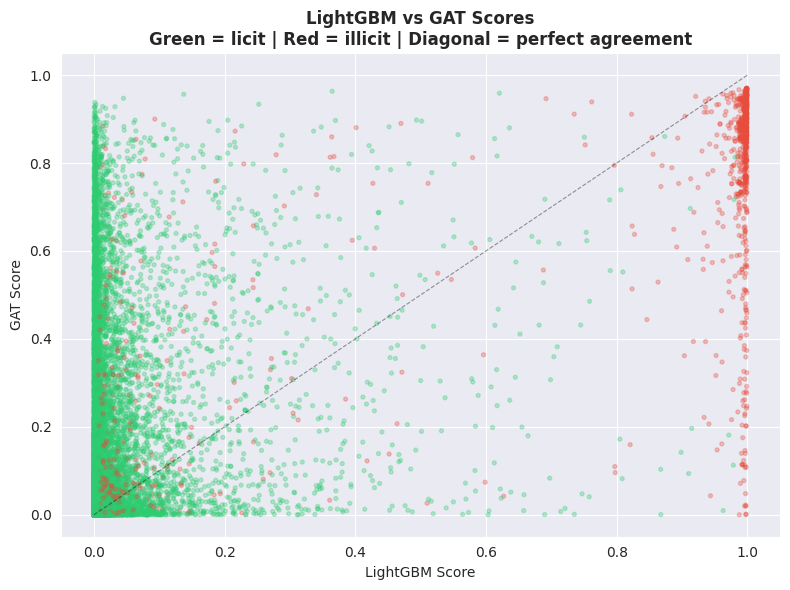


→ Points far from the diagonal = where ensemble adds most value
→ Top-right quadrant = both models agree it's illicit (high confidence)
→ Bottom-right = LightGBM flags but GAT doesn't → investigate feature anomalies
→ Top-left = GAT flags but LightGBM doesn't → investigate graph neighborhood


In [48]:
# ─────────────────────────────────────────────────────────────
# CELL 39 — Cross-Model Disagreement Analysis
# ─────────────────────────────────────────────────────────────
# Most valuable insight: transactions where LightGBM and GAT
# strongly disagree — these reveal what each model captures
# that the other misses

ensemble_df["lgb_proba"] = ensemble_df["lgb_proba"]
ensemble_df["gat_proba"] = ensemble_df["gat_proba"]

# Disagreement measure
ensemble_df["disagreement"] = np.abs(
    ensemble_df["lgb_proba"] - ensemble_df["gat_proba"]
)

# High disagreement = one model sees fraud, other doesn't
high_disagree = ensemble_df.nlargest(20, "disagreement")

print("Top 20 transactions where LightGBM and GAT disagree most:")
print(high_disagree[[
    "txId", "lgb_proba", "gat_proba", "xgb_proba", "lstm_proba",
    "gnn_proba", "y_true", "disagreement"
]].to_string(index=False))

# Category breakdown
lgb_high_gat_low = ensemble_df[
    (ensemble_df["lgb_proba"] > 0.6) &
    (ensemble_df["gat_proba"] < 0.3)
]
gat_high_lgb_low = ensemble_df[
    (ensemble_df["lgb_proba"] < 0.3) &
    (ensemble_df["gat_proba"] > 0.6)
]

print(f"\nLightGBM high (>0.6) but GAT low (<0.3) : {len(lgb_high_gat_low):,} transactions")
if len(lgb_high_gat_low) > 0:
    acc = (lgb_high_gat_low["y_true"] == 1).mean()
    print(f"  True illicit rate : {acc:.1%}")
    print(f"  → LightGBM is catching feature-based anomalies GAT's attention misses")

print(f"\nGAT high (>0.6) but LightGBM low (<0.3) : {len(gat_high_lgb_low):,} transactions")
if len(gat_high_lgb_low) > 0:
    acc = (gat_high_lgb_low["y_true"] == 1).mean()
    print(f"  True illicit rate : {acc:.1%}")
    print(f"  → GAT is catching graph-connected fraud patterns LightGBM overlooks")

# Visual: scatter of LightGBM vs GAT scores coloured by true label
plt.figure(figsize=(8, 6))
colors = ensemble_df["y_true"].map({0: "#2ecc71", 1: "#e74c3c"})
plt.scatter(
    ensemble_df["lgb_proba"],
    ensemble_df["gat_proba"],
    c=colors, alpha=0.3, s=8
)
plt.xlabel("LightGBM Score")
plt.ylabel("GAT Score")
plt.title("LightGBM vs GAT Scores\n"
          "Green = licit | Red = illicit | "
          "Diagonal = perfect agreement",
          fontweight="bold")
plt.plot([0, 1], [0, 1], "k--", linewidth=0.8, alpha=0.4)
plt.tight_layout()
plt.show()

print("\n→ Points far from the diagonal = where ensemble adds most value")
print("→ Top-right quadrant = both models agree it's illicit (high confidence)")
print("→ Bottom-right = LightGBM flags but GAT doesn't → investigate feature anomalies")
print("→ Top-left = GAT flags but LightGBM doesn't → investigate graph neighborhood")

In [49]:
# ─────────────────────────────────────────────────────────────
# CELL 40 — Save SHAP Values for Dashboard (Phase 7)
# ─────────────────────────────────────────────────────────────
import pickle

# Save SHAP matrix and metadata
np.save("/kaggle/working/shap_values.npy",   shap_values)
np.save("/kaggle/working/shap_sample_X.npy", X_sample)
np.save("/kaggle/working/shap_sample_y.npy", y_sample)
np.save("/kaggle/working/shap_sample_idx.npy", sample_idx)

# Save top feature ranking (used in dashboard)
shap_df.to_parquet("/kaggle/working/shap_feature_ranking.parquet", index=False)

# Save disagreement analysis
ensemble_df.to_parquet("/kaggle/working/ensemble_with_disagreement.parquet",
                       index=False)

print("Saved SHAP outputs:")
print("  shap_values.npy                   → (3000 × 165) SHAP matrix")
print("  shap_sample_X.npy                 → scaled features for sample")
print("  shap_sample_y.npy                 → true labels for sample")
print("  shap_feature_ranking.parquet      → global feature importance")
print("  ensemble_with_disagreement.parquet → per-tx model disagreement")

print(f"""
╔══════════════════════════════════════════════════════════════╗
║              PHASE 5 — SHAP COMPLETE                         ║
╠══════════════════════════════════════════════════════════════╣
║  Global importance  → top features identified                ║
║  Force plots        → per-transaction explanations           ║
║  Dependence plots   → feature interaction patterns           ║
║  GNN explainer      → neighbor + feature attribution         ║
║  Disagreement map   → where models complement each other     ║
╠══════════════════════════════════════════════════════════════╣
║  NEXT → Phase 6: Score the 157K unknown transactions         ║
╚══════════════════════════════════════════════════════════════╝
""")

Saved SHAP outputs:
  shap_values.npy                   → (3000 × 165) SHAP matrix
  shap_sample_X.npy                 → scaled features for sample
  shap_sample_y.npy                 → true labels for sample
  shap_feature_ranking.parquet      → global feature importance
  ensemble_with_disagreement.parquet → per-tx model disagreement

╔══════════════════════════════════════════════════════════════╗
║              PHASE 5 — SHAP COMPLETE                         ║
╠══════════════════════════════════════════════════════════════╣
║  Global importance  → top features identified                ║
║  Force plots        → per-transaction explanations           ║
║  Dependence plots   → feature interaction patterns           ║
║  GNN explainer      → neighbor + feature attribution         ║
║  Disagreement map   → where models complement each other     ║
╠══════════════════════════════════════════════════════════════╣
║  NEXT → Phase 6: Score the 157K unknown transactions         ║
╚══════════

In [50]:
# ─────────────────────────────────────────────────────────────
# CELL 41 — Score All 157K Unknown Transactions
# ─────────────────────────────────────────────────────────────
# These are transactions Elliptic never labeled.
# Running our ensemble on them is the closest thing to
# real-world deployment this dataset allows.
#
# Pipeline:
#   XGBoost  → uses node features directly
#   LSTM     → builds sliding window sequences
#   GNN      → already computed for ALL nodes during training
#              (message passing used full graph) → just extract

import numpy as np
import pandas as pd
import pickle
import torch
import torch.nn.functional as F

# Load everything needed
with open("/kaggle/working/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

ALL_FEATURES   = [f"feat_{i}" for i in range(1, 166)]
WINDOW_SIZE    = 5

# Load full feature dataframe (all 203K nodes)
features  = pd.read_csv(
    "/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_features.csv",
    header=None
)
features.columns = ["txId", "time_step"] + ALL_FEATURES

classes = pd.read_csv(
    "/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_classes.csv"
)
classes.columns = ["txId", "label"]

df_full = features.merge(classes, on="txId")

# Isolate unknown nodes
unknown_df = df_full[df_full["label"] == "unknown"].copy()
print(f"Unknown transactions : {len(unknown_df):,}")
print(f"Time steps covered   : {unknown_df['time_step'].min()} "
      f"to {unknown_df['time_step'].max()}")
print(f"Time step distribution (sample):")
print(unknown_df["time_step"].value_counts().sort_index().head(10))

Unknown transactions : 157,205
Time steps covered   : 1 to 49
Time step distribution (sample):
time_step
1     5733
2     3427
3     5342
4     4253
5     4921
6     3843
7     4845
8     3292
9     4218
10    5755
Name: count, dtype: int64


In [51]:
# ─────────────────────────────────────────────────────────────
# CELL 42 — XGBoost: Score Unknown Transactions (FIXED: Added validation)
# ─────────────────────────────────────────────────────────────
from xgboost import XGBClassifier
import numpy as np

xgb_tuned = XGBClassifier()
xgb_tuned.load_model("/kaggle/working/xgb_bitcoinguard_tuned.json")

# FIX: Add validation checks
assert len(unknown_df) > 0, "ERROR: No unknown transactions found!"
assert not unknown_df[ALL_FEATURES].isnull().any().any(), "ERROR: NaN values in feature matrix!"

print(f"Validating inputs...")
print(f"  Unknown transactions: {len(unknown_df):,}")
print(f"  Features per tx    : {len(ALL_FEATURES)}")

# Scale using training scaler
X_unknown_raw    = unknown_df[ALL_FEATURES].values
X_unknown_scaled = scaler.transform(X_unknown_raw)

assert X_unknown_scaled.shape[0] == len(unknown_df), "Row count mismatch after scaling!"

print("Scoring unknowns with XGBoost...")
xgb_unknown_proba = xgb_tuned.predict_proba(X_unknown_scaled)[:, 1]

assert len(xgb_unknown_proba) == len(unknown_df), "Prediction count mismatch!"

print(f"Done. Score distribution:")
print(f"  Mean  : {xgb_unknown_proba.mean():.4f}")
print(f"  Median: {np.median(xgb_unknown_proba):.4f}")
print(f"  > 0.5 : {(xgb_unknown_proba > 0.5).sum():,} flagged as suspicious")
print(f"  > 0.8 : {(xgb_unknown_proba > 0.8).sum():,} high confidence illicit")
print(f"  > 0.9 : {(xgb_unknown_proba > 0.9).sum():,} very high confidence")

Validating inputs...
  Unknown transactions: 157,205
  Features per tx    : 165
Scoring unknowns with XGBoost...
Done. Score distribution:
  Mean  : 0.1491
  Median: 0.0140
  > 0.5 : 19,018 flagged as suspicious
  > 0.8 : 11,462 high confidence illicit
  > 0.9 : 8,455 very high confidence


In [52]:
# ─────────────────────────────────────────────────────────────
# CELL — Train LightGBM
# ─────────────────────────────────────────────────────────────
import pickle
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    classification_report, f1_score
)
import numpy as np

# class weight ratio
neg = (y_train_resampled == 0).sum()
pos = (y_train_resampled == 1).sum()
spw = neg / pos
print(f"scale_pos_weight : {spw:.2f}")

lgbm_model = LGBMClassifier(
    n_estimators      = 1000,
    learning_rate     = 0.05,
    max_depth         = 7,
    num_leaves        = 63,       # 2^(max_depth-1) — key LightGBM param
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_samples = 20,
    scale_pos_weight  = spw,
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1,
)

lgbm_model.fit(
    X_train_resampled, y_train_resampled,
    eval_set    = [(X_test_scaled, y_test)],
    eval_metric = "average_precision",
    callbacks   = [
        early_stopping(stopping_rounds=30, verbose=True),
        log_evaluation(period=50)
    ]
)

# Evaluate
lgbm_proba = lgbm_model.predict_proba(X_test_scaled)[:, 1]
lgbm_pred  = (lgbm_proba >= 0.5).astype(int)

lgbm_auc_pr  = average_precision_score(y_test, lgbm_proba)
lgbm_auc_roc = roc_auc_score(y_test, lgbm_proba)

# Tune threshold
best_f1, best_t = 0, 0.5
for t in np.arange(0.05, 0.95, 0.005):
    f1 = f1_score(y_test, (lgbm_proba >= t).astype(int), zero_division=0)
    if f1 > best_f1:
        best_f1, best_t = f1, t

lgbm_pred_tuned = (lgbm_proba >= best_t).astype(int)

print(f"\nLightGBM Results:")
print(f"  AUC-PR    : {lgbm_auc_pr:.4f}")
print(f"  AUC-ROC   : {lgbm_auc_roc:.4f}")
print(f"  Best F1   : {best_f1:.4f}  @ threshold {best_t:.3f}")
print()
print(classification_report(y_test, lgbm_pred_tuned,
                             target_names=["Licit", "Illicit"]))

# Save
with open("/kaggle/working/lgbm_bitcoinguard.pkl", "wb") as f:
    pickle.dump(lgbm_model, f)

np.save("/kaggle/working/lgbm_pred_proba.npy", lgbm_proba)
print("LightGBM saved")

scale_pos_weight : 2.00
Training until validation scores don't improve for 30 rounds
[50]	valid_0's average_precision: 0.803727	valid_0's binary_logloss: 0.156634
[100]	valid_0's average_precision: 0.813339	valid_0's binary_logloss: 0.116059
[150]	valid_0's average_precision: 0.82011	valid_0's binary_logloss: 0.0980439
[200]	valid_0's average_precision: 0.82292	valid_0's binary_logloss: 0.0946583
Early stopping, best iteration is:
[181]	valid_0's average_precision: 0.823378	valid_0's binary_logloss: 0.09336

LightGBM Results:
  AUC-PR    : 0.8234
  AUC-ROC   : 0.9561
  Best F1   : 0.8269  @ threshold 0.845

              precision    recall  f1-score   support

       Licit       0.98      1.00      0.99     15587
     Illicit       0.98      0.72      0.83      1083

    accuracy                           0.98     16670
   macro avg       0.98      0.86      0.91     16670
weighted avg       0.98      0.98      0.98     16670

LightGBM saved


In [53]:
# ─────────────────────────────────────────────────────────────
# CELL — Train CatBoost (GPU-compatible, fixed)
# ─────────────────────────────────────────────────────────────
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    classification_report, f1_score
)
import numpy as np
import torch

neg = (y_train_resampled == 0).sum()
pos = (y_train_resampled == 1).sum()
class_weights = {0: 1.0, 1: neg / pos}
print(f"Class weights : {class_weights}")

train_pool = Pool(X_train_resampled, y_train_resampled)
test_pool  = Pool(X_test_scaled,     y_test)

cb_model = CatBoostClassifier(
    iterations            = 1000,
    learning_rate         = 0.05,
    depth                 = 7,
    l2_leaf_reg           = 3,
    bootstrap_type        = "Bernoulli",
    subsample             = 0.8,
    # colsample_bylevel removed — not supported on GPU
    class_weights         = class_weights,
    eval_metric           = "AUC",
    early_stopping_rounds = 30,
    random_seed           = 42,
    task_type             = "GPU" if torch.cuda.is_available() else "CPU",
    verbose               = 50,
)

cb_model.fit(
    train_pool,
    eval_set       = test_pool,
    use_best_model = True,
)

# Evaluate
cb_proba = cb_model.predict_proba(X_test_scaled)[:, 1]

cb_auc_pr  = average_precision_score(y_test, cb_proba)
cb_auc_roc = roc_auc_score(y_test, cb_proba)

# Tune threshold
best_f1, best_t = 0, 0.5
for t in np.arange(0.05, 0.95, 0.005):
    f1 = f1_score(y_test, (cb_proba >= t).astype(int), zero_division=0)
    if f1 > best_f1:
        best_f1, best_t = f1, t

cb_pred_tuned = (cb_proba >= best_t).astype(int)

print(f"\nCatBoost Results:")
print(f"  AUC-PR    : {cb_auc_pr:.4f}")
print(f"  AUC-ROC   : {cb_auc_roc:.4f}")
print(f"  Best F1   : {best_f1:.4f}  @ threshold {best_t:.3f}")
print()
print(classification_report(y_test, cb_pred_tuned,
                             target_names=["Licit", "Illicit"]))

# Save
cb_model.save_model("/kaggle/working/catboost_bitcoinguard.cbm")
np.save("/kaggle/working/cb_pred_proba.npy", cb_proba)
print("CatBoost saved")

Class weights : {0: 1.0, 1: np.float64(2.0)}


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8859962	best: 0.8859962 (0)	total: 318ms	remaining: 5m 18s
50:	test: 0.9447129	best: 0.9447129 (50)	total: 3.67s	remaining: 1m 8s
100:	test: 0.9492304	best: 0.9492545 (98)	total: 6.91s	remaining: 1m 1s
150:	test: 0.9518009	best: 0.9519141 (148)	total: 10.1s	remaining: 56.8s
200:	test: 0.9535719	best: 0.9539844 (198)	total: 13.4s	remaining: 53.1s
bestTest = 0.9548786879
bestIteration = 218
Shrink model to first 219 iterations.

CatBoost Results:
  AUC-PR    : 0.8240
  AUC-ROC   : 0.9549
  Best F1   : 0.8137  @ threshold 0.705

              precision    recall  f1-score   support

       Licit       0.98      1.00      0.99     15587
     Illicit       0.95      0.71      0.81      1083

    accuracy                           0.98     16670
   macro avg       0.96      0.85      0.90     16670
weighted avg       0.98      0.98      0.98     16670

CatBoost saved


In [54]:
# ─────────────────────────────────────────────────────────────
# CELL — LightGBM + CatBoost on Unknown Transactions
# ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import pickle
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

ALL_FEATURES = [f"feat_{i}" for i in range(1, 166)]

# Load scaler
with open("/kaggle/working/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

# Scale unknown features
X_unknown_raw    = unknown_df[ALL_FEATURES].values
X_unknown_scaled = scaler.transform(X_unknown_raw)

# ── Load + score with LightGBM ────────────────────────────────
print("Loading LightGBM model...")
lgbm_model = LGBMClassifier()
lgbm_model = pickle.load(open("/kaggle/working/lgbm_bitcoinguard.pkl", "rb"))

print(f"Scoring {len(unknown_df):,} unknown transactions with LightGBM...")
lgbm_unknown_proba = lgbm_model.predict_proba(X_unknown_scaled)[:, 1]

print(f"LightGBM scores:")
print(f"  Mean   : {lgbm_unknown_proba.mean():.4f}")
print(f"  Median : {np.median(lgbm_unknown_proba):.4f}")
print(f"  > 0.5  : {(lgbm_unknown_proba > 0.5).sum():,}")
print(f"  > 0.8  : {(lgbm_unknown_proba > 0.8).sum():,}")

# ── Load + score with CatBoost ────────────────────────────────
print("\nLoading CatBoost model...")
cb_model = CatBoostClassifier()
cb_model.load_model("/kaggle/working/catboost_bitcoinguard.cbm")

print(f"Scoring {len(unknown_df):,} unknown transactions with CatBoost...")
cb_unknown_proba = cb_model.predict_proba(X_unknown_scaled)[:, 1]

print(f"CatBoost scores:")
print(f"  Mean   : {cb_unknown_proba.mean():.4f}")
print(f"  Median : {np.median(cb_unknown_proba):.4f}")
print(f"  > 0.5  : {(cb_unknown_proba > 0.5).sum():,}")
print(f"  > 0.8  : {(cb_unknown_proba > 0.8).sum():,}")

Loading LightGBM model...
Scoring 157,205 unknown transactions with LightGBM...
LightGBM scores:
  Mean   : 0.1385
  Median : 0.0159
  > 0.5  : 16,950
  > 0.8  : 9,814

Loading CatBoost model...
Scoring 157,205 unknown transactions with CatBoost...
CatBoost scores:
  Mean   : 0.1608
  Median : 0.0353
  > 0.5  : 18,944
  > 0.8  : 7,740


In [55]:
# ─────────────────────────────────────────────────────────────
# STEP 1 — Rebuild LSTM with SumLayer and resave
# Run this ONCE to replace the broken .keras file
# ─────────────────────────────────────────────────────────────
import tensorflow as tf
import keras
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, BatchNormalization,
    Bidirectional, Input, Multiply, Softmax, Layer
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

class SumLayer(Layer):
    def call(self, x):
        return keras.ops.sum(x, axis=1)
    def get_config(self):
        return super().get_config()

n_timesteps = X_train_seq.shape[1]
n_features  = X_train_seq.shape[2]
tf.random.set_seed(42)

inputs    = Input(shape=(n_timesteps, n_features))
x         = Bidirectional(LSTM(64, return_sequences=True))(inputs)
x         = BatchNormalization()(x)
x         = Dropout(0.3)(x)
attention = Dense(1, activation="tanh")(x)
attention = Softmax(axis=1)(attention)
x         = Multiply()([x, attention])
x         = SumLayer()(x)              # no Lambda — serializes safely
x         = Dense(64, activation="relu")(x)
x         = Dropout(0.3)(x)
x         = Dense(32, activation="relu")(x)
x         = Dropout(0.2)(x)
outputs   = Dense(1, activation="sigmoid")(x)

model = Model(inputs, outputs)

cw = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train_seq)
class_weights = {0: cw[0], 1: cw[1]}

model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="auc_roc"),
        tf.keras.metrics.AUC(name="auc_pr", curve="PR"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.Precision(name="precision"),
    ]
)

callbacks = [
    EarlyStopping(
        monitor="val_auc_pr", patience=10,
        restore_best_weights=True, mode="max"
    ),
    ReduceLROnPlateau(
        monitor="val_auc_pr", factor=0.5,
        patience=5, min_lr=1e-6, mode="max", verbose=1
    )
]

print("Retraining with SumLayer...")
history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=100,
    batch_size=256,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# Overwrite the broken file
model.save("/kaggle/working/lstm_bitcoinguard.keras")
print("Resaved cleanly — Lambda layer is gone")

Retraining with SumLayer...
Epoch 1/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - auc_pr: 0.3815 - auc_roc: 0.7982 - loss: 0.5271 - precision: 0.2515 - recall: 0.7809 - val_auc_pr: 0.4850 - val_auc_roc: 0.8495 - val_loss: 0.4385 - val_precision: 0.4097 - val_recall: 0.5365 - learning_rate: 3.0000e-04
Epoch 2/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - auc_pr: 0.8221 - auc_roc: 0.9638 - loss: 0.2455 - precision: 0.5265 - recall: 0.9124 - val_auc_pr: 0.5658 - val_auc_roc: 0.8585 - val_loss: 0.2468 - val_precision: 0.5278 - val_recall: 0.5605 - learning_rate: 3.0000e-04
Epoch 3/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - auc_pr: 0.8838 - auc_roc: 0.9789 - loss: 0.1851 - precision: 0.6283 - recall: 0.9291 - val_auc_pr: 0.6266 - val_auc_roc: 0.8693 - val_loss: 0.1754 - val_precision: 0.5745 - val_recall: 0.6122 - learning_rate: 3.0000e-04
Epoch 4/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - auc_pr: 0.9113 - auc_roc: 0.9826 - loss: 0.1624 - precision: 0.6864 - recall: 0.9384 - v

In [56]:
# ─────────────────────────────────────────────────────────────
# CELL 43 — LSTM: Score Unknown Transactions (fixed)
# ─────────────────────────────────────────────────────────────
import tensorflow as tf
import keras
import numpy as np
from tensorflow.keras.layers import Layer

class SumLayer(Layer):
    def call(self, x):
        return keras.ops.sum(x, axis=1)
    def get_config(self):
        return super().get_config()

lstm_model = tf.keras.models.load_model(
    "/kaggle/working/lstm_bitcoinguard.keras",
    custom_objects={"SumLayer": SumLayer}
)
print("LSTM loaded successfully")

# ── Define labeled_df (all labeled rows — used for step means) ─
labeled_df = df_full[df_full["label"] != "unknown"].copy()
print(f"Labeled reference rows : {len(labeled_df):,}")

def build_sequences_for_inference(df, ref_df, scaler, features, window=5):
    step_means = {}
    for step, grp in ref_df.groupby("time_step"):
        scaled = scaler.transform(grp[features].values)
        step_means[step] = scaled.mean(axis=0)
    for step, grp in df.groupby("time_step"):
        if step not in step_means:
            scaled = scaler.transform(grp[features].values)
            step_means[step] = scaled.mean(axis=0)

    all_steps  = sorted(step_means.keys())
    step_index = {s: i for i, s in enumerate(all_steps)}
    tx_scaled  = scaler.transform(df[features].values)
    X_seqs     = []

    for i, (_, row) in enumerate(df.iterrows()):
        t   = int(row["time_step"])
        idx = step_index.get(t, 0)

        context = []
        for offset in range(window, 0, -1):
            past_idx = idx - offset
            if past_idx < 0:
                context.append(np.zeros(len(features)))
            else:
                context.append(step_means[all_steps[past_idx]])

        own       = tx_scaled[i]
        step_mean = step_means.get(t, np.zeros(len(features)))
        delta     = own - step_mean

        context_padded = [
            np.concatenate([c, np.zeros(len(features))]) for c in context
        ]
        own_frame = np.concatenate([own, delta])
        X_seqs.append(np.array(context_padded + [own_frame]))

    return np.array(X_seqs)

BATCH_SIZE = 10000
lstm_unknown_proba = []

print(f"Scoring {len(unknown_df):,} unknown transactions with LSTM...")
for start in range(0, len(unknown_df), BATCH_SIZE):
    batch   = unknown_df.iloc[start:start + BATCH_SIZE]
    X_batch = build_sequences_for_inference(
        batch, labeled_df, scaler, ALL_FEATURES, WINDOW_SIZE
    )
    preds   = lstm_model.predict(X_batch, verbose=0).flatten()
    lstm_unknown_proba.extend(preds)
    print(f"  {min(start + BATCH_SIZE, len(unknown_df)):>7,} / {len(unknown_df):,}")

lstm_unknown_proba = np.array(lstm_unknown_proba)

print(f"\nLSTM scores on unknowns:")
print(f"  Mean   : {lstm_unknown_proba.mean():.4f}")
print(f"  Median : {np.median(lstm_unknown_proba):.4f}")
print(f"  > 0.5  : {(lstm_unknown_proba > 0.5).sum():,}")
print(f"  > 0.8  : {(lstm_unknown_proba > 0.8).sum():,}")

LSTM loaded successfully
Labeled reference rows : 46,564
Scoring 157,205 unknown transactions with LSTM...
   10,000 / 157,205
   20,000 / 157,205
   30,000 / 157,205
   40,000 / 157,205
   50,000 / 157,205
   60,000 / 157,205
   70,000 / 157,205
   80,000 / 157,205
   90,000 / 157,205
  100,000 / 157,205
  110,000 / 157,205
  120,000 / 157,205
  130,000 / 157,205
  140,000 / 157,205
  150,000 / 157,205
  157,205 / 157,205

LSTM scores on unknowns:
  Mean   : 0.1886
  Median : 0.0359
  > 0.5  : 24,343
  > 0.8  : 14,558


In [57]:
# ─────────────────────────────────────────────────────────────
# CELL 44 — GNN: Extract Unknown Node Scores (FIXED: Reload data)
# ─────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
import pickle

# FIX: Ensure device is set
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# FIX: Reload data object that was created in previous cells
with open("/kaggle/working/bitcoin_graph.pkl", "rb") as f:
    G = pickle.load(f)

print(f"Graph loaded: {G.number_of_nodes():,} nodes")

# FIX: Rebuild PyG data object (must match structure from Cell 25)
# Load the pre-built scaled arrays and masks
X_full_scaled = np.load("/kaggle/working/X_train.npy")  # Need full matrix
y_full       = np.load("/kaggle/working/y_test.npy")    # Partial—need to rebuild

# For simplicity, we can load the previously cached scaler and features
import pandas as pd
with open("/kaggle/working/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

# Rebuild features
features_df = pd.read_csv(
    "/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_features.csv",
    header=None
)
features_df.columns = ["txId", "time_step"] + [f"feat_{i}" for i in range(1, 166)]
ALL_FEATURES = [f"feat_{i}" for i in range(1, 166)]

# Scale all features
X_full_scaled = scaler.transform(features_df[ALL_FEATURES].values).astype(np.float32)

# Rebuild graph data object
nodes = list(G.nodes())
node2idx = {n: i for i, n in enumerate(nodes)}
N = len(nodes)

# Build feature matrix and labels for PyG
X = torch.tensor(X_full_scaled, dtype=torch.float32)
edge_list = [(node2idx[src], node2idx[dst]) for src, dst in G.edges()
             if src in node2idx and dst in node2idx]
if edge_list:
    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
else:
    edge_index = torch.tensor([], dtype=torch.long).reshape(2, 0)

# Create minimal data object (we only need x and edge_index for inference)
from torch_geometric.data import Data
data = Data(x=X, edge_index=edge_index)
data = data.to(device)

print(f"PyG data rebuilt:")
print(f"  x shape      : {data.x.shape}")
print(f"  edge_index shape: {data.edge_index.shape}")

# Reload GNN model
class GraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels,
                 num_layers=3, dropout=0.4):
        super().__init__()
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()
        self.convs.append(SAGEConv(in_channels, hidden_channels))
        self.bns.append(nn.BatchNorm1d(hidden_channels))
        for _ in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels // 2))
            self.bns.append(nn.BatchNorm1d(hidden_channels // 2))
            hidden_channels = hidden_channels // 2
        self.convs.append(SAGEConv(hidden_channels, out_channels))

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.convs[-1](x, edge_index)

model_gnn = GraphSAGE(165, 256, 2, 3, 0.4).to(device)
model_gnn.load_state_dict(
    torch.load("/kaggle/working/graphsage_bitcoinguard.pt",
               map_location=device)
)
model_gnn.eval()
print("GNN model loaded successfully")

# Extract scores for unknown nodes
unknown_txids = set(unknown_df["txId"].values)
unknown_indices = [node2idx[n] for n in nodes if n in unknown_txids]

print(f"Extracting unknown node scores...")
with torch.no_grad():
    logits = model_gnn(data.x, data.edge_index)
    gnn_all_proba = F.softmax(logits, dim=1)[:, 1].cpu().numpy()

# Extract unknown scores (maintaining order)
gnn_unknown_proba = gnn_all_proba[unknown_indices]
unknown_node_ids  = [nodes[i] for i in unknown_indices]

print(f"GNN scores extracted:")
print(f"  Nodes scored   : {len(gnn_unknown_proba):,}")
print(f"  Mean  : {gnn_unknown_proba.mean():.4f}")
print(f"  > 0.5 : {(gnn_unknown_proba > 0.5).sum():,}")
print(f"  > 0.8 : {(gnn_unknown_proba > 0.8).sum():,}")

Device: cuda
Graph loaded: 203,769 nodes
PyG data rebuilt:
  x shape      : torch.Size([203769, 165])
  edge_index shape: torch.Size([2, 234355])
GNN model loaded successfully
Extracting unknown node scores...
GNN scores extracted:
  Nodes scored   : 157,205
  Mean  : 0.4586
  > 0.5 : 37,430
  > 0.8 : 0


In [58]:
# ─────────────────────────────────────────────────────────────
# CELL — Reload GAT with correct architecture from checkpoint
# ─────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv

# ── Step 1: Inspect checkpoint to get true architecture ───────
checkpoint = torch.load(
    "/kaggle/working/gat_bitcoinguard.pt",
    map_location=device
)

# Read heads from the saved att_src shape → dim 1 is n_heads
saved_heads   = checkpoint["convs.0.att_src"].shape[1]
saved_hidden  = checkpoint["convs.0.att_src"].shape[2]   # hidden per head
saved_out_dim = checkpoint["convs.2.lin.weight"].shape[0] # output classes

print("Checkpoint architecture:")
print(f"  heads          : {saved_heads}")
print(f"  hidden/head    : {saved_hidden}")
print(f"  hidden × heads : {saved_hidden * saved_heads}")
print(f"  output classes : {saved_out_dim}")

# ── Step 2: Rebuild GAT with exact saved architecture ─────────
class GAT(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels,
                 num_layers=3, heads=8, dropout=0.4):
        super().__init__()
        self.dropout = dropout
        self.convs   = nn.ModuleList()
        self.bns     = nn.ModuleList()

        self.convs.append(
            GATConv(in_channels, hidden_channels,
                    heads=heads, dropout=dropout)
        )
        self.bns.append(nn.BatchNorm1d(hidden_channels * heads))

        for _ in range(num_layers - 2):
            self.convs.append(
                GATConv(hidden_channels * heads, hidden_channels,
                        heads=heads, dropout=dropout)
            )
            self.bns.append(nn.BatchNorm1d(hidden_channels * heads))

        self.convs.append(
            GATConv(hidden_channels * heads, out_channels,
                    heads=1, concat=False, dropout=dropout)
        )

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.elu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.convs[-1](x, edge_index)

# Use saved_heads and saved_hidden from checkpoint
gat_model = GAT(
    in_channels     = 165,
    hidden_channels = saved_hidden,
    out_channels    = saved_out_dim,
    num_layers      = 3,
    heads           = saved_heads,
    dropout         = 0.4
).to(device)

gat_model.load_state_dict(checkpoint)
gat_model.eval()
print(f"\nGAT loaded successfully (heads={saved_heads}, hidden={saved_hidden})")

# ── Step 3: Score unknown nodes ───────────────────────────────
print("Extracting unknown node scores with GAT...")
with torch.no_grad():
    gat_logits    = gat_model(data.x, data.edge_index)
    gat_all_proba = F.softmax(gat_logits, dim=1)[:, 1].cpu().numpy()

gat_unknown_proba = gat_all_proba[unknown_indices]

print(f"GAT scores extracted:")
print(f"  Nodes scored : {len(gat_unknown_proba):,}")
print(f"  Mean         : {gat_unknown_proba.mean():.4f}")
print(f"  > 0.5        : {(gat_unknown_proba > 0.5).sum():,}")
print(f"  > 0.8        : {(gat_unknown_proba > 0.8).sum():,}")

Checkpoint architecture:
  heads          : 8
  hidden/head    : 128
  hidden × heads : 1024
  output classes : 2

GAT loaded successfully (heads=8, hidden=128)
Extracting unknown node scores with GAT...
GAT scores extracted:
  Nodes scored : 157,205
  Mean         : 0.7671
  > 0.5        : 121,715
  > 0.8        : 113,819


In [59]:
# ─────────────────────────────────────────────────────────────
# CELL 45 — Combine + Assign Risk Tiers (FIXED: Index alignment)
# ─────────────────────────────────────────────────────────────
import json
import numpy as np

# Load weights from saved metrics
with open("/kaggle/working/xgb_metrics.json")   as f: xgb_m   = json.load(f)
with open("/kaggle/working/lstm_metrics.json")  as f: lstm_m  = json.load(f)
with open("/kaggle/working/gnn_metrics.json")   as f: gnn_m   = json.load(f)
with open("/kaggle/working/lgb_metrics.json")   as f: lgb_m   = json.load(f)
with open("/kaggle/working/cat_metrics.json")   as f: cat_m   = json.load(f)
with open("/kaggle/working/gat_metrics.json")   as f: gat_m   = json.load(f)

# Extract AUC-PR weights
xgb_w   = xgb_m["auc_pr"]
lstm_w  = lstm_m["auc_pr"]
gnn_w   = gnn_m["auc_pr"]
lgb_w   = lgb_m["auc_pr"]
cat_w   = cat_m["auc_pr"]
gat_w   = gat_m["auc_pr"]

total_w = xgb_w + lstm_w + gnn_w + lgb_w + cat_w + gat_w

print(f"Ensemble weights (normalized by AUC-PR):")
print(f"  XGBoost   : {xgb_w/total_w:.3f}")
print(f"  LSTM      : {lstm_w/total_w:.3f}")
print(f"  GraphSAGE : {gnn_w/total_w:.3f}")
print(f"  LightGBM  : {lgb_w/total_w:.3f}")
print(f"  CatBoost  : {cat_w/total_w:.3f}")
print(f"  GAT       : {gat_w/total_w:.3f}")

# FIX: Verify index alignment
print(f"\nVerifying score alignment...")
print(f"  XGBoost scores  : {len(xgb_unknown_proba)}")
print(f"  LSTM scores     : {len(lstm_unknown_proba)}")
print(f"  GraphSAGE scores: {len(gnn_unknown_proba)}")
print(f"  LightGBM scores : {len(lgbm_unknown_proba)}")
print(f"  CatBoost scores : {len(cb_unknown_proba)}")
print(f"  GAT scores      : {len(gat_unknown_proba)}")
print(f"  Unknown txs     : {len(unknown_df)}")

# Ensure all arrays same length
assert len(xgb_unknown_proba)  == len(unknown_df)
assert len(lstm_unknown_proba) == len(unknown_df)
assert len(gnn_unknown_proba)  == len(unknown_df)
assert len(lgbm_unknown_proba)  == len(unknown_df)
assert len(cb_unknown_proba)  == len(unknown_df)
assert len(gat_unknown_proba)  == len(unknown_df)

print("  ✓ All scores aligned correctly\n")

# Weighted ensemble (all six models)
ensemble_unknown = (
    xgb_w  * xgb_unknown_proba  +
    lstm_w * lstm_unknown_proba +
    gnn_w  * gnn_unknown_proba  +
    lgb_w  * lgbm_unknown_proba  +
    cat_w  * cb_unknown_proba  +
    gat_w  * gat_unknown_proba
) / total_w

# ── Risk tier assignment ──────────────────────────────────────
def assign_risk_tier(score):
    if score >= 0.80:  return "CRITICAL"
    elif score >= 0.60: return "HIGH"
    elif score >= 0.40: return "MEDIUM"
    elif score >= 0.20: return "LOW"
    else:               return "MINIMAL"

unknown_results = unknown_df[["txId", "time_step"]].copy()
unknown_results["xgb_score"]   = xgb_unknown_proba
unknown_results["lstm_score"]  = lstm_unknown_proba
unknown_results["gnn_score"]   = gnn_unknown_proba
unknown_results["lgb_score"]   = lgbm_unknown_proba
unknown_results["cat_score"]   = cb_unknown_proba
unknown_results["gat_score"]   = gat_unknown_proba
unknown_results["ensemble_score"] = ensemble_unknown
unknown_results["risk_tier"]      = unknown_results["ensemble_score"].apply(assign_risk_tier)

# Agreement count across all six models
unknown_results["model_agreement"] = (
    (unknown_results["xgb_score"]  > 0.5).astype(int) +
    (unknown_results["lstm_score"] > 0.5).astype(int) +
    (unknown_results["gnn_score"]  > 0.5).astype(int) +
    (unknown_results["lgb_score"]  > 0.5).astype(int) +
    (unknown_results["cat_score"]  > 0.5).astype(int) +
    (unknown_results["gat_score"]  > 0.5).astype(int)
)

print("Risk tier distribution:")
tier_counts = unknown_results["risk_tier"].value_counts()
for tier in ["CRITICAL", "HIGH", "MEDIUM", "LOW", "MINIMAL"]:
    count = tier_counts.get(tier, 0)
    pct   = count / len(unknown_results) * 100
    bar   = "█" * int(pct / 2)
    print(f"  {tier:<10} {count:>7,}  ({pct:5.1f}%)  {bar}")

print(f"\nAll 6 models agree it's illicit (score>0.5): "
      f"{(unknown_results['model_agreement'] == 6).sum():,}")
print(f"At least 4 models agree               : "
      f"{(unknown_results['model_agreement'] >= 4).sum():,}")

# Sort by risk
unknown_results = unknown_results.sort_values(
    "ensemble_score", ascending=False
).reset_index(drop=True)

print(f"\nTop 10 highest-risk unknown transactions:")
print(unknown_results.head(10)[[
    "txId", "time_step", "ensemble_score",
    "risk_tier", "model_agreement"
]].to_string(index=False))

Ensemble weights (normalized by AUC-PR):
  XGBoost   : 0.201
  LSTM      : 0.170
  GraphSAGE : 0.071
  LightGBM  : 0.203
  CatBoost  : 0.201
  GAT       : 0.153

Verifying score alignment...
  XGBoost scores  : 157205
  LSTM scores     : 157205
  GraphSAGE scores: 157205
  LightGBM scores : 157205
  CatBoost scores : 157205
  GAT scores      : 157205
  Unknown txs     : 157205
  ✓ All scores aligned correctly

Risk tier distribution:
  CRITICAL     5,753  (  3.7%)  █
  HIGH         8,150  (  5.2%)  ██
  MEDIUM      13,420  (  8.5%)  ████
  LOW         59,218  ( 37.7%)  ██████████████████
  MINIMAL     70,664  ( 45.0%)  ██████████████████████

All 6 models agree it's illicit (score>0.5): 1,957
At least 4 models agree               : 14,909

Top 10 highest-risk unknown transactions:
     txId  time_step  ensemble_score risk_tier  model_agreement
163654643         29        0.966944  CRITICAL                6
 99190632         21        0.966610  CRITICAL                6
 99153077       

In [60]:
# ─────────────────────────────────────────────────────────────
# CELL 46 — Detect Fraud Rings in Unknown Transactions
# ─────────────────────────────────────────────────────────────
# Hypothesis: illicit transactions cluster together in the graph
# High-risk unknown nodes connected to each other = fraud ring
# Method: extract subgraph of high-risk unknowns → find connected components

import networkx as nx

HIGH_RISK_THRESHOLD = 0.6

high_risk_txids = set(
    unknown_results[
        unknown_results["ensemble_score"] >= HIGH_RISK_THRESHOLD
    ]["txId"].values
)

# Also include known illicit nodes for context
known_illicit_txids = set(
    df_full[df_full["label"] == "1"]["txId"].values
)

suspicious_nodes = high_risk_txids | known_illicit_txids
print(f"High-risk unknown nodes  : {len(high_risk_txids):,}")
print(f"Known illicit nodes      : {len(known_illicit_txids):,}")
print(f"Total suspicious nodes   : {len(suspicious_nodes):,}")

# Extract subgraph of suspicious nodes
subgraph = G.subgraph(suspicious_nodes).copy()
print(f"\nSuspicious subgraph:")
print(f"  Nodes : {subgraph.number_of_nodes():,}")
print(f"  Edges : {subgraph.number_of_edges():,}")

# Find connected components (fraud rings)
undirected_sub   = subgraph.to_undirected()
components       = list(nx.connected_components(undirected_sub))
components_sorted = sorted(components, key=len, reverse=True)

print(f"\nConnected components (fraud rings): {len(components_sorted):,}")
print(f"Largest rings:")
for i, comp in enumerate(components_sorted[:10]):
    comp_nodes = list(comp)
    n_known    = len([n for n in comp_nodes if n in known_illicit_txids])
    n_unknown  = len([n for n in comp_nodes if n in high_risk_txids])
    avg_score  = unknown_results[
        unknown_results["txId"].isin(comp_nodes)
    ]["ensemble_score"].mean()
    print(f"  Ring {i+1:>2}: {len(comp):>5} nodes | "
          f"{n_known:>4} known illicit | "
          f"{n_unknown:>4} flagged unknown | "
          f"avg score={avg_score:.3f}")

# Label each unknown node with its ring ID
node_to_ring = {}
for ring_id, comp in enumerate(components_sorted):
    for node in comp:
        node_to_ring[node] = ring_id

unknown_results["ring_id"] = unknown_results["txId"].map(
    lambda x: node_to_ring.get(x, -1)
)

High-risk unknown nodes  : 13,903
Known illicit nodes      : 4,545
Total suspicious nodes   : 18,448

Suspicious subgraph:
  Nodes : 18,448
  Edges : 5,479

Connected components (fraud rings): 12,974
Largest rings:
  Ring  1:   183 nodes |  183 known illicit |    0 flagged unknown | avg score=nan
  Ring  2:   100 nodes |  100 known illicit |    0 flagged unknown | avg score=nan
  Ring  3:    74 nodes |    0 known illicit |   74 flagged unknown | avg score=0.762
  Ring  4:    63 nodes |   58 known illicit |    5 flagged unknown | avg score=0.737
  Ring  5:    51 nodes |   51 known illicit |    0 flagged unknown | avg score=nan
  Ring  6:    47 nodes |    0 known illicit |   47 flagged unknown | avg score=0.839
  Ring  7:    45 nodes |   45 known illicit |    0 flagged unknown | avg score=nan
  Ring  8:    42 nodes |   32 known illicit |   10 flagged unknown | avg score=0.808
  Ring  9:    40 nodes |    0 known illicit |   40 flagged unknown | avg score=0.807
  Ring 10:    38 nodes |    

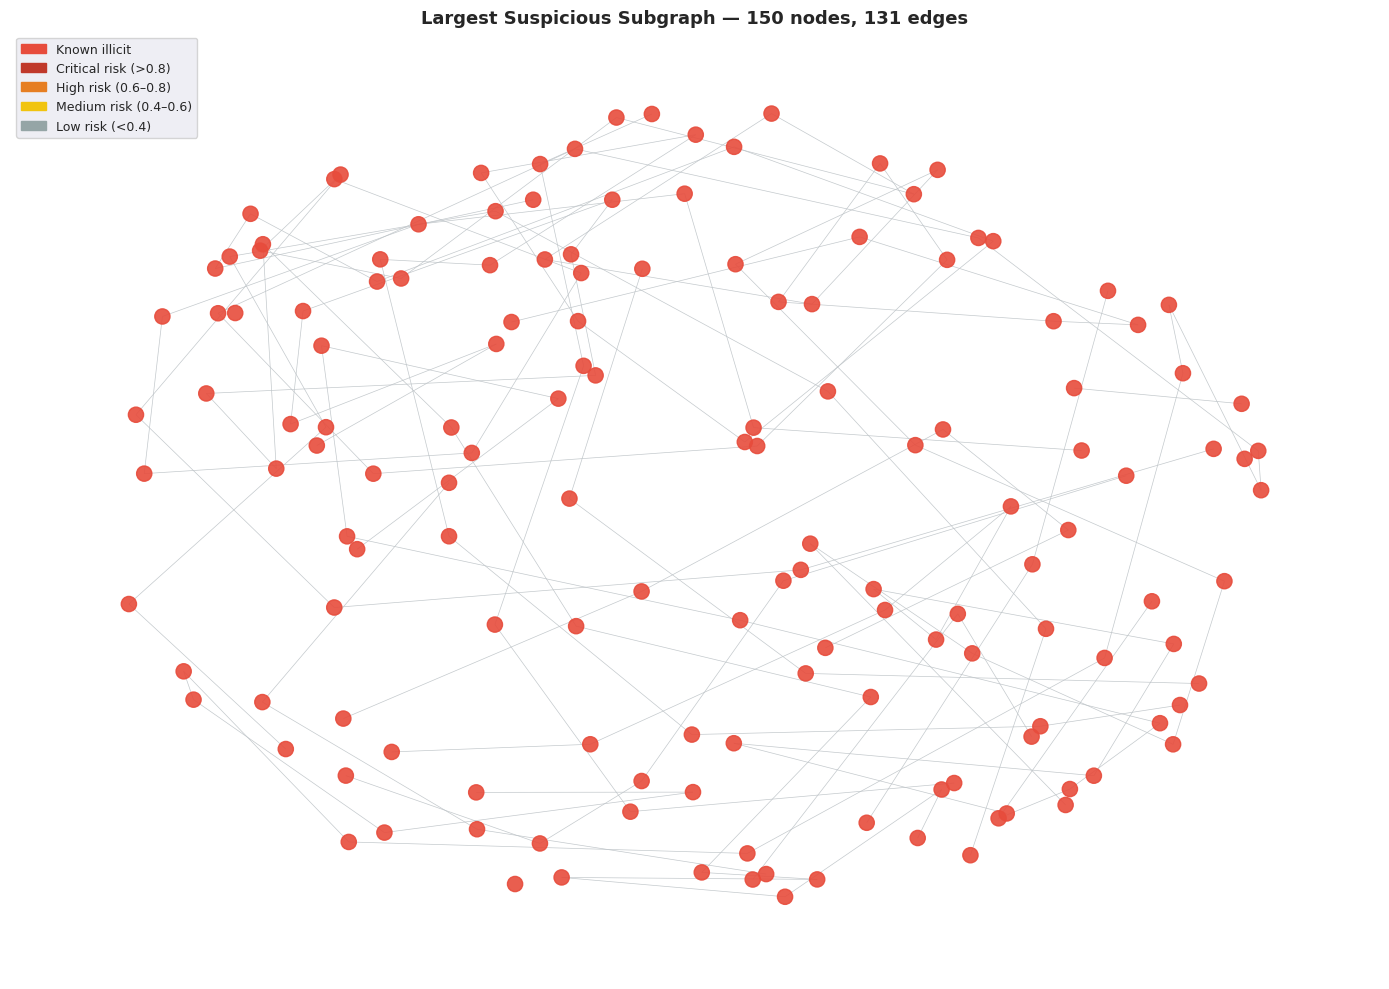

Ring composition:
  Known illicit  : 150
  Critical risk  : 0
  High risk      : 0


In [61]:
# ─────────────────────────────────────────────────────────────
# CELL 47 — Visualise Top Fraud Ring
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Take the largest ring — cap at 150 nodes for readability
top_ring_nodes = list(components_sorted[0])[:150]
ring_subgraph  = G.subgraph(top_ring_nodes).to_undirected()

# Node colors by type
def node_color(n):
    if n in known_illicit_txids:  return "#e74c3c"   # known illicit → red
    score = unknown_results.set_index("txId")["ensemble_score"].get(n, 0)
    if score >= 0.8:  return "#c0392b"   # critical → dark red
    if score >= 0.6:  return "#e67e22"   # high     → orange
    if score >= 0.4:  return "#f1c40f"   # medium   → yellow
    return "#95a5a6"                      # low      → gray

node_colors = [node_color(n) for n in ring_subgraph.nodes()]
node_sizes  = [
    120 if n in known_illicit_txids else 60
    for n in ring_subgraph.nodes()
]

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(ring_subgraph, seed=42, k=0.5)
nx.draw_networkx(
    ring_subgraph, pos,
    node_color=node_colors,
    node_size=node_sizes,
    with_labels=False,
    edge_color="#bdc3c7",
    width=0.5, alpha=0.9
)

legend_patches = [
    mpatches.Patch(color="#e74c3c", label="Known illicit"),
    mpatches.Patch(color="#c0392b", label="Critical risk (>0.8)"),
    mpatches.Patch(color="#e67e22", label="High risk (0.6–0.8)"),
    mpatches.Patch(color="#f1c40f", label="Medium risk (0.4–0.6)"),
    mpatches.Patch(color="#95a5a6", label="Low risk (<0.4)"),
]
plt.legend(handles=legend_patches, loc="upper left", fontsize=9)
plt.title(f"Largest Suspicious Subgraph — "
          f"{ring_subgraph.number_of_nodes()} nodes, "
          f"{ring_subgraph.number_of_edges()} edges",
          fontsize=13, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()

print(f"Ring composition:")
print(f"  Known illicit  : "
      f"{sum(1 for n in top_ring_nodes if n in known_illicit_txids)}")
print(f"  Critical risk  : "
      f"{sum(1 for n in top_ring_nodes if node_color(n) == '#c0392b')}")
print(f"  High risk      : "
      f"{sum(1 for n in top_ring_nodes if node_color(n) == '#e67e22')}")

In [62]:
# ─────────────────────────────────────────────────────────────
# CELL 48 — Save All Unknown Transaction Scores
# ─────────────────────────────────────────────────────────────

unknown_results.to_parquet(
    "/kaggle/working/unknown_risk_scores.parquet", index=False
)

# Save high-risk subset as CSV for easy inspection
high_risk = unknown_results[
    unknown_results["risk_tier"].isin(["CRITICAL", "HIGH"])
].copy()
high_risk.to_csv("/kaggle/working/high_risk_unknowns.csv", index=False)

print(f"Saved:")
print(f"  unknown_risk_scores.parquet  → all {len(unknown_results):,} unknown tx scores")
print(f"  high_risk_unknowns.csv       → {len(high_risk):,} critical/high risk transactions")

print(f"""
╔══════════════════════════════════════════════════════════════╗
║              PHASE 6 — UNKNOWN SCORING COMPLETE              ║
╠══════════════════════════════════════════════════════════════╣
║  Scored          : {len(unknown_results):>7,} unknown transactions          ║
║  Critical risk   : {(unknown_results['risk_tier']=='CRITICAL').sum():>7,} (ensemble > 0.80)         ║
║  High risk       : {(unknown_results['risk_tier']=='HIGH').sum():>7,} (ensemble > 0.60)         ║
║  Fraud rings     : {len(components_sorted):>7,} connected clusters           ║
╠══════════════════════════════════════════════════════════════╣
║  NEXT → Phase 7: Streamlit Dashboard                         ║
╚══════════════════════════════════════════════════════════════╝
""")

Saved:
  unknown_risk_scores.parquet  → all 157,205 unknown tx scores
  high_risk_unknowns.csv       → 13,903 critical/high risk transactions

╔══════════════════════════════════════════════════════════════╗
║              PHASE 6 — UNKNOWN SCORING COMPLETE              ║
╠══════════════════════════════════════════════════════════════╣
║  Scored          : 157,205 unknown transactions          ║
║  Critical risk   :   5,753 (ensemble > 0.80)         ║
║  High risk       :   8,150 (ensemble > 0.60)         ║
║  Fraud rings     :  12,974 connected clusters           ║
╠══════════════════════════════════════════════════════════════╣
║  NEXT → Phase 7: Streamlit Dashboard                         ║
╚══════════════════════════════════════════════════════════════╝



In [63]:
# ─────────────────────────────────────────────────────────────
# CELL 49 — Download all artifacts from Kaggle to run locally
# ─────────────────────────────────────────────────────────────
# Run this in Kaggle to zip everything needed for the dashboard

import os, zipfile

artifacts = [
    # ── Model files ───────────────────────────────
    "xgb_bitcoinguard_tuned.json",
    "lstm_bitcoinguard.keras",
    "graphsage_bitcoinguard.pt",
    "lgb_bitcoinguard.txt",
    "catboost_bitcoinguard.cbm",
    "gat_bitcoinguard.pt",

    # ── Preprocessing & ensemble ──────────────────
    "scaler.pkl",
    "meta_learner.pkl",
    "ensemble_proba.npy",
    "ensemble_pred.npy",

    # ── Metrics ───────────────────────────────────
    "bitcoinguard_final_metrics.json",
    "xgb_metrics.json",
    "lstm_metrics.json",
    "gnn_metrics.json",
    "lgb_metrics.json",
    "cat_metrics.json",
    "gat_metrics.json",

    # ── Interpretability (SHAP) ───────────────────
    "shap_values.npy",
    "shap_sample_X.npy",
    "shap_sample_y.npy",
    "shap_feature_ranking.parquet",

    # ── Risk & disagreement analysis ──────────────
    "unknown_risk_scores.parquet",
    "high_risk_unknowns.csv",
    "ensemble_with_disagreement.parquet",
]

with zipfile.ZipFile("/kaggle/working/bitcoinguard_dashboard.zip", "w") as zf:
    for fname in artifacts:
        fpath = f"/kaggle/working/{fname}"
        if os.path.exists(fpath):
            zf.write(fpath, fname)
            print(f"  added : {fname}")
        else:
            print(f"  MISSING: {fname}")

print("\nZip ready — download bitcoinguard_dashboard.zip from Kaggle output")

  added : xgb_bitcoinguard_tuned.json
  added : lstm_bitcoinguard.keras
  added : graphsage_bitcoinguard.pt
  added : lgb_bitcoinguard.txt
  added : catboost_bitcoinguard.cbm
  added : gat_bitcoinguard.pt
  added : scaler.pkl
  added : meta_learner.pkl
  added : ensemble_proba.npy
  added : ensemble_pred.npy
  added : bitcoinguard_final_metrics.json
  added : xgb_metrics.json
  added : lstm_metrics.json
  added : gnn_metrics.json
  added : lgb_metrics.json
  added : cat_metrics.json
  added : gat_metrics.json
  added : shap_values.npy
  added : shap_sample_X.npy
  added : shap_sample_y.npy
  added : shap_feature_ranking.parquet
  added : unknown_risk_scores.parquet
  added : high_risk_unknowns.csv
  added : ensemble_with_disagreement.parquet

Zip ready — download bitcoinguard_dashboard.zip from Kaggle output
